# Figure 3 — Dominant-negative variants

Self-contained notebook: all plotting functions are inlined (no `utils.py` dependency).
Each figure cell includes a configuration block for fonts, colors, and line widths.

In [1]:
from __future__ import annotations

import os
import re
import json
import subprocess
import warnings
import textwrap
import itertools
from collections import Counter, defaultdict
from io import BytesIO
from pathlib import Path
from typing import Iterable, Mapping, Sequence

import numpy as np
import pandas as pd

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.font_manager as fm
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import matplotlib.gridspec as gridspec
import matplotlib.lines as mlines
import matplotlib.transforms as mtransforms
import matplotlib.cm as mcm
from matplotlib.axes import Axes
from matplotlib.figure import Figure
from matplotlib.collections import LineCollection

from scipy import stats
from scipy import ndimage
from scipy.stats.contingency import odds_ratio as conditional_odds_ratio

# PyMOL environment (for structure rendering cells)
os.environ.setdefault("QT_API", "pyqt5")


'pyqt5'

In [2]:
# ===========================================================================
# Paths — adjust PROJECT_ROOT to point to your project directory
# ===========================================================================

PROJECT_ROOT = Path(".").resolve()  # ← set to your project root
DATA = PROJECT_ROOT / "data"
OUTPUT = PROJECT_ROOT / "Main4_DN_outputs"

ANNOTATED_COMBINED = "Supplementary_Table_2.tsv"
CONTROL_BARCODE_SCORES = "scoring" / "control_barcode_scores.tsv"
DN_THRESHOLDS = "scoring" / "dn_thresholds_recomputed.tsv"

POPULATION_HGVSP = "population_data_hgvsp.tsv"

PYMOL_BIN = Path("/vol1/home/jjsimon/.local/bin/pymol")
PYMOL_FETCH_CACHE = DATA / "structures" / "pymol_fetch_cache"

FIG = OUTPUT
FIG.mkdir(parents=True, exist_ok=True)


In [3]:
# ===========================================================================
# 03_constants.py
# Source: utils_2.py lines 258-505, 324-350, 3327-3333, plus notebook cell 3
# ===========================================================================

# ---------------------------------------------------------------------------
# Score columns  (utils_2.py lines 258-271)
# ---------------------------------------------------------------------------

#: WT-normalised score. WT == 1.0 **within each condition**, so differences on
#: this column are wild-type-relative (the *buffering* scale).
SCORE_WT_REL = "average score"
#: Standard-curve-corrected score. Retains the global WT shift between
#: conditions, so differences on this column are absolute (the *dependence*
#: scale). Compressed by the zero-intercept fit — fine for ranking within a
#: library, treat cross-protein absolute values with care.
SCORE_ABS = "intercept_0_standard-adjusted score"
#: Per-replicate companions of SCORE_ABS. New in the 080126 delivery; these are
#: what make a per-variant significance test on the absolute scale possible.
SCORE_ABS_REPS = [f"intercept_0_std_adj_score_{j}" for j in (1, 2, 3)]


# ---------------------------------------------------------------------------
# Protein sets and display names  (utils_2.py lines 274-354)
# ---------------------------------------------------------------------------

#: Figure-3 (dominant-negative) protein order: RAFs, RTKs, GTPases, GEFs,
#: phosphatase, then the scaffolds/adaptor. Shared by the DN panels so their
#: columns line up when stacked.
DN_ORDER = [
    "araf", "braf", "craf",
    "egfr", "erbb2", "met", "ret",
    "kras", "mras",
    "sos1", "sos2",
    "shp2",
    "grb2", "ksr1", "ksr2",
]

#: Figure-4 (HSP90) protein order: the nine kinase-domain-bearing proteins
#: profiled under HSP90 inhibition, grouped by how much their WILD TYPE depends
#: on HSP90 — high (CRAF, ARAF, RET), moderate (KSR2, EGFR, HGFR), low (BRAF,
#: MEK2, MEK1). This is the order the violin panels use, so every figure-4 panel
#: that resolves by protein reads in the same sequence.
HSP90_ORDER = [
    "craf", "araf", "ret",
    "ksr2", "egfr", "met",
    "braf", "mek2", "mek1",
]

#: Every protein key either order knows about — for "is this string a protein?"
#: checks, where ordering is irrelevant.
PROTEIN_KEYS = DN_ORDER + [p for p in HSP90_ORDER if p not in DN_ORDER]

#: The 12 proteins whose wild-type overexpression raises pathway activity, so a
#: variant scoring below the empty-vector baseline is interpretable as dominant
#: negative. Excludes the inhibitory set below.
DN_ELIGIBLE = [
    "araf", "braf", "craf", "egfr", "erbb2", "kras",
    "met", "mras", "ret", "shp2", "sos1", "sos2",
]

#: Overexpressing these *lowers* pathway activity, so "below empty vector" is
#: the expected wild-type phenotype, not dominant negativity. Matches
#: ``config/scoring.yaml: inhibitory_proteins``.
INHIBITORY_PROTEINS = {"grb2", "ksr1", "ksr2", "mek1", "mek2"}

#: The 9 kinases with paired control/HSP90i abundance data.
#: Every protein profiled under HSP90 inhibition — ten, including SOS2.
HSP90I_PROTEINS = ["araf", "braf", "craf", "egfr", "ksr2", "mek1", "mek2",
                   "met", "ret", "sos2"]

#: Unperturbed activity conditions. DN is defined only here: SerumStarve
#: collapses EGFR-WT onto the empty-vector baseline, and CIAR drives the pathway
#: independently of variant identity, so neither reports variant function
#: against a meaningful no-kinase floor.
BASELINE_TREATMENTS = {"No_treatment", "DMSO"}

#: Variant types that change the protein product. DN is restricted to these:
#: synonymous and the BRAF spike-in standards cannot be dominant negative.
PROTEIN_ALTERING_TYPES = {"missense", "nonsense", "deletion"}

#: MET's gene symbol is MET but the receptor is conventionally HGFR in this
#: manuscript. Only this one protein differs from an uppercase key.
_DISPLAY_OVERRIDES = {"met": "HGFR", "shp2": "SHP2", "kras": "KRAS", "mras": "MRAS"}


# ---------------------------------------------------------------------------
# Palettes  (utils_2.py lines 383-505)
# ---------------------------------------------------------------------------

#: Locked across every HSP90 figure (docs/hsp90_metric_definitions.md).
BUFFERING_COLORS = {
    "Buffered": "#bd2c2c",
    "Poorly buffered": "#d9892d",
    "WT-like or high": "#3a6fb5",
}
BUFFERING_ORDER = ["Buffered", "Poorly buffered", "WT-like or high"]

#: White -> class-colour ramps for the structure renders, so a painted fold
#: reads in the same colour as the class does in every 2D panel.
#: Bottom-to-top stack order for the buffering proportion bars (4C, 4G):
#: the WT-like majority sits at the base so the two buffered classes stack
#: against a common baseline and can be compared across bars by eye.
BUFFERING_STACK_ORDER = ["WT-like or high", "Buffered", "Poorly buffered"]

BUFFERING_CMAPS = {"Buffered": "Reds", "Poorly buffered": "Oranges",
                   "WT-like or high": "Blues"}

#: Activity-class palette, kept stable across figures.
ACTIVITY_COLORS = {
    "DN": "#C0392B",
    "low": "#26A69A",
    "wt-like": "#F4E04D",
    "high": "#E64A19",
}
ACTIVITY_ORDER = ["DN", "low", "wt-like", "high"]

#: Title-cased activity groups as used by the by-activity-group panels
#: (``scripts/analyze_structure_by_activity_group.py`` and the phyloP / RSA /
#: kinase-conservation companions). Same colours, ordered GOF -> most severe.
ACTIVITY_GROUP_ORDER = ["High", "WT-like", "Low", "DN"]
ACTIVITY_GROUP_COLOR = {
    "High": "#E64A19", "WT-like": "#F4E04D", "Low": "#26A69A", "DN": "#C0392B",
}
#: Minimum variants in a (protein, group) cell for it to contribute a
#: per-protein median dot — the Simpson guard.
MIN_N_PER_PROTEIN = 10

#: Population / cancer databases.
DB_COLORS = {"gnomAD": "#3571b6", "AoU": "#b67a35", "GENIE": "#4f8f4f"}

#: Per-protein sphere colours for the structural renders, carried over from
#: ``scripts/paint_dn_counts_pdb_structures.py`` so a protein keeps one colour
#: across every structure it appears in.
PROTEIN_SPHERE_COLOR = {
    "araf":  (0.85, 0.65, 0.10),   # mustard
    "braf":  (0.10, 0.28, 0.65),   # deep blue
    "craf":  (0.25, 0.55, 0.85),   # cornflower
    "egfr":  (0.70, 0.10, 0.15),   # ruby
    "erbb2": (0.65, 0.08, 0.12),   # maroon
    "kras":  (0.90, 0.45, 0.05),   # dark orange
    "met":   (0.55, 0.35, 0.10),   # bronze
    "mras":  (0.85, 0.50, 0.10),   # amber
    "ret":   (0.45, 0.05, 0.45),   # dark magenta
    "shp2":  (0.15, 0.60, 0.30),   # forest green
    "sos1":  (0.50, 0.05, 0.65),   # purple
    "sos2":  (0.05, 0.55, 0.45),   # teal
}
#: Cartoon and partner colours for the structural renders.
STRUCT_CARTOON_COLOR = "gray80"
STRUCT_PARTNER_COLORS = ("skyblue", "wheat", "lightpink")

#: Per-variant-type colours, carried over from
#: ``scripts/plot_dn_structural_enrichment_forest*.py`` so the DN forests match.
VARIANT_TYPE_COLORS = {
    "missense": "#6ABBA8",   # 
    "deletion": "#9B7DB8",   # 
    "nonsense": "#D65F4E",   # 
}
VARIANT_TYPE_ORDER = ["missense", "deletion", "nonsense"]

#: The same palette keyed by the `variant_category` vocabulary the scoring
#: pipeline emits, which names the single-codon class "3nt deletion" and keeps an
#: explicit "other" bucket (multi-mutants and larger in-frame deletions).
#: Synonymous, WT and the spiked standards are deliberately absent: they are
#: controls rather than library variants, so the panels using this palette plot
#: only the protein-altering classes.
VARIANT_CATEGORY_COLORS = {
    "missense": "#6ABBA8",       # 
    "3nt deletion": "#9B7DB8",   # 
    "nonsense": "#D65F4E",       # 
    "frameshift": "#b2182b",     # 
    "other": "#8c8c8c",          # 
}
VARIANT_CATEGORY_ORDER = ["missense", "3nt deletion", "nonsense", "frameshift",
                          "other"]

#: DN structural-ontology (v4) bucket styling, carried over from
#: ``scripts/plot_dn_ontology_v4_coverage.py``. Each entry is
#: ``(facecolor, hatch_colour, hatch_pattern)``; the two-category combos are
#: drawn as the first category's fill hatched in the second's colour.
ONTOLOGY_COLOR_B = "#d97b1f"      # orange
ONTOLOGY_COLOR_AS = "#a64ca6"     # purple
ONTOLOGY_COLOR_I = "#3a6fb5"      # blue
ONTOLOGY_COLOR_NONE = "#ffffff"   # white -- unexplained
ONTOLOGY_NONE_EDGE = "#999999"

ONTOLOGY_BUCKET_ORDER = ["B_only", "AS_only", "I_only", "B_I", "AS_I", "none"]
ONTOLOGY_BUCKET_STYLE: dict[str, tuple] = {
    "B_only":  (ONTOLOGY_COLOR_B, None, None),
    "AS_only": (ONTOLOGY_COLOR_AS, None, None),
    "I_only":  (ONTOLOGY_COLOR_I, None, None),
    "B_I":     (ONTOLOGY_COLOR_B, ONTOLOGY_COLOR_I, "////"),
    "AS_I":    (ONTOLOGY_COLOR_AS, ONTOLOGY_COLOR_I, "////"),
    "none":    (ONTOLOGY_COLOR_NONE, None, None),
}
ONTOLOGY_BUCKET_LABELS = {
    "B_only": "Buried, non-active site (B)", "AS_only": "Active site (AS)",
    "I_only": "Interface (I)", "B_I": "B + I", "AS_I": "AS + I",
    "none": "Other",
}
#: Legend layout: single categories + Other on the top row, combos beneath.
ONTOLOGY_LEGEND_ROWS = [["B_only", "AS_only", "I_only", "none"],
                        ["B_I", "AS_I"]]


# ---------------------------------------------------------------------------
# Depletion constants  (utils_2.py lines 3327-3333)
# ---------------------------------------------------------------------------

#: Database styling for the pooled depletion forest, carried over from
#: ``scripts/plot_class_depletion_global.py``. Germline vs cancer is stated in
#: the label because the two are different kinds of evidence.
DEPLETION_DB_STYLE = {
    "gnomAD": {"color": "#1F3F73", "marker": "o", "label": "gnomAD (germline)"},
    "AoU":    {"color": "#E08328", "marker": "s", "label": "AoU (germline)"},
    "GENIE":  {"color": "#51b949", "marker": "D", "label": "GENIE (cancer)"},
}
#: Vertical offset within a class slot; first listed sits on top.
DEPLETION_DB_OFFSET = {"gnomAD": +0.22, "AoU": 0.0, "GENIE": -0.22}


# ---------------------------------------------------------------------------
# COLS list from notebook cell 3 — columns to load from ANNOTATED_COMBINED
# ---------------------------------------------------------------------------

COLS = ["protein", "library", "assay", "assay_treatment", "variant",
        "Mutation Type", "variant_category", "Wild Type Residue", "Mutation",
        "Position",
        "average score", "classification_2.5pct", "DN_EV", "dn_threshold",
        "domain", "relative_sasa", "dssp_secondary_structure", "active_site",
        "interface_pdb_curated", "interface_partners", "n_interface_partners",
        "inter_domain_contacts_all_atom", "phylop_vert", "jsd_conservation",
        "ddG_SPURS", "in_gnomad", "in_aou",
        "genie_count",
        "min_nt_changes", "gnomad_mappable", "nmd_zone"]


In [4]:
# ===========================================================================
# Shared helper functions
# ===========================================================================


# ---------------------------------------------------------------------------
# protein_label / protein_labels  (display names for protein keys)
# ---------------------------------------------------------------------------

def protein_label(protein: str) -> str:
    """Display name for a protein key. MET renders as HGFR."""
    key = str(protein).strip().lower()
    suffix = ""
    if key.endswith("_cterm"):
        key, suffix = key[:-6], " (C)"
    elif key.endswith("_nterm"):
        key, suffix = key[:-6], " (N)"
    elif key.endswith("_ss"):
        key, suffix = key[:-3], " (serum-starved)"
    elif key.endswith("_ciar"):
        key, suffix = key[:-5], " (CIAR)"
    return _DISPLAY_OVERRIDES.get(key, key.upper()) + suffix


def protein_labels(proteins) -> list[str]:
    """Vectorised protein_label, for axis tick labels."""
    return [protein_label(p) for p in proteins]


# ---------------------------------------------------------------------------
# apply_style  (Arial only, transparent backgrounds)
# ---------------------------------------------------------------------------

def apply_style(*, base_fontsize: float = 8.0) -> None:
    """Set publication rcParams. Uses Arial. Transparent backgrounds."""
    plt.rcParams.update({
        "font.family": "sans-serif",
        "font.sans-serif": ["Arial", "DejaVu Sans"],
        "pdf.fonttype": 42,
        "svg.fonttype": "none",
        "font.size": base_fontsize,
        "axes.labelsize": base_fontsize,
        "axes.titlesize": base_fontsize + 1,
        "xtick.labelsize": base_fontsize - 1,
        "ytick.labelsize": base_fontsize - 1,
        "legend.fontsize": base_fontsize - 1,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.linewidth": 0.6,
        "xtick.major.width": 0.6,
        "ytick.major.width": 0.6,
        "figure.dpi": 110,
        "savefig.dpi": 300,
        # --- Transparent backgrounds ---
        "savefig.facecolor": "none",
        "savefig.transparent": True,
        "figure.facecolor": "none",
        "axes.facecolor": "none",
    })


# ---------------------------------------------------------------------------
# save_figure
# ---------------------------------------------------------------------------

def save_figure(fig, stem, *, formats=("pdf", "svg", "png"), tight=True):
    """Save a figure to several formats beside one another."""
    stem = Path(stem)
    stem.parent.mkdir(parents=True, exist_ok=True)
    kw = {"bbox_inches": "tight"} if tight else {}
    written = []
    for ext in formats:
        p = stem.with_suffix(f".{ext}")
        fig.savefig(p, **kw)
        if ext == "svg":
            fix_svg_pattern_order(p)
        written.append(p)
    return written


# ---------------------------------------------------------------------------
# fix_svg_pattern_order
# ---------------------------------------------------------------------------

def fix_svg_pattern_order(svg_path):
    """Move <pattern> defs to top of SVG for Illustrator compatibility."""
    svg_path = Path(svg_path)
    content = svg_path.read_text()
    defs_blocks = re.findall(r'<defs>.*?</defs>', content, re.S)
    pattern_blocks = [b for b in defs_blocks if '<pattern' in b]
    if not pattern_blocks:
        return
    for block in pattern_blocks:
        content = content.replace(block, '', 1)
    insert_at = re.search(r'<svg[^>]*>', content).end()
    content = content[:insert_at] + '\n' + '\n'.join(pattern_blocks) + content[insert_at:]
    svg_path.write_text(content)


# ---------------------------------------------------------------------------
# stars_4tier / stars_4tier_ns
# ---------------------------------------------------------------------------

def stars_4tier(p: float) -> str:
    """**** <1e-4, *** <1e-3, ** <1e-2, * <0.05, else ns."""
    if p is None or not np.isfinite(p):
        return ""
    return ("****" if p < 1e-4 else "***" if p < 1e-3 else
            "**" if p < 1e-2 else "*" if p < 0.05 else "ns")


def stars_4tier_ns(p: float) -> str:
    """As stars_4tier but n.s. for non-significant and non-finite."""
    if p is None or not np.isfinite(p):
        return "n.s."
    return ("****" if p < 1e-4 else "***" if p < 1e-3 else
            "**" if p < 1e-2 else "*" if p < 0.05 else "n.s.")


# ---------------------------------------------------------------------------
# fixed_pitch_bar_axes
# ---------------------------------------------------------------------------

def fixed_pitch_bar_axes(
    n_bars: int,
    *,
    pitch_in: float = 0.95,
    axes_h_in: float = 3.40,
    left_in: float = 0.95,
    right_in: float = 0.30,
    bottom_in: float = 1.15,
    top_in: float = 0.50,
    legend_in: float = 0.0,
):
    """Figure + axes whose data area is a fixed physical width per category."""
    data_w = n_bars * pitch_in
    fig_w = left_in + data_w + right_in + legend_in
    fig_h = bottom_in + axes_h_in + top_in
    fig = plt.figure(figsize=(fig_w, fig_h))
    ax = fig.add_axes([left_in / fig_w, bottom_in / fig_h,
                       data_w / fig_w, axes_h_in / fig_h])
    ax.set_xlim(-0.5, n_bars - 0.5)
    return fig, ax


# ---------------------------------------------------------------------------
# _draw_diagonal_hatch
# ---------------------------------------------------------------------------

def _draw_diagonal_hatch(ax, x0, y0, w, h, *, color, lw=0.5, spacing_pt=2.2,
                          zorder=3):
    """Explicit 45-degree hatch lines, exactly clipped to (x0, y0, w, h)."""
    fig = ax.figure
    fig.canvas.draw()
    trans = ax.transData
    inv = trans.inverted()
    corners = trans.transform([(x0, y0), (x0 + w, y0 + h)])
    left, bottom = corners.min(axis=0)
    right, top = corners.max(axis=0)
    spacing = spacing_pt * fig.dpi / 72.0
    c_lo = int(np.floor((bottom - right) / spacing)) - 1
    c_hi = int(np.ceil((top - left) / spacing)) + 1
    segs = []
    for i in range(c_lo, c_hi + 1):
        c = i * spacing
        x_lo, x_hi = max(left, bottom - c), min(right, top - c)
        if x_hi <= x_lo:
            continue
        segs.append([inv.transform((x_lo, x_lo + c)),
                     inv.transform((x_hi, x_hi + c))])
    if segs:
        ax.add_collection(LineCollection(
            segs, colors=color, linewidths=lw, zorder=zorder,
            antialiaseds=True, capstyle="butt"), autolim=False)


# ===========================================================================
# Analysis helpers (from notebook cell 5)
# ===========================================================================

def fisher_or(n_in_a, n_out_a, n_in_b, n_out_b):
    '''Conditional-MLE odds ratio, exact 95% CI, two-sided Fisher p.'''
    table = np.array([[n_in_a, n_out_a], [n_in_b, n_out_b]])
    out = dict(n_in_a=n_in_a, n_out_a=n_out_a, n_in_b=n_in_b, n_out_b=n_out_b,
               or_=np.nan, ci_low=np.nan, ci_high=np.nan, p=np.nan)
    if table.sum() == 0 or (table.sum(axis=1) == 0).any():
        return out
    try:
        res = conditional_odds_ratio(table)
        ci = res.confidence_interval(0.95)
        out["or_"], out["ci_low"], out["ci_high"] = res.statistic, ci.low, ci.high
    except Exception:
        pass
    out["p"] = stats.fisher_exact(table)[1]
    return out


def bh(pvals):
    '''BH q-values via scipy, NaN-safe.'''
    p = np.asarray(pvals, dtype=float)
    q = np.full_like(p, np.nan)
    ok = np.isfinite(p)
    if ok.any():
        q[ok] = stats.false_discovery_control(p[ok], method="bh")
    return q


def stars(q):
    '''*** q<0.001, ** q<0.01, * q<0.05.'''
    if q is None or not np.isfinite(q):
        return ""
    return "***" if q < 1e-3 else "**" if q < 1e-2 else "*" if q < 0.05 else ""


def enrichment(df, feature_cols, group_col, group_by=None):
    '''DN-vs-non-DN odds ratio for each boolean feature, BH-corrected.'''
    rows = []
    strata = [(None, df)] if group_by is None else list(df.groupby(group_by))
    for stratum, sub in strata:
        arm = sub[group_col].astype(bool)
        for feat in feature_cols:
            fl = sub[feat].astype(bool)
            r = fisher_or(int((arm & fl).sum()), int((arm & ~fl).sum()),
                          int((~arm & fl).sum()), int((~arm & ~fl).sum()))
            r.update({group_by or "stratum": stratum, "feature": feat})
            rows.append(r)
    out = pd.DataFrame(rows).rename(columns={"or_": "or"})
    out["q"] = bh(out["p"].values)
    out["stars"] = out["q"].map(stars)
    return out


def load_scored(**filters):
    '''Read the combined table with the usual filters.
    Uses ANNOTATED_COMBINED and COLS defined in the constants cell.'''
    df = pd.read_csv(ANNOTATED_COMBINED, sep="\t", low_memory=False,
                     usecols=list(dict.fromkeys(COLS)))
    for col, allowed in filters.items():
        if allowed is None:
            continue
        df = df[df[col].isin(set(allowed)) if isinstance(allowed, (set, list, tuple))
                else (df[col] == allowed)]
    return df.reset_index(drop=True)


def activity_group(df):
    '''Four-level activity group, DN taking precedence over low.'''
    g = df["classification_2.5pct"].astype(object).copy()
    g[df["DN_EV"] == True] = "DN"   # noqa: E712 — DN_EV is object dtype
    return g


In [5]:
# ===========================================================================
# Apply publication style — Arial font, transparent backgrounds
# ===========================================================================

apply_style()


In [6]:
# ===========================================================================
# Load Replicate_scores — central dataframe for all figures
# ===========================================================================

Replicate_scores = load_scored(assay="activity", assay_treatment=BASELINE_TREATMENTS)
print(f"Replicate_scores rows (activity baseline): {len(Replicate_scores):,}")

# --- Add derived columns ---
Replicate_scores["is_dn"] = Replicate_scores["DN_EV"] == True
Replicate_scores["activity_group"] = activity_group(Replicate_scores)

_rsa = pd.to_numeric(Replicate_scores.relative_sasa, errors="coerce")
Replicate_scores["in_domain"] = Replicate_scores.domain.notna() & Replicate_scores.domain.ne("none")
Replicate_scores["is_buried"] = _rsa.lt(0.25)
Replicate_scores["is_active_site"] = Replicate_scores.active_site.astype(bool)
Replicate_scores["is_interface"] = Replicate_scores.interface_pdb_curated.astype(bool)
Replicate_scores["is_exposed_other"] = (_rsa.ge(0.25)
                                        & ~Replicate_scores.is_active_site
                                        & ~Replicate_scores.is_interface)

# DN-eligible subset
dn_pool = Replicate_scores[Replicate_scores.protein.isin(DN_ELIGIBLE)].copy()
print(f"DN-eligible rows: {len(dn_pool):,}   DN: {int(dn_pool.is_dn.sum()):,}")


Replicate_scores rows (activity baseline): 196,801
DN-eligible rows: 134,670   DN: 13,791


## Empty-vector bootstrap validation

In [7]:
ev_boot_table = pd.read_csv(DN_THRESHOLDS, sep="\t")
ev_boot_table = ev_boot_table[(ev_boot_table.assay == "activity")
                              & (ev_boot_table.control == "used")]
print(f"thresholds read from {DN_THRESHOLDS.name}: "
      f"{len(ev_boot_table)} activity cells")

ctrl = pd.read_csv(CONTROL_BARCODE_SCORES, sep="\t")
print(f"control barcodes behind them: {len(ctrl):,}")
print(ctrl.groupby("variant").size().rename("barcodes").to_frame().to_string())

_show = (ev_boot_table[ev_boot_table.assay_treatment.isin(
    BASELINE_TREATMENTS)].sort_values("library"))
print("\nthe no-variant null per baseline cell "
      "(2.5th pct of 500 draws of a 10-barcode mean):")
print(_show[["library", "assay_treatment", "n_barcodes", "pooled_novar",
             "dn_threshold", "boot_p2.5", "boot_median", "boot_p97.5",
             "seed_lo", "seed_hi"]]
      .to_string(index=False, float_format=lambda v: f"{v:8.4f}"))

# The classification must agree with the thresholds these panels draw.
_t = Replicate_scores.dropna(subset=["dn_threshold"]).groupby(
    ["library", "assay_treatment"])["dn_threshold"].first()
_j = ev_boot_table.set_index(["library", "assay_treatment"]).dn_threshold
_cmp = pd.concat([_t.rename("in_annotated"), _j.rename("in_thresholds")],
                 axis=1).dropna()
_dev = (_cmp.in_annotated / _cmp.in_thresholds - 1).abs()
print(f"\nthresholds in annotated_combined vs the file: {len(_cmp)} cells, "
      f"max deviation {_dev.max():.4%}")
assert _dev.max() < 1e-6, (
    "annotated_combined was built from different thresholds than these panels "
    "draw — re-run Annotations.ipynb:\n" + _cmp[_dev > 1e-6].to_string())

# --- specificity: how often does the threshold call a SYNONYMOUS variant? ---
# Synonymous variants are excluded from DN_EV by the protein-altering filter, so
# they are never *called* — which is exactly why they make a free negative
# control. A threshold that separates function from noise should leave them
# alone. Where it does not, the DN calls in that cell are not measuring
# dominant negativity.
_a = Replicate_scores[~Replicate_scores.protein.isin(INHIBITORY_PROTEINS)]
spec = []
for (lib, tr), g in _a.groupby(["library", "assay_treatment"]):
    row = ev_boot_table[(ev_boot_table.library == lib)
                        & (ev_boot_table.assay_treatment == tr)]
    if not len(row):
        continue
    thr = float(row.dn_threshold.iloc[0])
    syn = g.loc[g["Mutation Type"] == "synonymous wild type", "average score"].dropna()
    mis = g.loc[g["Mutation Type"] == "missense", "average score"].dropna()
    if not len(syn) or not len(mis):
        continue
    spec.append({"library": lib, "n_syn": len(syn),
                 "syn_below_pct": 100 * (syn < thr).mean(),
                 "mis_below_pct": 100 * (mis < thr).mean(),
                 "ctrl_over_syn": float(row.boot_median.iloc[0]) / syn.median(),
                 "enrichment": ((mis < thr).mean() / (syn < thr).mean()
                                if (syn < thr).any() else np.inf)})
spec = pd.DataFrame(spec).sort_values("syn_below_pct", ascending=False)
print("\nDN threshold specificity — synonymous are the free negative control:")
print(spec.to_string(index=False, float_format=lambda v: f"{v:8.2f}"))

_bad = spec[spec.syn_below_pct > 5]
if len(_bad):
    print(f"\n  WARNING: {len(_bad)} cell(s) call >5% of synonymous variants:")
    for r in _bad.itertuples():
        print(f"    {r.library}: {r.syn_below_pct:.1f}% of synonymous below the "
              f"threshold, missense only {r.enrichment:.1f}x enriched over them. "
              f"The no-variant control sits at {r.ctrl_over_syn:.2f}x the "
              "synonymous median"
              + (" — ABOVE wild-type-like, so 'below the control' cannot mean "
                 "dominant negative here." if r.ctrl_over_syn > 1 else "."))
    print("  DN counts from these cells should not be used as they stand.")



thresholds read from dn_thresholds_recomputed.tsv: 24 activity cells
control barcodes behind them: 84,345
                  barcodes
variant                   
NoVar_std             8074
empty_vector_std     76271

the no-variant null per baseline cell (2.5th pct of 500 draws of a 10-barcode mean):
   library assay_treatment  n_barcodes  pooled_novar  dn_threshold  boot_p2.5  boot_median  boot_p97.5  seed_lo  seed_hi
araf_cterm    No_treatment        6058          True        0.6163     0.6157       0.7133      0.8541   0.6037   0.6263
araf_nterm    No_treatment        1171          True        0.5220     0.5182       0.6027      0.7130   0.5129   0.5323
braf_cterm    No_treatment         365         False        0.9153     0.9379       1.0715      1.2441   0.8960   0.9314
braf_nterm    No_treatment         861         False        0.7300     0.7285       0.8573      0.9911   0.7147   0.7458
craf_cterm    No_treatment        5629          True        0.2573     0.2581       0.3024     

## Figure 3A — Activity histogram

KRAS: missense 3,527, 3nt deletion 239, nonsense 187, synonymous 180
excluded from the panel: frameshift 188, other 9


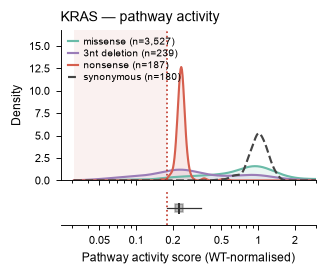

,n,n_dn,% of class that is DN,% of DN pool,in panel
variant_category,,,,,
missense,3527,214,6.1,77.0,True
3nt deletion,239,62,25.9,22.3,True
nonsense,187,1,0.5,0.4,True
frameshift,188,0,0.0,0.0,False
other,9,1,11.1,0.4,False


In [11]:
# ======================================================================
# Figure 3A — Activity histogram — Configuration
# ======================================================================

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']
plt.rcParams['figure.facecolor'] = 'none'
plt.rcParams['axes.facecolor'] = 'none'
plt.rcParams['savefig.facecolor'] = 'none'

# Font sizes
FONT_SIZE_TITLE = 10
FONT_SIZE_LABEL = 9
FONT_SIZE_TICK = 8
FONT_SIZE_LEGEND = 8

# Line widths
LINE_WIDTH_AXES = 0.6
LINE_WIDTH_PLOT = 1.0


def plot_activity_histogram(
    scores: Sequence[float],
    *,
    dn_threshold: float,
    box_distributions: Sequence[tuple[str, Mapping[str, float], str]] = (),
    groups: Sequence[tuple[str, Sequence[float], str]] = (),
    density_groups: Sequence[tuple[str, Sequence[float], str]] = (),
    smooth: bool = False,
    smooth_bw: float | str | None = None,
    dn_color: str = "#C0392B",
    bar_color: str = "#222222",
    title: str = "",
    xlabel: str = "Pathway activity score (WT-normalised)",
    bins: int = 60,
    log_x: bool = True,
    figsize: tuple[float, float] = (3.6, 2.9),
    note: str = "",
    fs: Mapping[str, float] | None = None,
    show_threshold_label: bool = True,
    show_class_breakdown: bool = True,
    xlim: tuple[float | None, float | None] | None = None,
) -> tuple[Figure, np.ndarray]:
    """Activity histogram with the DN threshold and control boxplots beneath.

    New panel (no prior version). Variants below ``dn_threshold`` are drawn in
    the DN colour, the rest dark; a dotted line marks the threshold. Bin edges
    are split exactly at the threshold so the coloured block ends there rather
    than at the nearest bin boundary.

    ``box_distributions`` is a sequence of ``(label, five_number, colour)``
    drawn top-to-bottom in the lower strip on the shared x-axis. The
    five-number mapping uses keys ``p2.5``, ``p25``, ``median``, ``p75``,
    ``p97.5``; missing quartiles collapse the box to a line rather than
    failing, so a distribution known only by its outer percentiles still
    renders.

    ``groups`` switches the bars from DN-vs-not colouring to a **stacked**
    histogram of variant classes, given as ``(label, values, colour)``. The
    threshold line and its annotation stay, and the region below the threshold
    is shaded, so which variants are DN is still readable — but the panel now
    also answers *what kind* of variant sits where on the activity axis, which
    the two-colour version could not. ``scores`` should be the concatenation of
    the group values; it is what the smoothed curve and the counts describe.

    ``density_groups`` takes the same ``(label, values, colour)`` shape but
    replaces the bars with one **area-normalised** smoothed density per class.
    Use it to compare where classes sit on the activity axis: stacked counts are
    dominated by whichever class is most numerous, so a class an order of
    magnitude rarer is invisible. The trade is that the curves no longer carry
    abundance, so class sizes are put in the legend and the per-class fraction
    below the threshold is annotated instead.

    ``smooth`` overlays a Gaussian KDE scaled to counts. It is fitted in the
    axis's own space — log10 when ``log_x``, linear otherwise — so the curve is
    not distorted by the transform. Scaling uses a *uniform* bin width in that
    space rather than the actual (threshold-split, possibly uneven) edges, so
    the curve's area matches the histogram's regardless of where the split
    lands.

    Args:
        scores: Values to histogram.
        dn_threshold: Empty-vector cutoff on the same scale.
        box_distributions: Control distributions for the lower strip.
        groups: ``(label, values, colour)`` per variant class, stacked.
        smooth: Overlay a count-scaled KDE.
        smooth_bw: Bandwidth passed to ``gaussian_kde`` (default: Scott's rule).
        note: Small grey caption, e.g. to record a missing input.
        fs: Font-size overrides; keys ``axis``, ``tick``, ``ann``, ``title``.
        show_threshold_label: Draw the "DN threshold ... below" annotation.
        show_class_breakdown: Draw the per-class "% below threshold" block.
        xlim: Optional ``(left, right)`` passed to ``ax.set_xlim``; either
            side may be ``None`` to leave that bound on its default.
    """
    F = {"axis": 8, "tick": 7, "ann": 6.5, "title": 9}
    F.update(fs or {})
    scores = np.asarray([s for s in scores if np.isfinite(s)], dtype=float)
    n_box = max(len(box_distributions), 1)

    fig, axes = plt.subplots(
        2, 1, figsize=figsize, sharex=True,
        gridspec_kw={"height_ratios": [3.2, 0.42 + 0.30 * n_box],
                     "hspace": 0.12})
    ax, axb = axes

    if log_x:
        lo = max(np.nanmin(scores), 1e-3)
        edges = np.logspace(np.log10(lo), np.log10(np.nanmax(scores)), bins + 1)
    else:
        edges = np.linspace(np.nanmin(scores), np.nanmax(scores), bins + 1)
    edges = np.unique(np.sort(np.append(edges, dn_threshold)))
    centres = 0.5 * (edges[:-1] + edges[1:])

    if density_groups:
        # One smoothed density per variant class, each normalised to unit area,
        # rather than stacked counts. Stacking answers "how many", which the
        # class sizes already say (they are in the legend); overlaid densities
        # answer "where does each class sit", which is the actual question — and
        # a class 13x rarer than missense is invisible on a count axis.
        from scipy.stats import gaussian_kde
        ax.axvspan(edges[0], dn_threshold, color=dn_color, alpha=0.07, lw=0,
                   zorder=0)
        for entry in density_groups:
            # a 4th element is an optional linestyle, used to mark a control
            # (e.g. synonymous) as not one of the library variant classes
            label, vals, colour = entry[:3]
            ls = entry[3] if len(entry) > 3 else "-"
            v = np.asarray([x for x in vals if np.isfinite(x)], dtype=float)
            if log_x:
                v = v[v > 0]
            t = np.log10(v) if log_x else v
            if t.size < 5 or np.ptp(t) == 0:
                continue
            grid = np.linspace(np.log10(edges[0]) if log_x else edges[0],
                               np.log10(edges[-1]) if log_x else edges[-1], 400)
            y = gaussian_kde(t, bw_method=smooth_bw)(grid)
            x = 10 ** grid if log_x else grid
            ax.plot(x, y, color=colour, lw=1.4, ls=ls, zorder=3,
                    label=f"{label} (n={len(v):,})")
            if ls == "-":
                ax.fill_between(x, y, color=colour, alpha=0.13, lw=0, zorder=1)
        counts = np.zeros(len(edges) - 1)
        ax.set_ylim(bottom=0)
        ax.legend(loc="upper left", fontsize=F["ann"], frameon=False,
                  handlelength=1.1, handletextpad=0.5, borderaxespad=0.3,
                  labelspacing=0.25)
    elif groups:
        # Stacked by variant class. The below-threshold region is shaded instead
        # of recoloured, so the DN split stays legible without spending the
        # colour channel that now carries variant class.
        ax.axvspan(edges[0], dn_threshold, color=dn_color, alpha=0.07, lw=0,
                   zorder=0)
        bottom = np.zeros(len(edges) - 1)
        for label, vals, colour in groups:
            v = np.asarray([x for x in vals if np.isfinite(x)], dtype=float)
            c, _ = np.histogram(v, bins=edges)
            ax.bar(edges[:-1], c, width=np.diff(edges), align="edge",
                   bottom=bottom, color=colour, linewidth=0, zorder=2,
                   label=f"{label} (n={len(v):,})")
            bottom += c
        counts = bottom
        ax.legend(loc="upper left", fontsize=F["ann"], frameon=False,
                  handlelength=0.9, handletextpad=0.5, borderaxespad=0.3,
                  labelspacing=0.25)
    else:
        counts, _ = np.histogram(scores, bins=edges)
        ax.bar(edges[:-1], counts, width=np.diff(edges), align="edge",
               color=np.where(centres < dn_threshold, dn_color, bar_color),
               linewidth=0, zorder=2)

    if smooth and not density_groups and len(scores) > 5:
        from scipy.stats import gaussian_kde
        t = np.log10(scores[scores > 0]) if log_x else scores
        if t.size > 5 and np.ptp(t) > 0:
            grid = np.linspace(t.min(), t.max(), 400)
            # scale a density to counts with a UNIFORM bin width in this space:
            # the real edges carry an inserted split at the threshold, so their
            # widths are uneven and would misscale the curve
            width = np.ptp(t) / bins
            y = gaussian_kde(t, bw_method=smooth_bw)(grid) * t.size * width
            ax.plot(10 ** grid if log_x else grid, y, color="#111111",
                    lw=1.0, alpha=0.85, zorder=4)

    ax.axvline(dn_threshold, color=dn_color, ls=":", lw=1.1, zorder=5)
    # Headroom for the threshold caption and the per-class block, both of which
    # hang from the top of the axes. Without it a tall peak near the threshold
    # runs straight through the text.
    ax.set_ylim(top=ax.get_ylim()[1]
                * (1.26 if (groups or density_groups) else 1.10))
    n_dn = int((scores < dn_threshold).sum())
    if show_threshold_label:
        ax.annotate(f"DN threshold {dn_threshold:.3g}\n{n_dn:,} of "
                    f"{len(scores):,} below",
                    xy=(dn_threshold, ax.get_ylim()[1]), xytext=(4, -4),
                    textcoords="offset points", ha="left", va="top",
                    color=dn_color, fontsize=F["ann"])
    _classes = density_groups or groups
    if show_class_breakdown and _classes and n_dn:
        # What fraction of each class falls below the threshold. On a density
        # panel this is the number the curves cannot give: the curves are
        # area-normalised, so they show where each class sits but not how much
        # of it is DN. Anchored in axes fraction at the top right, since a
        # multi-class breakdown beside the threshold line runs off the panel.
        comp = []
        for entry in _classes:
            label, vals = entry[0], entry[1]
            v = np.asarray([x for x in vals if np.isfinite(x)], dtype=float)
            if not len(v):
                continue
            k = int((v < dn_threshold).sum())
            comp.append(f"{label} {100 * k / len(v):.0f}%"
                        if density_groups else
                        f"{label} {100 * k / n_dn:.0f}%")
        if comp:
            head = ("% of each class below:" if density_groups
                    else "of those below:")
            ax.annotate(head + "\n" + "\n".join(comp),
                        xy=(0.99, 0.97), xycoords="axes fraction",
                        ha="right", va="top", color=dn_color,
                        fontsize=F["ann"], linespacing=1.35)
    ax.set_ylabel("Density" if density_groups else "Variants",
                  fontsize=F["axis"])
    ax.tick_params(labelsize=F["tick"])
    if title:
        ax.set_title(title, loc="left", fontsize=F["title"])

    for i, (label, five, colour) in enumerate(box_distributions):
        y = -float(i)
        lo_, q1, med, q3, hi_ = (five.get(k, np.nan) for k in
                                 ("p2.5", "p25", "median", "p75", "p97.5"))
        q1 = q1 if np.isfinite(q1) else med
        q3 = q3 if np.isfinite(q3) else med
        axb.plot([lo_, hi_], [y, y], color=colour, lw=0.8, zorder=2)
        axb.add_patch(plt.Rectangle((q1, y - 0.14), max(q3 - q1, 1e-9), 0.28,
                                    facecolor=colour, edgecolor=colour,
                                    alpha=0.35, zorder=3))
        axb.plot([med, med], [y - 0.16, y + 0.16], color=colour, lw=1.3,
                 zorder=4)
        axb.annotate(label, xy=(0.0, y), xycoords=("axes fraction", "data"),
                     xytext=(2, 0), textcoords="offset points", va="center",
                     ha="left", fontsize=F["ann"], color=colour)

    axb.axvline(dn_threshold, color=dn_color, ls=":", lw=1.1)
    axb.set_ylim(-(n_box - 1) - 0.6, 0.6)
    axb.set_yticks([])
    axb.set_xlabel(xlabel, fontsize=F["axis"])
    axb.tick_params(labelsize=F["tick"])
    for side in ("left", "top", "right"):
        axb.spines[side].set_visible(False)
    if log_x:
        ax.set_xscale("log")
        # A decade-only axis labels just 10^0 over the range these scores span,
        # which leaves the reader unable to place the threshold or read the
        # spread. Label the 1-2-5 subdivisions in plain decimals instead.
        from matplotlib.ticker import (FuncFormatter, LogLocator,
                                       NullFormatter)
        axb.xaxis.set_major_locator(LogLocator(base=10, subs=(1.0, 2.0, 5.0),
                                               numticks=12))
        axb.xaxis.set_minor_locator(LogLocator(base=10, subs="auto",
                                               numticks=12))
        axb.xaxis.set_minor_formatter(NullFormatter())
        axb.xaxis.set_major_formatter(FuncFormatter(
            lambda v, _p: (f"{v:g}" if v >= 1 else f"{v:.2g}")))
    if note:
        axb.annotate(note, xy=(1.0, 1.0), xycoords="axes fraction", ha="right",
                     va="bottom", fontsize=F["ann"] - 1.5, color="#999999")
    if xlim is not None:
        ax.set_xlim(*xlim)
    return fig, axes


# --- Generate plot ---

EXEMPLAR = "kras"  
# SHP2 rather than ERBB2: it carries far more DN_EV calls, so the DN block is  
# actually visible, and its autoinhibitory mechanism is the one  
# the ontology's inter-domain contact feature was added for.  
  
# One area-normalised density per class rather than stacked counts. Missense  
# outnumbers 3nt deletions 13:1 and nonsense 19:1, so on a count axis the two  
# rarer classes are invisible; normalised, the panel shows what it is meant to —  
# that deletions and nonsense sit lower on the activity axis than missense, which  
# is why they are enriched among DNs.  
CLASSES = ["missense", "3nt deletion", "nonsense"]  
prot = Replicate_scores[Replicate_scores.protein == EXEMPLAR]  
sub = prot[prot.variant_category.isin(CLASSES)]  
thresh = float(prot.dn_threshold.dropna().iloc[0])  
  
density_groups = [  
    (c, sub.loc[sub.variant_category == c, "average score"].dropna().values,  
     VARIANT_CATEGORY_COLORS[c])  
    for c in CLASSES if (sub.variant_category == c).any()]  
  
# Synonymous on the same axis, dashed and grey: it is the wild-type reference,  
# not a library variant class. It is what "no functional change" looks like  
# after the same measurement and scoring, so it sets the width the other curves  
# should be read against — and its own fraction below the threshold is the  
# false-positive rate the DN call is buying.  
_syn = (prot.loc[prot["Mutation Type"] == "synonymous wild type",  
                 "average score"].dropna().values)  
if len(_syn) >= 5:  
    density_groups.append(("synonymous", _syn, "#444444", "--"))  
  
print(f"{protein_label(EXEMPLAR)}: "  
      + ", ".join(f"{e[0]} {len(e[1]):,}" for e in density_groups))  
  
# `frameshift` and `other` are left out of the panel, not hidden: frameshifts  
# truncate the protein and say nothing about a folded variant's activity, and  
# `other` is a mixed bag (multi-mutants, larger deletions) with no single  
# interpretation. Both are in the table below.  
_left_out = prot[~prot.variant_category.isin(CLASSES)  
                 & prot.variant_category.isin(["frameshift", "other"])]  
print("excluded from the panel: "  
      + ", ".join(f"{k} {v:,}" for k, v in  
                  _left_out.variant_category.value_counts().items()))  
  
# Empty-vector bootstrap only. The synonymous box is dropped: with densities on  
# the main axis the synonymous distribution would be a third way of saying where  
# wild-type-like sits, and the empty vector is the one the threshold comes from.  
ev_boot = None  
# ev_boot_table now carries one row per cell for the control set actually used  
# (empty vector pooled with NoVar_std in untreated cells), so there is no  
# per-control column to select on any more.  
_row = ev_boot_table[(ev_boot_table.library == EXEMPLAR)  
                     & ev_boot_table.assay_treatment.isin(  
                         BASELINE_TREATMENTS)]  
if len(_row):  
    ev_boot = _row.iloc[0].to_dict()  
else:  
    print(f"note: no empty-vector barcodes for {EXEMPLAR} — box omitted")  
  
boxes = []  
if ev_boot is not None:  
    boxes.append(("",  
                  {"p2.5": ev_boot.get("boot_p2.5"),  
                   "p25": ev_boot.get("boot_p25"),  
                   "median": ev_boot.get("boot_median"),  
                   "p75": ev_boot.get("boot_p75"),  
                   "p97.5": ev_boot.get("boot_p97.5")},  
                  "#333333")) 
  
# "n below" counts the library classes; synonymous is a control and is not  
# part of the variant pool the threshold is applied to.  
_all = np.concatenate([e[1] for e in density_groups if e[0] != "synonymous"])  
fig, _ = plot_activity_histogram(  
    _all, dn_threshold=thresh, density_groups=density_groups,  
    box_distributions=boxes, figsize=(3, 2.3),  
    title=f"{protein_label(EXEMPLAR)} — pathway activity",  
    show_threshold_label=False, show_class_breakdown=False,  
    xlim=(None, 3),  
)  
save_figure(fig, FIG / f"4a_{EXEMPLAR}")  
plt.show()  
  
_tbl = prot[prot.variant_category.isin(  
    VARIANT_CATEGORY_ORDER)].copy()  
_tbl["dn"] = _tbl["average score"] < thresh  
comp = _tbl.groupby("variant_category").agg(n=("dn", "size"), n_dn=("dn", "sum"))  
comp["% of class that is DN"] = (100 * comp.n_dn / comp.n).round(1)  
comp["% of DN pool"] = (100 * comp.n_dn / comp.n_dn.sum()).round(1)  
comp["in panel"] = [c in CLASSES for c in comp.index]  
display(comp.reindex([c for c in VARIANT_CATEGORY_ORDER  
                      if c in comp.index]))   


## Figure 4B — DN summary table

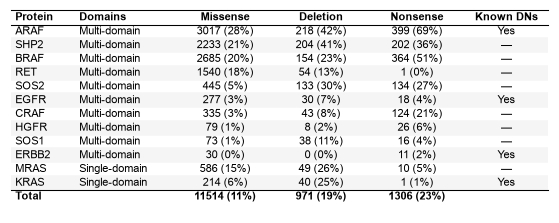

In [10]:
# ======================================================================
# Figure 3B — DN summary table — Configuration
# ======================================================================

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']
plt.rcParams['figure.facecolor'] = 'none'
plt.rcParams['axes.facecolor'] = 'none'
plt.rcParams['savefig.facecolor'] = 'none'

# Font sizes
FONT_SIZE_TITLE = 10
FONT_SIZE_LABEL = 9
FONT_SIZE_TICK = 8
FONT_SIZE_LEGEND = 8

# Line widths
LINE_WIDTH_AXES = 0.6
LINE_WIDTH_PLOT = 1.0


def plot_dn_summary_table(
    table: pd.DataFrame,
    *,
    col_widths: Sequence[float] = (0.10, 0.16, 0.15, 0.15, 0.15, 0.13),
    left_cols: set[int] = frozenset({0, 1}),
    row_h: float = 0.1625,
    header_h: float = 0.17,
    width_scale: float = 7.5,
    fontsize: float = 7.0,
    zebra: str = "#f5f5f5",
    rule_color: str = "black",
    rule_lw: float = 0.7,
    bold_rows: set[int] = frozenset(),
    rule_above_rows: set[int] = frozenset(),
    bottom_rule: bool = True,
) -> tuple[Figure, Axes]:
    """Compact line-ruled summary table.

    Verbatim port of ``render_table`` in ``scripts/make_dn_summary_table.py``,
    which follows ``Dominant_negative.ipynb`` cell 19: three horizontal rules
    (top, under the header, bottom), 7 pt text, faint zebra shading, no cell
    borders and no filled header. The first two columns are left-aligned and
    the rest centred, and the figure width is set by the column widths so the
    panel comes out at a fixed compact size.

    Args:
        table: Already-formatted strings; column order is taken as given.
        col_widths: Relative widths, one per column. Their sum times
            ``width_scale`` is the figure width in inches.
        left_cols: Indices of left-aligned columns; others are centred.
        bold_rows: 0-based data-row indices (not counting the header) to
            render bold, e.g. a trailing "Total" row: ``{len(table) - 1}``.
        rule_above_rows: 0-based data-row indices to draw a rule above (e.g.
            to set a trailing "Total" row off from the rows above it, use
            ``{len(table) - 1}`` here too).
        bottom_rule: Draw the closing rule under the last row. Set False if
            ``rule_above_rows`` already puts a rule right above a final
            summary row and a second rule immediately below it would be
            redundant.
    """
    labels = list(table.columns)
    n_rows = len(table)
    total_w = sum(col_widths)
    fig_w = total_w * width_scale
    fig_h = header_h + row_h * n_rows + 0.10

    fig, ax = plt.subplots(figsize=(fig_w, fig_h))
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis("off")

    x_starts, x = [], 0.0
    for w in col_widths:
        x_starts.append(x / total_w)
        x += w

    y_top = 1.0
    y_header = y_top - header_h / fig_h
    row_step = row_h / fig_h

    def draw_line(y: float) -> None:
        ax.plot([0, 1], [y, y], color=rule_color, linewidth=rule_lw,
                transform=ax.transAxes, clip_on=False)

    def x_pos(j: int) -> tuple[float, str]:
        if j in left_cols:
            return x_starts[j] + 0.008, "left"
        return x_starts[j] + col_widths[j] / total_w / 2, "center"

    for j, label in enumerate(labels):
        xp, ha = x_pos(j)
        ax.text(xp, (y_top + y_header) / 2, label, transform=ax.transAxes,
                ha=ha, va="center", fontsize=fontsize, fontweight="bold")
    draw_line(y_top)
    draw_line(y_header)

    for i, (_, row) in enumerate(table.iterrows()):
        if i in rule_above_rows:
            draw_line(y_header - i * row_step)
        y_mid = y_header - (i + 0.5) * row_step
        if i % 2 == 1:
            ax.axhspan(y_header - (i + 1) * row_step,
                       y_header - i * row_step, xmin=0, xmax=1,
                       color=zebra, zorder=0)
        weight = "bold" if i in bold_rows else "normal"
        for j, label in enumerate(labels):
            xp, ha = x_pos(j)
            ax.text(xp, y_mid, str(row[label]), transform=ax.transAxes,
                    ha=ha, va="center", fontsize=fontsize, fontweight=weight)
    if bottom_rule:
        draw_line(y_header - n_rows * row_step)
    return fig, ax


# --- Generate plot ---

DOMAIN_ARCHITECTURE = {
    "araf": "Multi-domain", "braf": "Multi-domain", "craf": "Multi-domain",
    "shp2": "Multi-domain",
    "egfr": "Multi-domain", "erbb2": "Multi-domain",
    "met": "Multi-domain", "ret": "Multi-domain",
    "sos1": "Multi-domain", "sos2": "Multi-domain",
    "kras": "Single-domain", "mras": "Single-domain",
}
# Literature-validated dominant negatives, named. Not an exhaustive search.
KNOWN_DNS = {
    "kras": "S17N",
    "egfr": "kinase-dead, truncated",
    "araf": "DA-Raf",
    "erbb2": "??"
}
MUT_TYPES = ["missense", "deletion", "nonsense"]

records = []
for protein in DN_ELIGIBLE:
    sub = dn_pool[dn_pool.protein == protein]
    dn = sub[sub.is_dn]
    row = {"Protein": protein_label(protein),
           "Domains": DOMAIN_ARCHITECTURE[protein], "_miss_pct": 0.0}
    for mt in MUT_TYPES:
        n_dn = dn.loc[dn["Mutation Type"] == mt, "variant"].nunique()
        n_tot = sub.loc[sub["Mutation Type"] == mt, "variant"].nunique()
        if n_tot > 0:
            pct = 100 * n_dn / n_tot
            if mt == "missense":
                row["_miss_pct"] = pct
            row[mt.capitalize()] = f"{n_dn} ({pct:.0f}%)"
        else:
            row[mt.capitalize()] = str(n_dn)
    # Just "Yes" if this protein has a known literature DN, else an em dash.
    row["Known DNs"] = "Yes" if protein in KNOWN_DNS else "\u2014"
    records.append(row)

# Multi-domain first, then single-domain; within each, descending missense rate.
tbl = pd.DataFrame(records)
tbl["_is_single"] = (tbl.Domains == "Single-domain").astype(int)
tbl = (tbl.sort_values(["_is_single", "_miss_pct"], ascending=[True, False])
       .drop(columns=["_miss_pct", "_is_single"]).reset_index(drop=True))
tbl = tbl[["Protein", "Domains", "Missense", "Deletion", "Nonsense",
           "Known DNs"]]

# Final row: total N and total % DN for each mutation type, pooled across all
# DN-eligible proteins (recomputed from dn_pool directly, not by summing the
# already-rounded per-protein percentages).
#
# NB: count unique (protein, variant) pairs, not the bare `variant` string.
# A handful of variant labels (e.g. short "p.G12D"-style codes) are shared
# by more than one DN-eligible protein; pooling on `variant` alone silently
# collapsed those cross-protein duplicates into a single count (this
# previously undercounted total missense DN variants as 11,412 instead of
# the correct 11,514).
_all_sub = dn_pool[dn_pool.protein.isin(DN_ELIGIBLE)]
_all_dn = _all_sub[_all_sub.is_dn]
_total_row = {"Protein": "Total", "Domains": ""}
for mt in MUT_TYPES:
    _n_dn = (_all_dn.loc[_all_dn["Mutation Type"] == mt, ["protein", "variant"]]
             .drop_duplicates().shape[0])
    _n_tot = (_all_sub.loc[_all_sub["Mutation Type"] == mt, ["protein", "variant"]]
              .drop_duplicates().shape[0])
    _pct = 100 * _n_dn / _n_tot if _n_tot > 0 else 0.0
    _total_row[mt.capitalize()] = f"{_n_dn} ({_pct:.0f}%)"
_total_row["Known DNs"] = ""
tbl = pd.concat([tbl, pd.DataFrame([_total_row])], ignore_index=True)

fig, _ = plot_dn_summary_table(
    tbl, bold_rows={len(tbl) - 1}, rule_above_rows={len(tbl) - 1}, bottom_rule=False)
save_figure(fig, FIG / "4b_summary_table", formats=("pdf", "svg"))
plt.show()



## Figure 4C — Structural enrichment forest

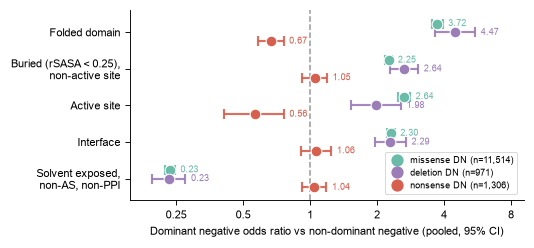

In [11]:
# ======================================================================
# Figure 4C — Structural enrichment forest — Configuration
# ======================================================================

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']
plt.rcParams['figure.facecolor'] = 'none'
plt.rcParams['axes.facecolor'] = 'none'
plt.rcParams['savefig.facecolor'] = 'none'

# Font sizes
FONT_SIZE_TITLE = 10
FONT_SIZE_LABEL = 9
FONT_SIZE_TICK = 8
FONT_SIZE_LEGEND = 8

# Line widths
LINE_WIDTH_AXES = 0.6
LINE_WIDTH_PLOT = 1.0


def plot_forest(
    df: pd.DataFrame,
    *,
    label_col: str,
    or_col: str = "or",
    lo_col: str = "ci_low",
    hi_col: str = "ci_high",
    series_col: str | None = None,
    label_order: Sequence[str] | None = None,
    series_order: Sequence[str] | None = None,
    series_colors: Mapping[str, str] | None = None,
    series_dy: Mapping[str, float] | float = 0.24,
    series_n: Mapping[str, int] | None = None,
    figsize: tuple[float, float] = (7.6, 4.7),
    xticks: Sequence[float] = (0.25, 0.5, 1, 2, 4, 8),
    xlim_pad: tuple[float, float] = (0.80, 1.65),
    xlabel: str = "Dominant negative odds ratio (pooled, 95% CI)",
    title: str = "DN structural enrichment",
    annotate_or: bool = True,
    or_fmt: str = "{:.2f}",
    annot_col: str | None = None,
    markersize: float = 7.0,
    annot_x_mult: float = 1.06,
    elinewidth: float = 1.4,
    capsize: float = 3.5,
    legend_loc: str = "lower right",
    legend_fmt: str = "{series} DN (n={n:,})",
    fs: Mapping[str, float] | None = None,
) -> tuple[Figure, Axes]:
    """Dot + 95% CI odds-ratio forest on a log axis.

    Port of ``scripts/plot_dn_structural_enrichment_forest_pooled.py`` — same
    7.6x4.7 in panel, per-variant-type colours, +/-0.24 vertical offsets,
    7.0 pt markers, 1.4 pt whiskers with 3.5 pt caps, dashed OR=1 reference at
    ``#999999``, log ticks 0.25-8, the OR value printed at 1.06x the CI upper
    bound, and a light-framed legend in the lower-right corner. Font sizes are
    ~1.5x print-final so the panel stays legible after the 67% downscale used
    when placing it.

    Also used for the population-depletion forest by passing
    ``series_colors=DB_COLORS`` and a different ``xlabel``/``title``.

    Args:
        df: One row per (label, series) with the OR and its interval.
        label_col: Column holding the y-axis category.
        series_col: Optional column splitting into vertically-offset series.
        label_order / series_order: Explicit ordering; defaults to order of
            appearance. ``label_order`` is top-to-bottom.
        series_colors: series -> colour. Defaults to
            :data:`VARIANT_TYPE_COLORS`.
        series_dy: Vertical offset per series, or a scalar half-spread that is
            spread evenly across the series.
        series_n: series -> n, for the legend.
        xlim_pad: Multiplicative padding on (min CI low, max CI high).
        fs: Font-size overrides; keys ``title``, ``y``, ``x``, ``tick``,
            ``or``, ``legend``.
    """
    F = {"title": 16, "y": 13, "x": 14, "tick": 12, "or": 9.5, "legend": 11}
    F.update(fs or {})

    labels = list(label_order or dict.fromkeys(df[label_col]))
    series = list(series_order or (dict.fromkeys(df[series_col])
                                  if series_col else [None]))
    colors = dict(series_colors or VARIANT_TYPE_COLORS)
    for i, s in enumerate(series):
        colors.setdefault(s, list(VARIANT_TYPE_COLORS.values())[
            i % len(VARIANT_TYPE_COLORS)])

    if isinstance(series_dy, Mapping):
        dy = dict(series_dy)
    elif len(series) > 1:
        dy = dict(zip(series, np.linspace(series_dy, -series_dy, len(series))))
    else:
        dy = {series[0]: 0.0}

    n_lab = len(labels)
    y_of = {k: n_lab - i for i, k in enumerate(labels)}

    fig, ax = plt.subplots(figsize=figsize)
    xmin, xmax = np.inf, -np.inf
    for s in series:
        sub = df if s is None else df[df[series_col] == s]
        col = colors[s]
        for _, r in sub.iterrows():
            if r[label_col] not in y_of or not np.isfinite(r[or_col]):
                continue
            y = y_of[r[label_col]] + dy.get(s, 0.0)
            v, lo, hi = float(r[or_col]), float(r[lo_col]), float(r[hi_col])
            if not (np.isfinite(lo) and np.isfinite(hi)):
                lo = hi = v
            xmin, xmax = min(xmin, lo), max(xmax, hi)
            ax.errorbar(v, y, xerr=[[max(v - lo, 0)], [max(hi - v, 0)]],
                        fmt="none", ecolor=col, elinewidth=elinewidth,
                        capsize=capsize, capthick=elinewidth, alpha=0.9,
                        zorder=2)
            ax.plot(v, y, marker="o", markersize=markersize, linestyle="",
                    color=col, markeredgecolor="white", markeredgewidth=0.7,
                    zorder=3)
            if annot_col is not None:
                txt = str(r.get(annot_col, "") or "")
            elif annotate_or:
                txt = or_fmt.format(v)
            else:
                txt = ""
            if txt:
                ax.text(hi * annot_x_mult, y, txt, ha="left", va="center",
                        fontsize=F["or"], color=col, zorder=3, clip_on=False)

    ax.axvline(1.0, color="#999999", linewidth=1.0, linestyle="--", zorder=1)
    ax.set_xscale("log")
    if np.isfinite(xmin):
        ax.set_xlim(xmin * xlim_pad[0], xmax * xlim_pad[1])
    ax.set_xticks(list(xticks))
    ax.set_xticklabels([str(t) for t in xticks], fontsize=F["tick"])
    ax.minorticks_off()

    ax.set_yticks([y_of[k] for k in labels])
    ax.set_yticklabels(labels, fontsize=F["y"])
    ax.set_ylim(0.4, n_lab + 0.6)
    ax.set_xlabel(xlabel, fontsize=F["x"])
    if title:
        ax.set_title(title, fontsize=F["title"], pad=8)
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)
    ax.tick_params(length=3)

    if series_col is not None:
        handles = [
            plt.Line2D([0], [0], marker="o", linestyle="",
                       markersize=markersize, markerfacecolor=colors[s],
                       markeredgecolor=colors[s],
                       label=legend_fmt.format(series=s,
                                               n=(series_n or {}).get(s, 0)))
            for s in series]
        leg = ax.legend(handles=handles, fontsize=F["legend"], loc=legend_loc,
                        frameon=True, handletextpad=0.4, labelspacing=0.4,
                        borderaxespad=0.7)
        leg.get_frame().set_edgecolor("#cccccc")
        leg.get_frame().set_facecolor("white")
        leg.get_frame().set_linewidth(0.6)
    fig.tight_layout()
    return fig, ax


# --- Generate plot ---

rsa = pd.to_numeric(dn_pool.relative_sasa, errors="coerce")  
  
dn_pool["in_domain"] = dn_pool.domain.notna() & dn_pool.domain.ne("none")  
dn_pool["is_active_site"] = dn_pool.active_site.astype(bool)  
# Buried excludes the active site, so "Buried" and "Active site" rows below  
# are mutually exclusive (matches the "B excludes AS" convention used for the  
# Fig 4D ontology buckets, e.g. md_dn["B"] = md_dn.is_buried & ~md_dn.is_active_site).  
dn_pool["is_buried"] = rsa.lt(0.25) & ~dn_pool.is_active_site  
dn_pool["is_interface"] = dn_pool.interface_pdb_curated.astype(bool)  
dn_pool["is_exposed_other"] = (rsa.ge(0.25) & ~dn_pool.is_active_site  
                               & ~dn_pool.is_interface)  

# Helix / Sheet / No SS annotation rows dropped from the panel.
FEATURES = {
    "in_domain": "Folded domain",
    "is_buried": "Buried (rSASA < 0.25),\nnon-active site",
    "is_active_site": "Active site",
    "is_interface": "Interface",
    "is_exposed_other": "Solvent exposed,\nnon-AS, non-PPI",
}

rows = []
for vtype in ("missense", "deletion", "nonsense"):
    sub = dn_pool[dn_pool["Mutation Type"] == vtype]
    r = enrichment(sub, list(FEATURES), group_col="is_dn")
    r["Mutation Type"] = vtype
    r["n_dn"] = int(sub.is_dn.sum())
    rows.append(r)
enr = pd.concat(rows, ignore_index=True)
enr["label"] = enr.feature.map(FEATURES)
enr.to_csv(FIG / "fig3c_structural_enrichment.tsv", sep="\t", index=False)

fig, ax = plot_forest(
    enr, label_col="label",
    label_order=[FEATURES[k] for k in FEATURES],
    series_col="Mutation Type", series_order=VARIANT_TYPE_ORDER,
    series_colors=VARIANT_TYPE_COLORS,
    series_n=enr.drop_duplicates("Mutation Type")
               .set_index("Mutation Type")["n_dn"].to_dict(),
    xlabel="Dominant negative odds ratio vs non-dominant negative (pooled, 95% CI)",
    title="",
    figsize=(4.9, 2.3),
    fs={"title": 7, "y": 7, "x": 7, "tick": 7, "or": 6, "legend": 6},
)
save_figure(fig, FIG / "4c_structural_enrichment_forest")
plt.show()
# display(enr.pivot(index="label", columns="Mutation Type", values="or").round(2))


## Figure 4D — DN ontology composition

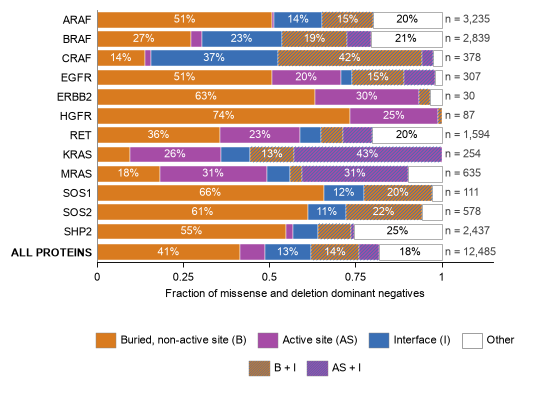

pooled (n=12,485): B_only 41.5%, none 18.3%, B_I 14.1%, I_only 13.4%, AS_only 7.2%, AS_I 5.6%
exactly one category 62.0%; more than one 19.7%; none 18.3%


In [13]:
# ======================================================================
# Figure 4D — DN ontology composition — Configuration
# ======================================================================

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']
plt.rcParams['figure.facecolor'] = 'none'
plt.rcParams['axes.facecolor'] = 'none'
plt.rcParams['savefig.facecolor'] = 'none'

# Font sizes
FONT_SIZE_TITLE = 10
FONT_SIZE_LABEL = 9
FONT_SIZE_TICK = 8
FONT_SIZE_LEGEND = 8

# Line widths
LINE_WIDTH_AXES = 0.6
LINE_WIDTH_PLOT = 1.0


def plot_stacked_hbar(
    frac: pd.DataFrame,
    *,
    counts: Mapping[str, int] | pd.Series | None = None,
    bucket_style: Mapping[str, tuple] | None = None,
    bucket_order: Sequence[str] | None = None,
    bucket_labels: Mapping[str, str] | None = None,
    legend_rows: Sequence[Sequence[str]] | None = None,
    pooled_row: str | None = None,
    bar_h: float = 0.82,
    pooled_gutter_mult: float = 1.5,
    annotate_threshold: float = 0.10,
    fig_w: float = 8.0,
    bar_pitch_in: float = 0.33,
    top_margin_in: float = 0.20,
    bottom_margin_in: float = 0.06,
    legend_in: float = 0.55,
    xlabel_gap_in: float = 0.55,
    xlabel: str = "Fraction of dominant negatives",
    n_fmt: str = "n = {:,}",
    fs: Mapping[str, float] | None = None,
    figsize: tuple[float, float] | None = None,
) -> tuple[Figure, Axes]:
    """Horizontal stacked composition bars, one per category.

    Port of ``scripts/plot_dn_ontology_v4_pooled_coverage_horizontal.py``:
    8.0 in wide, 0.82-thick bars so rows nearly touch, hatched overlays for
    the two-category combos, white segment labels above 10%, ``n = X`` at the
    right edge, and a flow legend band beneath. An optional pooled
    "ALL PROTEINS" bar is separated by 1.5x the normal gutter.

    ``bucket_style`` maps bucket -> ``(facecolor, hatch_colour, hatch_pattern)``
    with the last two None for a solid fill; defaults to
    :data:`ONTOLOGY_BUCKET_STYLE`.

    Args:
        frac: Rows are bars, columns are buckets; values are fractions.
        counts: Per-bar n, printed at the right edge.
        pooled_row: Index label to place last and separate by a wider gutter.
        annotate_threshold: Segments at or below this fraction go unlabelled.
        fs: Font-size overrides; keys ``cat``, ``tick``, ``axis``, ``seg``,
            ``n``, ``legend``.
        figsize: Optional ``(width, height)`` in inches for the final
            figure. Margins, the legend band, and the x-label gap stay
            fixed in inches; only the bar thickness (``bar_pitch_in``) is
            solved for so the bars fill exactly the remaining height.
    """
    F = {"cat": 14, "tick": 13, "axis": 14, "seg": 11, "n": 9, "legend": 13}
    F.update(fs or {})
    style = dict(bucket_style or ONTOLOGY_BUCKET_STYLE)
    order = list(bucket_order or [b for b in ONTOLOGY_BUCKET_ORDER
                                  if b in frac.columns])
    labels = dict(bucket_labels or ONTOLOGY_BUCKET_LABELS)

    rows = [r for r in frac.index if r != pooled_row]
    y_of = {r: i for i, r in enumerate(rows)}
    normal_gutter = 1.0 - bar_h
    if pooled_row is not None and pooled_row in frac.index:
        y_of[pooled_row] = (len(rows) - 1) + bar_h + pooled_gutter_mult * normal_gutter
    n_rows_eq = max(y_of.values()) + 1

    if figsize is not None:
        fig_w, fig_h_target = figsize
        available = (fig_h_target - top_margin_in - xlabel_gap_in
                     - legend_in - bottom_margin_in)
        bar_pitch_in = max(available, 0.05) / n_rows_eq
    bars_in = bar_pitch_in * n_rows_eq
    fig_h = top_margin_in + bars_in + xlabel_gap_in + legend_in + bottom_margin_in
    fig = plt.figure(figsize=(fig_w, fig_h))
    ax = fig.add_axes([0.11, (bottom_margin_in + legend_in + xlabel_gap_in) / fig_h,
                       0.80, bars_in / fig_h])
    legend_ax = fig.add_axes([0.07, bottom_margin_in / fig_h, 0.92,
                              legend_in / fig_h])

    # Hatch overlays are drawn after the axes' final x/y limits are set (see
    # `_draw_diagonal_hatch`), so their rectangles are queued here rather
    # than drawn inline.
    _pending_hatches = []
    for row, y in y_of.items():
        cum = 0.0
        for b in order:
            f = float(frac.loc[row, b]) if b in frac.columns else 0.0
            if f <= 0 or not np.isfinite(f):
                continue
            face, hatch_col, hatch_pat = style.get(b, ("#999999", None, None))
            is_none = b in ("none", "Other")
            ax.add_patch(plt.Rectangle(
                (cum, y - bar_h / 2), f, bar_h, facecolor=face,
                edgecolor=ONTOLOGY_NONE_EDGE if is_none else "white",
                linewidth=0.5 if is_none else 0.3, zorder=2))
            if hatch_pat:
                _pending_hatches.append((cum, y - bar_h / 2, f, bar_h, hatch_col))
            if f > annotate_threshold:
                ax.text(cum + f / 2, y, f"{int(round(f * 100))}%",
                        ha="center", va="center", fontsize=F["seg"],
                        color="black" if is_none else "white", zorder=4)
            cum += f
        if counts is not None and row in counts:
            ax.text(1.01, y, n_fmt.format(int(counts[row])), ha="left",
                    va="center", fontsize=F["n"], color="#444444")

    # xlim to 1.15 leaves room for the "n = X" labels at x=1.01.
    ax.set_xlim(0, 1.15)
    ax.set_ylim(-0.5, max(y_of.values()) + 0.5)
    ax.invert_yaxis()
    for cum, y0, f, h, hatch_col in _pending_hatches:
        _draw_diagonal_hatch(ax, cum, y0, f, h, color=hatch_col)
    ax.set_yticks(list(y_of.values()))
    ax.set_yticklabels([protein_label(r) if str(r).lower() in PROTEIN_KEYS
                        else str(r) for r in y_of], fontsize=F["cat"])
    if pooled_row is not None and pooled_row in frac.index:
        ax.get_yticklabels()[-1].set_fontweight("bold")
    ax.set_xticks([0, 0.25, 0.5, 0.75, 1.0])
    ax.set_xticklabels(["0", "0.25", "0.5", "0.75", "1"], fontsize=F["tick"])
    ax.set_xlabel(xlabel, fontsize=F["axis"])
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color("#888")
    ax.tick_params(axis="y", length=0)

    # Two-row flowed legend, each row centred. Item widths are *measured* from
    # the renderer rather than estimated, so long names ("Active site (AS)")
    # and short ones ("AS + I") coexist without a fixed grid clipping either.
    legend_ax.set_xlim(0, 1)
    legend_ax.set_ylim(0, 1)
    legend_ax.axis("off")
    sw, sh, gap, item_gap = 0.045, 0.24, 0.010, 0.024
    fig.canvas.draw()
    rend = fig.canvas.get_renderer()
    ax_w = legend_ax.get_window_extent(rend).width

    def _text_w(s: str) -> float:
        probe = legend_ax.text(0, -2, s, fontsize=F["legend"])
        w = probe.get_window_extent(rend).width / ax_w
        probe.remove()
        return w

    rows = legend_rows or [[b for b in order]]
    for row_buckets, y0 in zip(rows, (0.70, 0.24)):
        row_buckets = [b for b in row_buckets if b in style]
        if not row_buckets:
            continue
        widths = [sw + gap + _text_w(labels.get(b, b)) for b in row_buckets]
        total = sum(widths) + item_gap * (len(row_buckets) - 1)
        x = (1.0 - total) / 2.0
        for b, w in zip(row_buckets, widths):
            face, hatch_col, hatch_pat = style[b]
            is_none = b in ("none", "Other")
            legend_ax.add_patch(plt.Rectangle(
                (x, y0 - sh / 2), sw, sh, facecolor=face,
                edgecolor=ONTOLOGY_NONE_EDGE if is_none else "#888",
                linewidth=0.6 if is_none else 0.3))
            if hatch_pat:
                _draw_diagonal_hatch(legend_ax, x, y0 - sh / 2, sw, sh,
                                     color=hatch_col, lw=0.4, spacing_pt=1.6)
            legend_ax.text(x + sw + gap, y0, labels.get(b, b), va="center",
                           ha="left", fontsize=F["legend"])
            x += w + item_gap
    return fig, ax


# --- Generate plot ---

md_dn = dn_pool[dn_pool.is_dn
                & dn_pool["Mutation Type"].isin(["missense", "deletion"])].copy()
# v4: B excludes the active site, so B and AS cannot co-occur.
md_dn["B"] = md_dn.is_buried & ~md_dn.is_active_site
md_dn["AS"] = md_dn.is_active_site
md_dn["I"] = md_dn.is_interface

# v4's six buckets. B excludes the active site by construction, so B+AS
# (and B+AS+I) cannot occur — six buckets, not seven.
def _bucket(r):
    on = tuple(k for k in ("B", "AS", "I") if r[k])
    return {(): "none", ("B",): "B_only", ("AS",): "AS_only",
            ("I",): "I_only", ("B", "I"): "B_I",
            ("AS", "I"): "AS_I"}[on]

md_dn["bucket"] = md_dn.apply(_bucket, axis=1)
frac = (md_dn.groupby(["protein", "bucket"]).size().unstack(fill_value=0)
        .reindex(columns=ONTOLOGY_BUCKET_ORDER, fill_value=0))
counts = frac.sum(axis=1)
frac = frac.div(counts, axis=0).reindex(
    [p for p in DN_ORDER if p in frac.index])

# Pooled bar, separated from the per-protein rows by a wider gutter.
POOLED = "ALL PROTEINS"   # bolded, separated by a wider gutter
pooled_counts = md_dn.bucket.value_counts()
frac.loc[POOLED] = (pooled_counts / pooled_counts.sum()).reindex(
    ONTOLOGY_BUCKET_ORDER).fillna(0.0)
counts.loc[POOLED] = len(md_dn)

fig, _ = plot_stacked_hbar(  
    frac, counts=counts, pooled_row=POOLED,  
    legend_rows=ONTOLOGY_LEGEND_ROWS,  
    xlabel="Fraction of missense and deletion dominant negatives",  
    figsize=(4.5, 3.65),  
    fs={"cat": 7, "tick": 7, "axis": 7, "seg": 7, "n": 7, "legend": 7},  
)  
save_figure(fig, FIG / "4d_ontology_composition")
plt.show()

pooled = md_dn.bucket.value_counts(normalize=True)
print(f"pooled (n={len(md_dn):,}): "
      + ", ".join(f"{k} {v:.1%}" for k, v in pooled.items()))
# Bucket names are B_only / AS_only / I_only / B_I / AS_I / none -- reindexing
# on anything else silently yields all-zero percentages, so the assertion below
# checks they sum to 1.
single = pooled.reindex(["B_only", "AS_only", "I_only"]).fillna(0).sum()
multi = pooled.reindex(["B_I", "AS_I"]).fillna(0).sum()
none = float(pooled.get("none", 0.0))
assert abs(single + multi + none - 1.0) < 1e-9, "buckets do not sum to 1"
print(f"exactly one category {single:.1%}; "
      f"more than one {multi:.1%}; none {none:.1%}")


## Figure S7A — Per-protein enrichment bubble grid

/tmp/27474974.1.shendure-login.q/ipykernel_2770373/771055717.py:74: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.savefig(p, **kw)
/net/gs/vol3/software/modules-sw/python/3.12.1/Linux/Ubuntu22.04/x86_64/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


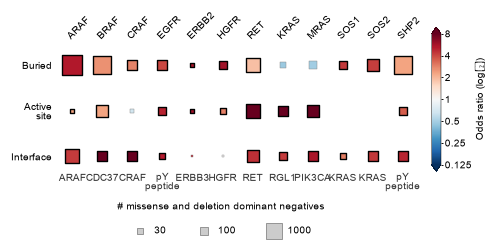

protein,araf,braf,craf,egfr,erbb2,met,ret,kras,mras,sos1,sos2,shp2
category,,,,,,,,,,,,
AS,2.31,2.30,0.67,4.99,5.80,2.83,9.27,8.99,9.00,NaN,NaN,3.53
B,5.31,2.57,2.80,3.99,5.49,5.84,1.88,0.46,0.48,4.33,4.18,2.30
I,4.31,7.98,15.01,5.20,4.88,1.01,4.59,4.31,5.44,2.90,4.36,4.89


In [14]:
# ======================================================================
# Figure S3A — Per-protein enrichment bubble grid — Configuration
# ======================================================================

# Font sizes
FONT_SIZE_TITLE = 6.5
FONT_SIZE_LABEL = 6.5
FONT_SIZE_TICK = 6.5
FONT_SIZE_LEGEND = 6.5

# Line widths
LINE_WIDTH_AXES = 0.6
LINE_WIDTH_PLOT = 1.0


def plot_bubble_grid(
    entries: pd.DataFrame,
    *,
    col_col: str = "protein",
    row_col: str = "category",
    size_col: str = "n_dn_in",
    or_col: str = "or",
    fires_col: str = "fires",
    partner_col: str | None = "partner",
    col_order: Sequence[str] | None = None,
    row_order: Sequence[str] = ("B", "AS", "I"),
    row_labels: Mapping[str, str] | None = None,
    figsize: tuple[float, float] = (5.04, 2.52),
    axes_rect: Sequence[float] = (0.155, 0.25, 0.65, 0.47),
    cbar_rect: Sequence[float] = (0.83, 0.27, 0.017, 0.52),
    log2_lim: tuple[float, float] = (-3.0, 3.0),
    n_ref_area: float = 28.0,
    n_ref_count: float = 100.0,
    area_gamma: float = 0.6,
    legend_counts: Sequence[int] = (30, 100, 1000),
    or_label: str = "Odds ratio (log₂)",
    size_label: str = "# missense and deletion dominant negatives",
    fs: Mapping[str, float] | None = None,
) -> tuple[Figure, Axes]:
    """Grid of squares: area = count, fill = log2 OR, border = significance.

    Port of ``scripts/plot_dn_ontology_v4_combined_bubble_horizontal.py`` — the
    fixed 5.04x2.52 in panel with the axes at an absolute rectangle, RdBu_r on a
    two-slope norm over OR 1/8 to 8 with extend arrows, sub-linear marker area
    (``28 * (n/100)**0.6``) so large counts do not dwarf small ones, black
    border at significance and ``#888`` otherwise, protein labels on top at 45
    degrees, interface partner names written horizontally under the bottom row,
    a vertical colourbar at the right and a size legend along the bottom.

    Saved deliberately **without** ``bbox_inches="tight"`` in the original so
    the panel is exactly the requested size; pass ``tight=False`` to
    :func:`save_figure` to preserve that.

    Args:
        entries: One row per cell. Rows with a non-positive ``size_col`` are
            skipped, as are rows where ``or_col`` is not positive.
        partner_col: If given, its value is printed beneath the bottom row
            (used for the driving interface partner).
        fs: Font-size overrides; keys ``row``, ``col``, ``cbar``,
            ``cbar_tick``, ``legend``, ``partner``, ``size_label``.
    """
    import matplotlib.colors as mcolors

    F = {"row": 6.5, "col": 6.5, "cbar": 6.5, "cbar_tick": 6.5, "legend": 6.5,
         "partner": 6.5, "size_label": 6.5}
    F.update(fs or {})
    labels = dict(row_labels or {"B": "Buried", "AS": "Active\nsite",
                                 "I": "Interface"})
    cols = list(col_order or [p for p in DN_ORDER
                              if p in set(entries[col_col])])
    rows = list(row_order)
    x_of = {c: i for i, c in enumerate(cols)}
    y_of = {r: len(rows) - 1 - i for i, r in enumerate(rows)}

    def _area(n):
        return 0.0 if n <= 0 else n_ref_area * (n / n_ref_count) ** area_gamma

    fig = plt.figure(figsize=figsize)
    ax = fig.add_axes(list(axes_rect))
    cmap = plt.get_cmap("RdBu_r")
    norm = mcolors.TwoSlopeNorm(vcenter=0.0, vmin=log2_lim[0], vmax=log2_lim[1])

    for _, e in entries.iterrows():
        if e[col_col] not in x_of or e[row_col] not in y_of:
            continue
        n = e[size_col]
        v = e[or_col]
        if not np.isfinite(n) or n <= 0 or not np.isfinite(v) or v <= 0:
            continue
        ax.scatter([x_of[e[col_col]]], [y_of[e[row_col]]], s=_area(n),
                   marker="s", facecolor=cmap(norm(np.log2(v))),
                   edgecolor="black" if bool(e.get(fires_col)) else "#888888",
                   linewidth=0.9 if bool(e.get(fires_col)) else 0.3, zorder=3)
        if partner_col and e[row_col] == rows[-1] and e.get(partner_col):
            p = str(e[partner_col])
            txt = (protein_label(e[col_col]) if p == "dimer"
                   else "pY\npeptide" if p == "pY_peptide" else p.upper())
            ax.text(x_of[e[col_col]], -0.36, txt, ha="center", va="top",
                    fontsize=F["partner"], color="#333333", linespacing=1.0,
                    zorder=4)

    ax.set_yticks([y_of[r] for r in rows])
    ax.set_yticklabels([labels.get(r, r) for r in rows], fontsize=F["row"],
                       linespacing=1.0)
    ax.set_xticks(range(len(cols)))
    ax.xaxis.tick_top()
    ax.set_xticklabels(protein_labels(cols), fontsize=F["col"], rotation=45,
                       ha="left", rotation_mode="anchor")
    ax.set_xlim(-0.5, len(cols) - 0.5)
    ax.set_ylim(-0.45, len(rows) - 0.6)
    ax.tick_params(axis="both", length=0)
    for s in ax.spines.values():
        s.set_visible(False)

    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cax = fig.add_axes(list(cbar_rect))
    ticks = list(range(int(log2_lim[0]), int(log2_lim[1]) + 1))
    cbar = fig.colorbar(sm, cax=cax, ticks=ticks, extend="both")
    cbar.set_label(or_label, fontsize=F["cbar"], labelpad=2)
    cbar.ax.set_yticklabels([f"{2.0 ** t:g}" for t in ticks],
                            fontsize=F["cbar_tick"])
    cbar.outline.set_linewidth(0.3)
    cbar.ax.tick_params(length=1.5, pad=1)

    handles = [plt.scatter([], [], s=_area(n), marker="s", facecolor="#cccccc",
                           edgecolor="#666666", linewidth=0.4, label=f"{n}")
               for n in legend_counts]
    fig.legend(handles=handles, loc="lower center", bbox_to_anchor=(0.45, 0.015),
               ncol=len(legend_counts), frameon=False, fontsize=F["legend"],
               handletextpad=0.4, columnspacing=2.8, borderpad=0.15)
    fig.text(0.45, 0.125, size_label, ha="center", va="bottom",
             fontsize=F["size_label"])
    return fig, ax


# --- Generate plot ---

MIN_PARTNER_POSITIONS = 3     # floor to be TESTED at all, unique positions
MIN_TOP_POSITIONS = 10        # floor to be eligible as the TOP partner
PARTNER_FIRE_Q = 1e-3         # stricter than the 0.05 used for B / AS

# Curated partner names are pooled onto display names: the HSP90 paralogs are
# one chaperone, and the several curated pY peptides all occupy the same SH2 /
# phosphatase substrate pocket.
PARTNER_ALIASES = {
    "hsp90a": "hsp90", "hsp90b": "hsp90", "heat_shock_protein_83": "hsp90",
    "protein_(rvipyfvplnr_peptide)": "pY_peptide",
    "rlnpyaqlwhr_peptide": "pY_peptide",
    "shc_peptide_substrate": "pY_peptide",
    "peptide_substrate": "pY_peptide",
    "myelin_protein_zero-like_protein_1_(mpzl1)": "mpzl1",
    "target_of_repamycin_complex_2_subunit_mapkap1": "mapkap1",
    "peptidyl-prolyl_cis-trans_isomerase_a": "ppiase_a",
    "proto-oncogene_vav": "vav",
    "pp1ca": "ppp1ca",
    "protein_farnesyltransferase/geranyltransferase_type-1_subunit_alpha": "farnesyltransferase",
    "protein_farnesyltransferase_subunit_beta": "farnesyltransferase",
}


def partner_key(raw: str, protein: str) -> str:
    """Raw curated partner name -> pooled display key.

    A protein listed as its own partner is the homodimer surface, which the
    figure shows under the protein's own name.
    """
    k = str(raw).strip().lower().replace(" ", "_")
    if k == protein:
        return "dimer"
    return PARTNER_ALIASES.get(k, k)


# Structurally defined surfaces that REPLACE a curated partner's positions.
#
# SOS1 engages RAS at two separate sites, and the S3E panel shows both on the
# ternary complex 1XD2, so the statistic is put on the same footing: SOS1 chain C
# against each RAS chain at a 4 A heavy-atom cutoff, chain A giving the
# allosteric (REM) site and chain B the catalytic (CDC25) site, unioned. The two
# sites share no residues.
#
# The 4 A all-atom cutoff matches the curated interface file and the augmented
# rows, and its sets are proper subsets of the wider cutoff, recomputed on 1XD2 chain C vs chains
# A and B.
#
# Note what this costs: the two faces behave oppositely -- the catalytic face is
# strongly DN-enriched and the allosteric face is not -- so the union understates
# the catalytic signal. It is used anyway because it is the surface the figure
# depicts. Splitting the cell in two would show the asymmetry instead. (The
# per-face odds ratios are printed by this cell; they moved with the cutoff.)
SOS1_RAS_ALLOSTERIC = [616, 617, 618, 619, 621, 679, 683, 684, 687, 688, 691,
                       694, 695, 729, 732, 739, 750, 751, 752, 753, 755, 919,
                       920, 921, 922, 923, 924, 973, 974, 976, 978]
SOS1_RAS_CATALYTIC = [589, 602, 809, 814, 822, 824, 825, 829, 832, 875, 876,
                      879, 880, 881, 884, 908, 910, 911, 912, 913, 929, 930,
                      931, 934, 935, 936, 938, 939, 940, 942, 943, 944, 948,
                      950, 959, 963, 1002, 1003, 1006, 1007, 1010, 1019]
STRUCTURAL_SURFACES = {
    ("sos1", "kras"): sorted(set(SOS1_RAS_ALLOSTERIC) | set(SOS1_RAS_CATALYTIC)),
}

# Curated partners superseded by a structural surface above. SOS1's HRAS entry
# describes the SAME two faces as its KRAS entry — RAS paralogs bind SOS1 at the
# same catalytic and allosteric sites — so keeping both would let one physical
# surface compete against itself under two names, and the paralog copy did in
# fact win the top-partner slot by a negligible margin.
SUPERSEDED_PARTNERS = {("sos1", "hras")}


def partner_sets(sub: pd.DataFrame) -> dict[str, set]:
    """position -> partner map inverted to partner -> set of positions."""
    out: dict[str, set] = {}
    protein = sub.protein.iloc[0]
    for pos, raw in zip(sub["Position"], sub.interface_partners):
        if not isinstance(raw, str):
            continue
        for part in raw.split(";"):
            k = partner_key(part, protein)
            if k:
                out.setdefault(k, set()).add(pos)
    for (prot_key, part_key), positions in STRUCTURAL_SURFACES.items():
        if prot_key != protein:
            continue
        # `Position` is a STRING column, so integer residue numbers from a
        # structural definition must be cast to match it. They silently matched
        # nothing before this line existed, which dropped the surface from the
        # candidate list altogether and handed the top-partner slot to a
        # 7-position surface carrying no DNs. Assert rather than trust.
        scanned = set(sub["Position"].dropna())
        keyed = {str(p) for p in positions} & scanned
        assert keyed, (f"{protein}/{part_key}: none of {len(positions)} "
                       "structural positions matched the scanned positions")
        out[part_key] = keyed
    for prot_key, part_key in SUPERSEDED_PARTNERS:
        if prot_key == protein:
            out.pop(part_key, None)
    return out


rows = []
for prot in [p for p in DN_ORDER if p in set(md_dn.protein)]:
    allv = dn_pool[(dn_pool.protein == prot)
                   & dn_pool["Mutation Type"].isin(["missense", "deletion"])]
    if allv.empty:
        continue
    arm = allv.is_dn

    # --- B and AS: single test each, BH over the whole B/AS family below ----
    for col, feat in (("B", allv.is_buried & ~allv.is_active_site),
                      ("AS", allv.is_active_site)):
        if not feat.any():
            continue
        r = fisher_or(int((arm & feat).sum()), int((arm & ~feat).sum()),
                      int((~arm & feat).sum()), int((~arm & ~feat).sum()))
        r.update(protein=prot, category=col, n_dn_in=int((arm & feat).sum()),
                 partner="")
        rows.append(r)

    # --- I: test every partner, BH within this protein, then take the top ---
    cand = []
    for part, positions in partner_sets(allv).items():
        if len(positions) < MIN_PARTNER_POSITIONS:
            continue
        feat = allv["Position"].isin(positions)
        if not feat.any():
            continue
        r = fisher_or(int((arm & feat).sum()), int((arm & ~feat).sum()),
                      int((~arm & feat).sum()), int((~arm & ~feat).sum()))
        r.update(partner=part, n_dn_in=int((arm & feat).sum()),
                 n_pos=len(positions))
        cand.append(r)
    if not cand:
        continue
    cand = pd.DataFrame(cand)
    cand["q"] = bh(cand.p.values)
    cand["fires"] = (cand.q < PARTNER_FIRE_Q) & (cand["or_"] > 1)
    firing = cand[cand.fires]
    pool = firing if not firing.empty else cand
    # Highest OR, among surfaces large enough to be worth naming. The floor is
    # a guard rather than an active filter on current data — every firing
    # partner already has >= 9 positions — so it only bites if a future
    # curation adds a 3-residue surface with a spectacular ratio.
    eligible = pool[pool.n_pos >= MIN_TOP_POSITIONS]
    pick = eligible if not eligible.empty else pool
    best = pick.loc[pick["or_"].idxmax()].to_dict()
    best.update(protein=prot, category="I")
    rows.append(best)

sq = pd.DataFrame(rows).rename(columns={"or_": "or"})
# B / AS carry no q yet (the I rows were already corrected within protein);
# correct the B/AS family across proteins, which is the comparison being made.
mask_ba = sq.category.isin(["B", "AS"])
sq.loc[mask_ba, "q"] = bh(sq.loc[mask_ba, "p"].values)
sq["fires"] = (sq.q < 0.05) & (sq["or"] > 1)
sq.loc[sq.category == "I", "fires"] = (
    (sq.loc[sq.category == "I", "q"] < PARTNER_FIRE_Q)
    & (sq.loc[sq.category == "I", "or"] > 1))
sq["protein"] = pd.Categorical(sq.protein, [p for p in DN_ORDER
                                            if p in set(sq.protein)],
                               ordered=True)
sq = sq.sort_values("protein")
sq.to_csv(FIG / "figs3a_per_protein_enrichment.tsv", sep="\t", index=False)

fig, _ = plot_bubble_grid(
    sq, col_col="protein", row_col="category", size_col="n_dn_in",
    or_col="or", fires_col="fires", partner_col="partner",
    row_order=["B", "AS", "I"], figsize=(5.04, 2.52),
    size_label="# missense and deletion dominant negatives")
# Saved WITHOUT a tight bbox so the panel is exactly 5.04 x 2.52 in, as the
# original does — the partner labels sit in the reserved bottom margin and a
# tight save would crop the canvas down to them.
save_figure(fig, FIG / "ExtDataDN7a_per_protein_squares", tight=False)
plt.show()
display(sq.pivot(index="category", columns="protein", values="or").round(2))

## Figures 4E, S7C-E — Structure renders and DN position tracks

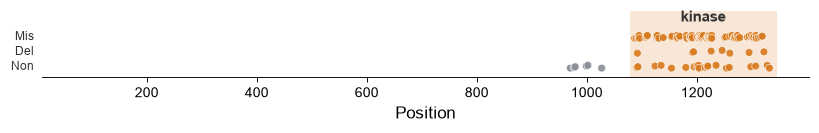

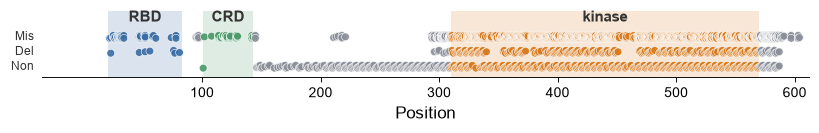

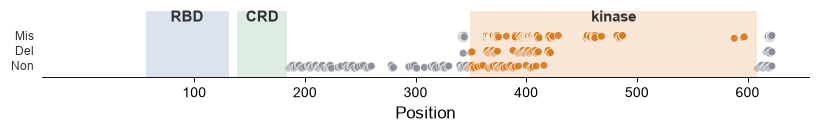

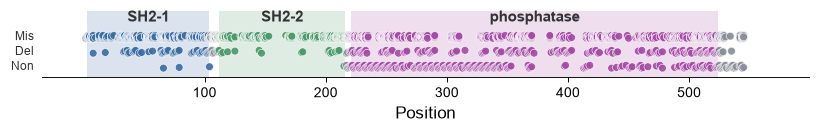

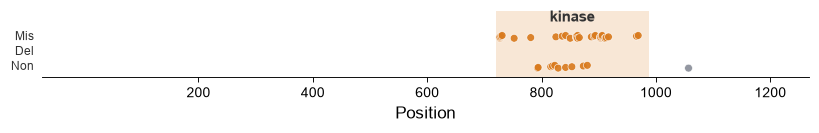

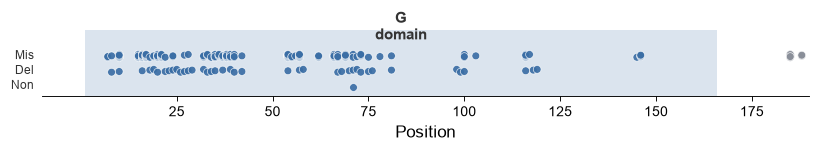

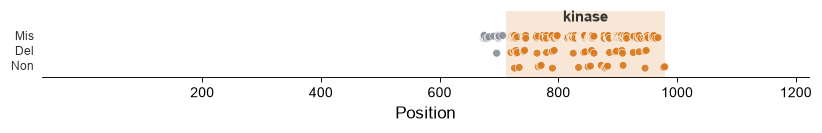

  3E HGFR   3DKC   58 DN positions  [canonical kinase pose] +ATP/MG -> 3e_structure_met.png
  3F ARAF   9AXM  324 DN positions  [canonical kinase pose] -> 3f_structure_araf.png
  S3E CRAF   8CPD   66 DN positions  [curated view] +CRAF protomer 2 spheres -> s3e_structure_craf.png
  S3C SHP2   2SHP  367 DN positions  [curated view] -> s3c_structure_shp2.png
  S3D ERBB2  3PP0   23 DN positions  [canonical kinase pose] -> s3d_structure_erbb2.png
  3G KRAS   1NVU   58 DN positions  [orient] +SOS1 spheres -> 3g_structure_sos1kras.png
  S3G EGFR   2GS6  106 DN positions  [canonical kinase pose] -> s3g_structure_egfr.png
  S3H SHP2   3TKZ  367 DN positions  [orient] -> s3h_structure_shp2_nsh2.png


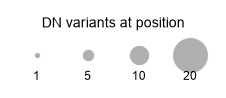

In [12]:
# ======================================================================
# Figures 3E-G, S3C-E, S3G — Structures — Configuration
# ======================================================================

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']
plt.rcParams['figure.facecolor'] = 'none'
plt.rcParams['axes.facecolor'] = 'none'
plt.rcParams['savefig.facecolor'] = 'none'

# Font sizes
FONT_SIZE_TITLE = 10
FONT_SIZE_LABEL = 9
FONT_SIZE_TICK = 8
FONT_SIZE_LEGEND = 8

# Line widths
LINE_WIDTH_AXES = 0.6
LINE_WIDTH_PLOT = 1.0


def plot_dn_positions(
    positions_by_type: Mapping[str, Sequence[int]],
    *,
    xlim: tuple[int, int],
    domains: Sequence[tuple[str, int, int, str]] = (),
    text_only_domains: Sequence[tuple[str, int]] = (),
    row_types: Sequence[str] = ("missense", "deletion", "nonsense"),
    row_labels: Sequence[str] = ("Mis", "Del", "Non"),
    dot_size: float = 26.0,
    col_width: float = 0.32,
    domain_alpha: float = 0.18,
    default_color: str = "#8a8f99",
    figsize: tuple[float, float] = (7.5, 1.3),
    margins: Mapping[str, float] | None = None,
    xlabel: str = "Position",
    fs: Mapping[str, float] | None = None,
    left_pad_frac: float = 0.06,
) -> tuple[Figure, Axes]:
    """DN variants along the primary sequence, horizontal — one row per type.

    Port of ``render_protein_horizontal`` in
    ``scripts/plot_dn_position_distributions.py``: 7.5 x 1.3 in landscape,
    N-terminus on the left, three discrete rows (Mis on top, Del, Non) spaced
    ``col_width`` apart, domains as vertical shaded bands spanning all rows
    with bold labels above, row labels at the left, and a small y-jitter so
    variants at the same position do not completely overlap.

    Dots default to 26 pt^2 rather than the original 14 so they read at panel
    size; pass ``dot_size`` to change it.

    The axes are placed by ``subplots_adjust``, not ``tight_layout``, and the
    original saves **without** ``bbox_inches="tight"`` so every protein's panel
    comes out at identical dimensions and can be stacked. Use
    ``save_figure(..., tight=False)`` to preserve that.

    Args:
        positions_by_type: variant type -> residue positions carrying a DN.
        xlim: ``(first, last)`` residue of the profiled window. Trimming to the
            scanned region rather than the full protein keeps the density
            honest.
        domains: ``(name, start, end, colour)`` shaded bands.
        text_only_domains: ``(name, position)`` italic grey motif labels.
        dot_size: Scatter point area.
        margins: Overrides for ``subplots_adjust``; defaults to the locked
            ``left=0.06, right=0.99, top=0.78, bottom=0.32``.
        fs: Font-size overrides; keys ``domain``, ``motif``, ``row``,
            ``axis``, ``tick``.
        left_pad_frac: Fraction of the plotted span left as empty margin
            before ``pmin``. Default (0.06) matches the original; pass 0.0
            to have the axis start exactly at the first measured position.
            The row-type labels (Mis/Del/Non) are anchored in axes-fraction
            coordinates, not data coordinates, so they stay just left of the
            frame regardless of this value.
    """
    F = {"domain": 10, "motif": 9, "row": 8, "axis": 11, "tick": 9}
    F.update(fs or {})
    M = {"left": 0.06, "right": 0.99, "top": 0.78, "bottom": 0.32}
    M.update(margins or {})

    pmin, pmax = xlim
    span = max(pmax - pmin, 1)
    fig, ax = plt.subplots(figsize=figsize)

    n_rows = len(row_types)
    row_y = {t: (n_rows - 1 - i) * col_width for i, t in enumerate(row_types)}
    y_min = -col_width / 2
    y_max = (n_rows - 1) * col_width + col_width / 2
    label_y = y_max + 0.10

    def _colour_of(pos: int) -> str:
        for name, start, end, colour in domains:
            if start <= pos <= end:
                return colour
        return default_color

    for name, start, end, colour in domains:
        mid = (max(start, pmin) + min(end, pmax)) / 2
        if mid < pmin or mid > pmax:
            continue
        ax.axvspan(start, end, ymin=0.0, ymax=1.0, facecolor=colour,
                   alpha=domain_alpha, zorder=0)
        ax.text(mid, label_y, name.replace(" ", "\n"), ha="center",
                va="bottom", fontsize=F["domain"], color="#333333",
                fontweight="bold")
    for name, mid in text_only_domains:
        if pmin <= mid <= pmax:
            ax.text(mid, label_y, name.replace(" ", "\n"), ha="center",
                    va="bottom", fontsize=F["motif"], color="#888888",
                    style="italic")

    for t in row_types:
        pos = list(positions_by_type.get(t, []))
        if not pos:
            continue
        y = row_y[t]
        ys = [y + ((i % 5) - 2) * 0.015 for i in range(len(pos))]
        ax.scatter(pos, ys, s=dot_size, c=[_colour_of(p) for p in pos],
                   edgecolors="white", linewidths=0.4, alpha=0.92, zorder=3)

    # Anchored in axes-fraction x (data y) so the row labels stay just left
    # of the frame regardless of left_pad_frac, including 0.
    from matplotlib.transforms import blended_transform_factory
    row_label_trans = blended_transform_factory(ax.transAxes, ax.transData)
    for t, lab in zip(row_types, row_labels):
        ax.text(-0.01, row_y[t], lab, ha="right", va="center",
                fontsize=F["row"], color="#333333", transform=row_label_trans,
                clip_on=False)

    ax.set_xlim(pmin - left_pad_frac * span, pmax + 0.01 * span)
    ax.set_ylim(y_min - 0.05, y_max + 0.40)
    ax.set_yticks([])
    ax.set_xlabel(xlabel, fontsize=F["axis"])
    ax.set_xticks([tk for tk in ax.get_xticks() if pmin <= tk <= pmax])
    for s in ("top", "right", "left"):
        ax.spines[s].set_visible(False)
    ax.tick_params(axis="x", labelsize=F["tick"])
    fig.subplots_adjust(**M)
    return fig, ax


def plot_structure(
    out_stem: str | Path,
    *,
    structure: str,
    query_chains: Sequence[str] = ("A",),
    sphere_counts: Mapping[int, float] | None = None,
    residue_values: Mapping[int, float] | None = None,
    sphere_color: tuple[float, float, float] | str = (0.75, 0.16, 0.16),
    cmap: str = "Reds",
    vmin: float = 0.0,
    vmax: float = 1.0,
    nodata_color: str = "gray35",
    radius_range: tuple[float, float] = (0.6, 3.5),
    count_range: tuple[float, float] = (1.0, 20.0),
    partners: Sequence[tuple[str, str, str] | Mapping] = (),
    ligands: Sequence[str] = (),
    graft: Mapping | None = None,
    ligand_color: str = "yellow",
    ion_vdw: float = 0.9,
    cartoon_color: str = STRUCT_CARTOON_COLOR,
    view: Sequence[float] | None = None,
    align_to: str | None = None,
    align_chain: str = "A",
    align_resi: tuple[int, int] | None = None,
    align_rotations: Sequence[tuple[str, float]] = (),
    px_per_angstrom: float = 14.0,
    pad_angstrom: float = 6.0,
    cartoon_pad_angstrom: float = 4.0,
    max_px: int = 3000,
    bg_color: str = "white",
    save_pse: bool = True,
    run: bool = True,
    extra_commands: Sequence[str] = (),
) -> Path:
    """Render a structure with per-residue spheres and/or a colour ramp.

    The one structure renderer. It writes a ``.pml`` and then invokes PyMOL on
    it, so the exact commands stay inspectable and re-runnable outside the
    notebook.

    Two channels, independent and combinable:

    * ``sphere_counts`` -> C-alpha spheres whose VDW radius is a **linear,
      absolute** function of the count (``count_range`` mapped onto
      ``radius_range``, saturating above). Absolute rather than per-structure
      normalisation is what lets one legend serve every render.
    * ``residue_values`` -> the cartoon coloured by a value in
      ``[vmin, vmax]`` through ``cmap``, with unmeasured residues in
      ``nodata_color`` (mid-grey, so it is distinguishable from the white end
      of the ramp).

    **Constant scale, varying canvas.** For the sphere legend to be honest, a
    3.5 A sphere must occupy the same number of page pixels in every panel. The
    camera is therefore zoomed to fit the molecule and the image is then sized
    at ``px_per_angstrom`` pixels per Angstrom of molecular extent — so a large
    protein yields a physically larger image rather than being shrunk to a
    common frame. Panels will not all be the same dimensions, and will not
    match renders made with a fixed image size.

    Args:
        out_stem: Output path without extension; ``.pml``, ``.png`` and
            optionally ``.pse`` are written beside it.
        structure: ``"fetch:9AXM"`` for a PDB ID, else a path to a local file.
            Fetches use the asymmetric unit, which preserves the deposited
            chain IDs — the biological assembly renames them and silently
            produced a blank ARAF render once.
        partners: Either ``(chain, label, colour)`` or a mapping with those
            keys plus optional ``sphere_counts`` / ``sphere_color``. Shown as
            sticks for a short peptide, cartoon otherwise. Giving a partner its
            own spheres is how a two-chain panel shows DNs on both sides: each
            chain keeps its own cartoon colour and its own sphere colour, so
            which protein a sphere belongs to is unambiguous.
        ligands: Residue names to draw from the query chains, e.g.
            ``("ATP", "MG")``. Polyatomic ligands are drawn as sticks with
            carbons in ``ligand_color`` and other elements by element; single
            atoms (metals, halides) are drawn as small spheres in
            ``ligand_color``. Nothing is shown by default: a deposited ligand is
            loaded but invisible unless asked for, which is how MET's bound
            ATP went unrendered.
        graft: Borrow a chain from a SECOND structure and show it in this one's
            frame, for when the ligand-bound structure covers only part of the
            protein. Keys: ``structure``, ``align_resi`` (the residue range
            shared by both, used for the superposition), ``keep_chain``,
            ``label``, ``color``, and optional ``align_chain`` (default "A").
            The donor is superposed onto the query over ``align_resi``, then
            everything but ``keep_chain`` is discarded. Caveat worth stating in
            any caption: donor and query are different conformations, so a
            grafted ligand marks *where* a site is rather than reproducing that
            complex's geometry exactly.
        ligand_color: Carbon / ion colour for ``ligands``. Chosen to contrast
            with both the grey cartoon and the per-protein DN spheres.
        ion_vdw: Sphere radius for single-atom ligands. Deliberately distinct
            from ``radius_range`` so an ion is not misread as a DN sphere; the
            colour is the primary cue.
        view: 18-tuple from PyMOL's ``get_view``. Its **orientation and
            centring** are honoured exactly; its zoom is refit to the molecule
            so nothing is cropped, since the view's own field of view trims
            anything taller than it and enlarging the image at a fixed field of
            view would change the scale rather than reveal more. Without a view the camera is zoomed to fit and
            the canvas sized from the molecular extent; both routes land on the
            same scale, which is what makes one sphere legend valid throughout.
        align_to / align_chain / align_resi / align_rotations: Superpose onto
            an anchor so several proteins share a frame. The rotations are
            applied to the **anchor's atoms** before superposition — order
            matters, because ``cmd.rotate(axis, angle, selection)`` moves only
            that selection, so rotating afterwards would leave the subject
            behind.
        px_per_angstrom: Pixels per Angstrom. Constant across panels — this is
            what the shared sphere legend rests on.
        pad_angstrom: Clear space beyond the ink, in Angstroms.
        cartoon_pad_angstrom: Allowance for the cartoon ribbon, which is drawn
            around the backbone and so reaches past every atom centre. Added to
            ``pad_angstrom`` together with the largest sphere radius.
        max_px: Cap on either image dimension, to bound ray-trace time.
        run: Execute PyMOL. False writes the ``.pml`` only.

    Returns:
        Path to the written ``.pml``.
    """
    out_stem = Path(out_stem)
    out_stem.parent.mkdir(parents=True, exist_ok=True)
    pml = out_stem.with_suffix(".pml")
    obj = out_stem.name.upper().replace("-", "_").replace(".", "_")

    if str(structure).startswith("fetch:"):
        PYMOL_FETCH_CACHE.mkdir(parents=True, exist_ok=True)
        load = f"fetch {str(structure).split(':', 1)[1]}, {obj}, async=0"
    else:
        load = f"load {Path(structure).resolve()}, {obj}"

    q_sel = " or ".join(f"chain {c}" for c in query_chains)
    L = [f"# {out_stem.name}",
         f"set fetch_path, {PYMOL_FETCH_CACHE.resolve()}"]

    if align_to is not None:
        if str(align_to).startswith("fetch:"):
            L.append(f"fetch {str(align_to).split(':', 1)[1]}, _anchor_raw, async=0")
        else:
            L.append(f"load {Path(align_to).resolve()}, _anchor_raw")
        rng = f" and resi {align_resi[0]}-{align_resi[1]}" if align_resi else ""
        L += ["remove _anchor_raw and (solvent or hetatm)",
              f"create _pose_anchor, _anchor_raw and chain {align_chain} "
              f"and polymer{rng}",
              "delete _anchor_raw", "orient _pose_anchor"]
        for axis, angle in align_rotations:
            L.append(f"rotate {axis}, {angle}, _pose_anchor")

    L += [load, "remove solvent", "remove hydro", "hide everything",
          f"select query_sel, {obj} and ({q_sel})",
          "show cartoon, query_sel",
          f"color {cartoon_color}, query_sel"]

    if align_to is not None:
        # cealign gets within a few Angstrom; `super` refines it. cealign alone
        # leaves ~3 A RMSD, which visibly tilts the kinase.
        L += ["cealign _pose_anchor, query_sel",
              "super query_sel, _pose_anchor, cycles=5",
              "hide everything, _pose_anchor", "delete _pose_anchor"]

    if graft:
        g_src = str(graft["structure"])
        if g_src.startswith("fetch:"):
            L.append(f"fetch {g_src.split(':', 1)[1]}, _graft_raw, async=0")
        else:
            L.append(f"load {Path(g_src).resolve()}, _graft_raw")
        g_chain = graft.get("align_chain", "A")
        lo, hi = graft["align_resi"]
        L += ["remove _graft_raw and solvent",
              # Superpose the donor onto the query over the range they share, so
              # the borrowed chain lands in the query's frame. `align` returns
              # the transform; applying it to the whole donor object carries the
              # ligand along with the domain that was fitted.
              f"create _graft_ref, _graft_raw and chain {g_chain} and polymer "
              f"and resi {lo}-{hi}",
              f"align _graft_ref, {obj} and ({q_sel}) and resi {lo}-{hi}, "
              "cycles=5, object=_graft_aln",
              "python",
              "m = cmd.get_object_matrix('_graft_ref')",
              "cmd.transform_object('_graft_raw', m)",
              "python end",
              f"create graft_sel, _graft_raw and chain {graft['keep_chain']}",
              "delete _graft_ref", "delete _graft_aln", "delete _graft_raw",
              "hide everything, graft_sel",
              "show sticks, graft_sel",
              f"color {graft.get('color', 'yellow')}, graft_sel",
              "python",
              "from pymol import util",
              "util.cnc('graft_sel')",
              f"print('grafted {graft.get('label', 'ligand')}: %d atoms' % "
              "cmd.count_atoms('graft_sel'))",
              "python end"]

    partner_specs = []
    for i, rec in enumerate(partners):
        d = (dict(zip(("chain", "label", "color"), rec))
             if isinstance(rec, (tuple, list)) else dict(rec))
        safe = "".join(c if c.isalnum() or c in "._" else "_"
                       for c in str(d["label"]))
        d["sel"] = f"partner_{i}_{safe}"
        partner_specs.append(d)
        L += [f"select {d['sel']}, {obj} and chain {d['chain']}",
              f"color {d['color']}, {d['sel']}", "python",
              f"n_ca = cmd.count_atoms('{d['sel']} and name CA')",
              f"cmd.show('sticks' if n_ca <= 15 else 'cartoon', '{d['sel']}')",
              "python end"]

    if residue_values:
        cm, span = plt.get_cmap(cmap), (vmax - vmin) or 1.0
        L += [f"color {nodata_color}, query_sel",
              "set cartoon_smooth_loops, 0", "set cartoon_discrete_colors, 1"]
        by_colour: dict[tuple, list[int]] = {}
        for pos, val in residue_values.items():
            if val is None or not np.isfinite(val):
                continue
            rgb = tuple(round(c, 3) for c in
                        cm(min(max((val - vmin) / span, 0.0), 1.0))[:3])
            by_colour.setdefault(rgb, []).append(int(pos))
        for k, (rgb, positions) in enumerate(sorted(by_colour.items())):
            L += [f"set_color ramp_{k}, [{rgb[0]}, {rgb[1]}, {rgb[2]}]",
                  f"color ramp_{k}, {obj} and ({q_sel}) and resi "
                  + "+".join(str(x) for x in sorted(positions))]

    def _sphere_cmds(sel_expr: str, counts, colour, tag: str) -> list[str]:
        """Commands sizing and showing C-alpha spheres on one selection.

        Radius is a linear, ABSOLUTE function of the count — the same mapping
        for every selection in every panel — which is what the shared legend
        depends on. Counts at or above ``count_range[1]`` saturate rather than
        rescaling the panel.
        """
        c0, c1 = count_range
        r0, r1 = radius_range
        out: list[str] = []
        if isinstance(colour, str):
            name = colour
        else:
            name = f"sphere_col_{tag}"
            out.append(f"set_color {name}, [{colour[0]:.3f}, "
                       f"{colour[1]:.3f}, {colour[2]:.3f}]")
        by_radius: dict[float, list[int]] = {}
        for pos, n in counts.items():
            if n is None or not np.isfinite(n) or n < c0:
                continue
            frac = (min(float(n), c1) - c0) / max(c1 - c0, 1e-9)
            by_radius.setdefault(round(r0 + frac * (r1 - r0), 3),
                                 []).append(int(pos))
        for radius, positions in sorted(by_radius.items()):
            out.append(f"alter (({sel_expr}) and resi "
                       + "+".join(str(x) for x in sorted(positions))
                       + f" and name CA), vdw={radius:.3f}")
        allp = sorted(x for ps in by_radius.values() for x in ps)
        if allp:
            out += ["rebuild",
                    f"select dn_spheres_{tag}, ({sel_expr}) and resi "
                    + "+".join(str(x) for x in allp) + " and name CA",
                    f"show spheres, dn_spheres_{tag}",
                    f"color {name}, dn_spheres_{tag}",
                    "python",
                    f"print('spheres {tag}: %d of {len(allp)} positions present "
                    f"in this structure' % cmd.count_atoms('dn_spheres_{tag}'))",
                    "python end"]
        return out

    partner_sphere_specs = [d for d in partner_specs if d.get("sphere_counts")]
    if sphere_counts or partner_sphere_specs:
        # Shrink every atom first, once, so only the residues given a radius
        # below render as spheres.
        L += ["alter all, vdw=0.01", "rebuild"]
        if sphere_counts:
            L += _sphere_cmds(f"{obj} and ({q_sel})", sphere_counts,
                              sphere_color, "query")
        for i, d in enumerate(partner_sphere_specs):
            L += _sphere_cmds(f"{obj} and chain {d['chain']}",
                              d["sphere_counts"],
                              d.get("sphere_color", sphere_color), f"p{i}")

    if ligands:
        # After the sphere pass, because that sets vdw=0.01 on every atom to
        # keep unmarked residues from rendering as spheres — the ions need their
        # radius restored afterwards or they vanish.
        resn = "+".join(str(r).upper() for r in ligands)
        L += [f"select ligand_sel, {obj} and ({q_sel}) and resn {resn}",
              "python",
              "from pymol import util",
              "cmd.show('sticks', 'ligand_sel and not (elem MG+ZN+CA+MN+NA+K+CL+FE)')",
              "cmd.show('spheres', 'ligand_sel and elem MG+ZN+CA+MN+NA+K+CL+FE')",
              f"cmd.alter('ligand_sel and elem MG+ZN+CA+MN+NA+K+CL+FE', 'vdw={ion_vdw}')",
              "cmd.rebuild()",
              f"cmd.color('{ligand_color}', 'ligand_sel')",
              # Non-carbon atoms back to element colours, so the phosphates and
              # ribose of a nucleotide stay legible instead of a yellow blob.
              "util.cnc('ligand_sel and not (elem MG+ZN+CA+MN+NA+K+CL+FE)')",
              "print('ligand atoms shown: %d' % cmd.count_atoms('ligand_sel'))",
              "python end",
              "set stick_radius, 0.20"]

    L += [f"bg_color {bg_color}", "set ray_shadows, 0", "set antialias, 2",
          "set ray_opaque_background, 1", "set sphere_quality, 4",
          "set cartoon_fancy_helices, 1", "set depth_cue, 0",
          "set specular, 0.25", "set orthoscopic, on", *extra_commands]

    png = out_stem.with_suffix(".png").resolve()
    # Everything that carries a sphere must be inside the frame, not just the
    # query chain — otherwise a partner's DNs would be cropped.
    framed = " or ".join([f"{obj} and ({q_sel})"]
                         + [f"{obj} and chain {d['chain']}"
                            for d in partner_specs]
                         + (["ligand_sel"] if ligands else [])
                         + (["graft_sel"] if graft else []))
    L.append(f"select framed_sel, {framed}")

    # ONE sizing rule for both routes, so every panel lands on exactly
    # px_per_angstrom and the shared sphere legend is valid throughout.
    #
    # The canvas is SQUARE. PyMOL maps the field of view to the *smaller* pixel
    # dimension, so on a portrait canvas it governs width and on a landscape one
    # height; getting that backwards silently clips the other axis. On a square
    # canvas both readings coincide.
    #
    # The camera distance is then recomputed from the extent the molecule needs
    # about the view's own centre. With a fixed field of view the visible span is
    # 2 * distance * tan(fov / 2), so anything larger is trimmed, and enlarging
    # the image at a fixed field of view would rescale Angstroms-per-pixel rather
    # than reveal more.
    #
    # Padding covers the largest sphere radius and the cartoon ribbon as well as
    # pad_angstrom, because get_coords returns atom CENTRES and neither of those
    # has an atom at its outer edge.
    _fit = ["python",
            "import math",
            "v = list(cmd.get_view())",
            "fov = abs(v[17]) or 20.0",
            "R, org = v[0:9], v[12:15]",
            "P = cmd.get_coords('framed_sel')",
            "def _proj(k, off):",
            "    return [R[3 * k] * (q[0] - org[0]) + R[3 * k + 1] * (q[1] - org[1])"
            " + R[3 * k + 2] * (q[2] - org[2]) + off for q in P]",
            "xs, ys, zs = _proj(0, v[9]), _proj(1, v[10]), _proj(2, 0.0)",
            f"pad = {pad_angstrom} + {radius_range[1]} + {cartoon_pad_angstrom}",
            "half = lambda s: max(abs(min(s)), abs(max(s)))",
            "side = 2 * max(half(xs), half(ys)) + 2 * pad",
            "d = side / (2.0 * math.tan(math.radians(fov) / 2.0))",
            "v[11] = -d",
            "v[15] = max(1.0, d - half(zs) - pad)",
            "v[16] = d + half(zs) + pad",
            "cmd.set_view(v)",
            f"n = min(int(round(side * {px_per_angstrom})), {max_px})",
            "print('fit %.1f A square (pad %.1f) -> %d px (%.2f px/A)'"
            " % (side, pad, n, n / side))",
            f"cmd.png(r'{png}', width=n, height=n, dpi=300, ray=1)",
            "python end"]

    if view is not None:
        # A pinned view supplies the ORIENTATION and CENTRING; its zoom is
        # refit above so nothing is cropped.
        L += ["set_view (" + ", ".join(f"{v:.6f}" for v in view) + ")"] + _fit
    else:
        # No curated view: PyMOL's own principal-axes orientation, which is
        # reproducible but arbitrary. Same sizing rule from there.
        L += ["orient framed_sel"] + _fit

    if save_pse:
        L.append(f"save {out_stem.with_suffix('.pse').resolve()}")

    pml.write_text("\n".join(L) + "\n")
    if run:
        if not PYMOL_BIN.exists():
            raise FileNotFoundError(
                f"PyMOL not found at {PYMOL_BIN}. Set the PYMOL env var.")
        res = subprocess.run([str(PYMOL_BIN), "-cq", str(pml)],
                             capture_output=True, text=True, timeout=900)
        if res.returncode != 0:
            raise RuntimeError(f"PyMOL failed on {pml.name}:\n"
                               f"{res.stdout[-800:]}\n{res.stderr[-800:]}")
    return pml


def plot_sphere_legend(
    counts: Sequence[int] = (1, 5, 10, 20),
    *,
    radius_range: tuple[float, float] = (0.6, 3.5),
    count_range: tuple[float, float] = (1.0, 20.0),
    px_per_angstrom: float = 14.0,
    color: str = "#b0b0b0",
    figsize: tuple[float, float] | None = None,
    label: str = "DN variants\nat position",
    fs: Mapping[str, float] | None = None,
    horizontal: bool = False,
) -> tuple[Figure, Axes]:
    """Sphere-size key for :func:`plot_structure`.

    One legend serves every render because the radius map is absolute and the
    structures are drawn at a constant pixels-per-Angstrom. Drawn in **grey**,
    since the spheres are coloured per protein and this key is about size only.

    Marker areas are computed from the same Angstrom radii and the same
    ``px_per_angstrom`` the renders use, so a circle here is the on-page size
    of that sphere in the panels.

    Args:
        horizontal: Lay the spheres out in a single row (count label under
            each sphere, title centred above) instead of the default stacked
            column (count label beside each sphere, title above-left). The
            row layout is the compact option for a page where the legend has
            to be squeezed into little vertical space.
    """
    F = {"label": 9, "tick": 8}
    F.update(fs or {})
    c0, c1 = count_range
    r0, r1 = radius_range

    def _diam_pt(n):
        frac = (min(float(n), c1) - c0) / max(c1 - c0, 1e-9)
        r_a = r0 + frac * (r1 - r0)                         # Angstrom
        return 2 * r_a * px_per_angstrom * 72.0 / 300.0     # px -> pt at 300 dpi

    if horizontal:
        fig, ax = plt.subplots(figsize=figsize or (2.4, 0.9))
        n_items = len(counts)
        xs = [(i + 0.5) / n_items for i in range(n_items)]
        for x, n in zip(xs, counts):
            d_pt = _diam_pt(n)
            ax.scatter([x], [0.42], s=d_pt ** 2, facecolor=color,
                       edgecolor="white", linewidth=0.6)
            ax.text(x, 0.06, f"{n}", va="bottom", ha="center", fontsize=F["tick"])
        ax.text(0.5, 0.92, label.replace("\n", " "), va="top", ha="center",
                fontsize=F["label"])
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)
    else:
        fig, ax = plt.subplots(figsize=figsize or (1.5, 2.0))
        for i, n in enumerate(counts):
            d_pt = _diam_pt(n)
            y = 0.88 - i * 0.18
            ax.scatter([0.28], [y], s=d_pt ** 2, facecolor=color,
                       edgecolor="white", linewidth=0.6)
            ax.text(0.62, y, f"{n}", va="center", ha="left", fontsize=F["tick"])
        ax.text(0.0, 0.99, label, va="bottom", ha="left", fontsize=F["label"])
        ax.set_xlim(0, 1)
        ax.set_ylim(0.88 - len(counts) * 0.18, 1.10)
    ax.set_axis_off()
    return fig, ax


# --- Generate plot ---

EXEMPLARS = [
    ("met",   "3E", "3DKC", "active site, ATP-bound"),
    ("araf",  "3F", "9AXM", "burial"),
    ("craf",  "S3E", "8CPD", "kinase-domain dimer"),
    ("shp2",  "S3C", "2SHP", "N-SH2 pY pocket"),
    ("erbb2", "S3D", "3PP0", "burial, no interface signal"),
    ("sos1kras", "3G", "1NVU", "SOS1 catalytic + allosteric RAS sites"),
    # EGFR completes the RTK set: with MET and ERBB2 it gives three kinase
    # domains in the same canonical pose, so the DN distribution can be
    # compared fold-position by fold-position across receptors.
    ("egfr",  "S3G", "2GS6", "burial, kinase domain"),
    # Paired with S3C: the same protein's enriched interface, in a conformation
    # that can hold the ligand.
    ("shp2_nsh2", "S3H", "3TKZ", "N-SH2 with pY peptide"),
]
# Panel key -> which protein's DN calls it shows. Every key is a protein name
# except where one protein gets two panels.
PANEL_PROTEIN = {"shp2_nsh2": "shp2", "sos1kras": "kras"}
# Panels that exist ONLY as a structure, with no position track of their own.
COMPANION_PANELS = {"shp2_nsh2"}
# Panel key -> which protein's DN calls it shows, for keys that are not
# themselves protein names (a protein with a second structure panel).
STRUCT_PROTEIN = {"shp2_nsh2": "shp2"}
# Curated domain bounds, with the shading colour per domain.
DOMAINS = {
    "met":   [("kinase", 1078, 1345, "#d97b1f")],
    "araf":  [("RBD", 21, 83, "#3b6ea5"), ("CRD", 101, 143, "#4c9a6a"),
              ("kinase", 310, 570, "#d97b1f")],
    "craf":  [("RBD", 56, 131, "#3b6ea5"), ("CRD", 139, 184, "#4c9a6a"),
              ("kinase", 349, 609, "#d97b1f")],
    "shp2":  [("SH2-1", 3, 104, "#3b6ea5"), ("SH2-2", 112, 216, "#4c9a6a"),
              ("phosphatase", 221, 524, "#a64ca6")],
    "erbb2": [("kinase", 720, 987, "#d97b1f")],
    "egfr":  [("kinase", 712, 979, "#d97b1f")],
    "kras":  [("G domain", 1, 166, "#3b6ea5")],
}

# All three variant types, one row each, so the nonsense inversion seen in 3C
# is visible position by position.
dn_all = dn_pool[dn_pool.is_dn]
per_pos = (dn_all.groupby(["protein", "Position", "Mutation Type"]).size()
           .rename("n_dn").reset_index())
per_pos.to_csv(FIG / "4e_dn_per_position.tsv", sep="\t", index=False)

for key, panel, pdb, mech in EXEMPLARS:
    prot = PANEL_PROTEIN.get(key, key)
    sub = dn_all[dn_all.protein == prot]
    if sub.empty:
        print(f"  {prot}: no DN variants, skipped")
        continue
    by_type = {mt: sorted(g.Position.dropna().astype(int))
               for mt, g in sub.groupby("Mutation Type")}
    # Trim the axis to the scanned window rather than the full protein, so
    # density is not diluted by unprofiled regions.
    scanned = pd.to_numeric(
        Replicate_scores.loc[Replicate_scores.protein == prot, "Position"], errors="coerce").dropna()
    if key in COMPANION_PANELS:
        continue          # structure-only companion panel; no separate track
    # 3E (MET) starts its x-axis exactly at the first measured position --
    # every other panel keeps the default small left margin.
    fig, _ = plot_dn_positions(
        by_type, xlim=(int(scanned.min()), int(scanned.max())),
        domains=DOMAINS.get(prot, ()), dot_size=26.0,
        left_pad_frac=(0.0 if key == "met" else 0.06))
    # No bbox_inches="tight": every protein's panel must come out at the same
    # dimensions so the six can be stacked.
    save_figure(fig, FIG / f"{panel.lower()}_dn_positions_{prot}",
                      tight=False)
    plt.show()

# ---- structures, rendered here so they come from this notebook's DN calls --
# Chain assignments are the verified canonical poses
# (scripts/paint_dn_counts_pdb_structures.py). Sphere radius is an absolute
# function of the per-position DN count, identical across every render, which
# is what makes the single legend below valid for all of them.
# ---- canonical kinase-domain pose, hard-coded ---------------------------
# The Modi & Dunbrack 2019 Fig 1 view
# and saved to output/hsp90/.../kinase_fold_reference_view.txt. Pinned here as
# a literal so this notebook does not depend on that file surviving.
#
# Recipe: load 1GAG (insulin receptor kinase) as the anchor, trim to the
# kinase domain (chain A, 995-1283, N-terminal tail removed so it does not
# dominate the view), orient, then apply the four rotations to the ANCHOR'S
# ATOMS. Each subject is then cealign'ed + super'ed onto the rotated anchor,
# which physically moves it into the same frame. The rotations must precede
# the alignment: cmd.rotate(axis, angle, selection) moves only that
# selection, so rotating afterwards would leave every subject behind.
KINASE_FOLD_VIEW = (
    0.4060613811016083, -0.6507185101509094, 0.6416226029396057,
    0.3824107050895691, -0.5166869163513184, -0.7660265564918518,
    0.8299856781959534, 0.5564171671867371, 0.03903511166572571,
    0.0, 0.0, -170.91629028320312,
    -22.87476348876953, 38.59135818481445, 11.818153381347656,
    134.751708984375, 207.08087158203125, -20.0,
)
KINASE_POSE = dict(
    align_to=str(PROJECT_ROOT / "data" / "structures" / "1GAG.pdb"),
    align_chain="A", align_resi=(995, 1283),
    align_rotations=[("z", 90), ("x", 180), ("y", 180), ("y", -35)],
    view=KINASE_FOLD_VIEW,
)

# Views for the three non-kinase panels, chosen by hand in PyMOL (Sriram,
# 2026-08-03) and pinned as literal `get_view` tuples. The canonical kinase
# pose is only meaningful for a kinase fold: superposing a phosphatase, a small
# GTPase or a side-to-side dimer onto it would hide exactly what these panels
# exist to show, so each gets its own curated orientation instead.
#
# A pinned view also fixes the zoom, so the canvas is sized from the view's own
# camera distance rather than from a zoom-to-fit — see `plot_structure`. Both
# routes give the same Angstroms-per-pixel, so the one sphere legend stays
# valid across all seven structures.
CURATED_VIEWS = {
    # Autoinhibited SHP2: N-SH2 wedged into the phosphatase active site.
    "shp2": (0.284320831, -0.620489001, 0.730852723,
             0.772422433, -0.303307921, -0.558001578,
             0.567910075, 0.723179936, 0.393047184,
             0.000004157, -0.000051193, -179.372375488,
             18.156187057, -38.178714752, 40.519454956,
             126.141891479, 234.440658569, 20.0),
    # The ternary SOS1:RAS:RAS complex (1XD2), posed to show both RAS sites at
    # once: the catalytic CDC25 face and the distal allosteric REM face.
    "sos1kras": (0.377096891, 0.063449182, 0.923998535,
                 -0.230740711, 0.972631216, 0.027381096,
                 -0.896970034, -0.223527417, 0.381417215,
                 0.000000000, 0.000000000, -422.692687988,
                 21.653751373, 33.263061523, 50.121189117,
                 377.761657715, 467.623718262, 20.0),
    # KRAS-SOS1 on 6EPL. Retained for reference only: S3E now uses the ternary
    # 1XD2 complex, whose coordinates this view does not apply to.
    "kras_6epl": (0.145116702, -0.051358543, 0.988080680,
             0.495100737, -0.860859454, -0.117460005,
             0.856631517, 0.506244361, -0.099497758,
             0.000265162, -0.000084609, -196.457183838,
             175.049407959, 118.151290894, 253.175033569,
             161.665451050, 231.206192017, 20.0),
    # CRAF: the side-to-side kinase-domain dimer interface.
    "craf": (-0.438842148, -0.898536563, 0.007117328,
             0.897004843, -0.437598526, 0.062360406,
             -0.052918579, 0.033749510, 0.998028338,
             -0.000197858, 0.000002537, -166.853149414,
             93.667900085, 94.227424622, 108.460540771,
             104.322967529, 229.387283325, 20.0),
}

# Second-chain palette. Where a panel shows two chains that BOTH carry DNs, the
# two must be distinguishable twice over: different cartoon colour and
# different sphere colour, so a sphere is never ambiguous as to which protein
# it sits on.
SECOND_CHAIN_CARTOON = "wheat"          # tan, against the grey80 primary
# Partner label -> which protein's DN calls its spheres come from.
PARTNER_PROTEIN = {"SOS1": "sos1", "CRAF protomer 2": "craf"}
SPHERE_GREEN = (0.20, 0.65, 0.25)
SPHERE_ORANGE = (0.95, 0.55, 0.10)

CONTROLS = (PROJECT_ROOT / "data" / "inputs"
            / "annotations" / "pdb_controls")
# Every kinase-domain panel carries KINASE_POSE, so they render in one frame
# and are directly comparable. SHP2 is a phosphatase and KRAS a small GTPase —
# superposing either on a kinase fold would be meaningless, so they keep their
# own orientation and are not compared to the kinases by eye.
STRUCTS = {
    # 3DKC is the MET kinase domain with ATP and Mg2+ bound. The ligand is
    # drawn because this is the active-site exemplar: it shows the DN spheres
    # sitting around the nucleotide they occlude, rather than around an empty
    # cleft. 18 of the 47 annotated MET active-site residues lie within 5 A of
    # the ATP, and the closest contact is 2.0 A.
    "met":   dict(structure="fetch:3DKC", query_chains=("A",),
                  ligands=("ATP", "MG"), **KINASE_POSE),
    "araf":  dict(structure="fetch:9AXM", query_chains=("B",), **KINASE_POSE),
    # The CRAF dimer is deliberately NOT in the canonical kinase pose: that
    # view is chosen to show one kinase fold, and it hides the side-to-side
    # dimer interface which is the whole point of this panel. `orient` on the
    # two protomers together presents the interface instead.
    # Homodimer: chains A and B are both CRAF kinase domain (341-626), so the
    # same per-position DN counts apply to both halves. The second protomer is
    # tan with orange spheres against the primary's grey cartoon and CRAF-blue
    # spheres, so the dimer interface can be read as two distinct surfaces.
    "craf":  dict(structure=str(CONTROLS / "P04049_P04049_8CPD_AB.pdb"),
                  query_chains=("A",), view=CURATED_VIEWS["craf"],
                  partners=(dict(chain="B", label="CRAF protomer 2",
                                 color=SECOND_CHAIN_CARTOON,
                                 sphere_color=SPHERE_ORANGE),)),
    "erbb2": dict(structure="fetch:3PP0", query_chains=("A",), **KINASE_POSE),
    # 2GS6 chain A is the canonical EGFR kinase-domain monomer pose
    # (scripts/paint_dn_counts_pdb_structures.py).
    "egfr":  dict(structure="fetch:2GS6", query_chains=("A",), **KINASE_POSE),
    # SHP2 gets TWO panels, because one structure cannot carry both facts.
    #
    # S3C is the autoinhibited full-length enzyme, 2SHP, with every DN position:
    # the DN population is spread over the whole protein, more than half of it
    # phosphatase-domain and mostly buried.
    #
    # S3H is the ligand-bound N-SH2: 3TKZ, "SHP-2 N-SH2 domain in a 1:2 complex
    # with RVIpYFVPLNR" — the very complex whose surface carries the interface
    # odds ratio in S3A, alone or pooled with 3TL0's RLNpYAQLWHR. It
    # covers only residues 4-103, so it displays under a quarter of SHP2's DNs,
    # but it is the only way to show the peptide in a conformation that can
    # actually bind it: in 2SHP the N-SH2 pY cleft is closed against the
    # phosphatase active site, so a peptide placed there would depict a state
    # the structure is not in.
    #
    # The pair is the argument: this interface explains a small fraction of
    # SHP2's DNs yet is strongly enriched, and the enrichment is specific to
    # N-SH2 -- the equivalent C-SH2 pocket is DN-depleted.
    "shp2":  dict(structure="fetch:2SHP", query_chains=("A",),
                  view=CURATED_VIEWS["shp2"]),
    "shp2_nsh2": dict(protein="shp2", structure="fetch:3TKZ",
                      query_chains=("A",),
                      partners=(dict(chain="P", label="RVIpYFVPLNR peptide",
                                     color="yellow"),)),
    # 1XD2 is the TERNARY Ras:SOS:Ras-GDP complex: chains A and B are the two
    # RAS copies and chain C is SOS1 (566-1046). The ternary form is the point —
    # SOS1 engages RAS at two separate sites, the catalytic (CDC25) face and the
    # distal allosteric (REM) face, and only a structure carrying both can show
    # DNs sitting on each. A binary complex would leave the allosteric DNs
    # looking like they are simply "far from the interface".
    #
    # Both RAS copies take the SAME cartoon and sphere colour: they are far
    # apart here, so unlike the CRAF dimer there is nothing to disambiguate, and
    # colouring them alike says they are the same protein. SOS1 keeps the tan
    # cartoon with green spheres, RAS the default cartoon with orange spheres —
    # so a sphere's colour still names which protein's DN it is.
    #
    # 1XD2 is HRAS; our DN calls are KRAS. The two G domains are identical over
    # residues 1-86 and ~90% identical to 166, so position-wise transfer is safe
    # in the range the structure covers. KRAS positions beyond 166 (the HVR) are
    # absent from the structure and simply do not render — the sphere count
    # printed below reports how many landed.
    # 1NVU (Sondermann et al. 2004): the ternary Ras:SOS1:Ras complex with
    # clean single-letter chain IDs -- Q and R are the two RAS copies
    # (allosteric activator + catalytic substrate, both G-domain 1-166) and S
    # is SOS1's catalytic region (566-1046), the same construct/numbering as
    # the old 1XD2 view. No pinned view here (1XD2's CURATED_VIEWS entry does
    # not apply to 1NVU's coordinate frame): the default zoom-to-fit/orient
    # gives a clear ternary-complex pose.
    "sos1kras": dict(protein="kras", structure="fetch:1NVU",
                  query_chains=("Q", "R"),
                  sphere_color=SPHERE_ORANGE,
                  partners=(dict(chain="S", label="SOS1",
                                 color=SECOND_CHAIN_CARTOON,
                                 sphere_color=SPHERE_GREEN),)),
}

# Ray-traced renders cost roughly a minute each at publication size. Set
# False to skip them on a quick re-run; the .pml files are always rewritten
# so the renders can be reproduced outside the notebook.
RENDER_STRUCTURES = True

pos_counts = (md_dn.groupby(["protein", "Position"]).size()
              .rename("n_dn").reset_index())

for key, panel, pdb, mech in EXEMPLARS:
    prot = PANEL_PROTEIN.get(key, key)
    spec = STRUCTS.get(key)
    if spec is None:
        continue
    # Derive the reported PDB from the structure actually loaded, and check it
    # against the label in EXEMPLARS. The two were allowed to drift apart once
    # (MET was labelled 5HNI while 3DKC was rendered), which is the kind of
    # error that survives into a caption.
    src = str(spec["structure"])
    loaded = (src.split(":", 1)[1].upper() if src.startswith("fetch:")
              else Path(src).stem.split("_")[2])
    assert loaded == pdb, f"{prot}: EXEMPLARS says {pdb}, STRUCTS loads {loaded}"
    counts = (pos_counts[pos_counts.protein == prot]
              .set_index("Position")["n_dn"].to_dict())
    # Partner chains that carry DNs get their counts filled in here: the CRAF
    # protomer repeats the same protein's counts (homodimer), while SOS1 in the
    # KRAS panel brings its own.
    spec = {**spec, "partners": tuple(
        {**d, "sphere_counts": (
            counts if d["label"].startswith(protein_label(prot))
            else pos_counts[pos_counts.protein == PARTNER_PROTEIN[d["label"]]]
                 .set_index("Position")["n_dn"].to_dict())}
        if "sphere_color" in d else d
        for d in spec.get("partners", ()))}
    spec = {k: v for k, v in spec.items() if k != "protein"}
    stem = FIG / f"{panel.lower()}_structure_{key}"
    # Spheres take the protein's own colour, held constant across every
    # structure it appears in.
    # Spheres take the protein's own colour unless the panel overrides it —
    # which it does where two chains both carry DNs and the pair has to be
    # told apart by colour.
    plot_structure(
        stem, sphere_counts=counts, run=RENDER_STRUCTURES,
        sphere_color=spec.pop("sphere_color",
                              PROTEIN_SPHERE_COLOR[prot]), **spec)
    posed = ("canonical kinase pose" if spec.get("view") is KINASE_FOLD_VIEW
             else "curated view" if spec.get("view") else "orient")
    extra = "".join(f" +{d['label']} spheres" for d in spec.get("partners", ())
                    if d.get("sphere_counts"))
    print(f"  {panel} {protein_label(prot):6s} {loaded}  "
          f"{len(counts):3d} DN positions  [{posed}]{extra}"
          + (f" +{'/'.join(spec['ligands'])}" if spec.get("ligands") else "")
          + f" -> {stem.name}.png")

# One legend for every structure above: grey spheres, because the colour
# varies by protein and the key is about size alone.
fig, _ = plot_sphere_legend(horizontal=True)
save_figure(fig, FIG / "4e_sphere_legend")
plt.show()


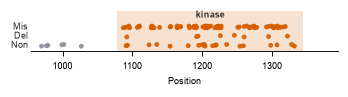

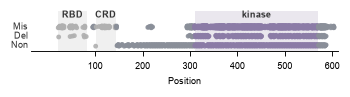

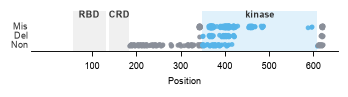

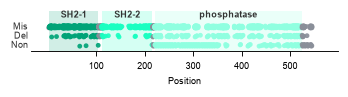

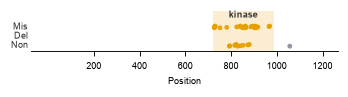

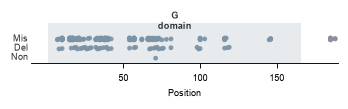

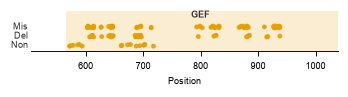

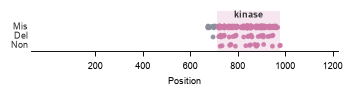

  3E HGFR   3DKC   58 DN positions  [canonical kinase pose] +ATP/MG -> 3e_structure_met.png
  3F ARAF   9AXM  324 DN positions  [canonical kinase pose] -> 3f_structure_araf.png
  S3E CRAF   8CPD   66 DN positions  [curated view] +CRAF protomer 2 spheres -> s3e_structure_craf.png
  S3C SHP2   2SHP  367 DN positions  [curated view] -> s3c_structure_shp2.png
  S3D ERBB2  3PP0   23 DN positions  [canonical kinase pose] -> s3d_structure_erbb2.png
  3G KRAS   1NVU   58 DN positions  [orient] +SOS1 spheres -> 3g_structure_sos1kras.png
  S3G EGFR   2GS6  106 DN positions  [canonical kinase pose] -> s3g_structure_egfr.png
  S3H SHP2   3TKZ  367 DN positions  [orient] -> s3h_structure_shp2_nsh2.png


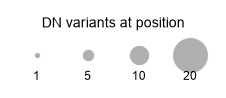

In [19]:
# ======================================================================
# Figures 3E-G, S3C-E, S3G — Structures — Configuration
# ======================================================================

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']
plt.rcParams['figure.facecolor'] = 'none'
plt.rcParams['axes.facecolor'] = 'none'
plt.rcParams['savefig.facecolor'] = 'none'

# Font sizes
FONT_SIZE_TITLE = 10
FONT_SIZE_LABEL = 9
FONT_SIZE_TICK = 8
FONT_SIZE_LEGEND = 8

# Line widths
LINE_WIDTH_AXES = 0.6
LINE_WIDTH_PLOT = 1.0

# ----------------------------------------------------------------------
# Per-protein colour key — single source of truth for this cell.
#
# ONE colour per protein. Used identically for:
#   1. DN spheres in the structure renders
#   2. Cartoon (backbone) colour in the structure renders
#   3. The matched domain band in the strip plots (via MATCHED_STRUCTURE_DOMAIN)
#
# Unmatched domains in the strip plots are grey (DOMAIN_GREY, below).
#
# To change a protein's colour everywhere, edit its single entry here.
PROTEIN_COLOR = {
    "met":   "#D55E00",  # vermillion  (swapped with ERBB2)
    "araf":  "#8B7BA6",  # grey-purple
    "craf":  "#56B4E9",  # sky blue  (chain A / strip-plot kinase domain)
    "shp2":  "#009E73",  # bluish green
    "erbb2": "#E69F00",  # orange  (swapped with MET)
    "egfr":  "#CC79A7",  # reddish purple
    "kras":  "#7C93A6",  # grey-blue  (swapped with SOS1)
    "sos1":  "#E69F00",  # orange  (swapped with KRAS)
}
# CRAF homodimer: two distinct chain colours so the dimer interface reads
# as two surfaces. Chain A uses PROTEIN_COLOR["craf"] above; chain B gets
# its own colour below. The strip plot's kinase domain uses chain A's colour.
CRAF_CHAIN_B_COLOR = "#F4A460"  # sandy brown — warm against chain A's cool blue

import colorsys
import matplotlib.colors as mcolors


def domain_shades(base_color, n: int, *, lightness_range=(0.32, 0.78)):
    """Return `n` colours that share `base_color`'s hue and saturation but
    differ in lightness, evenly spaced across `lightness_range` (dark to
    light).

    Used to colour a protein's individual domains in the strip plots when
    the protein is NOT in MATCHED_STRUCTURE_DOMAIN (i.e. no specific domain
    needs to match a structure panel). `n == 1` returns the base colour
    itself (no shading needed for a single-domain protein).
    """
    r, g, b = mcolors.to_rgb(base_color)
    h, l, s = colorsys.rgb_to_hls(r, g, b)
    if n <= 1:
        return [mcolors.to_hex((r, g, b))]
    lo, hi = lightness_range
    ls = [lo + (hi - lo) * i / (n - 1) for i in range(n)]
    return [mcolors.to_hex(colorsys.hls_to_rgb(h, ll, s)) for ll in ls]


def plot_dn_positions(
    positions_by_type: Mapping[str, Sequence[int]],
    *,
    xlim: tuple[int, int],
    domains: Sequence[tuple[str, int, int, str]] = (),
    text_only_domains: Sequence[tuple[str, int]] = (),
    row_types: Sequence[str] = ("missense", "deletion", "nonsense"),
    row_labels: Sequence[str] = ("Mis", "Del", "Non"),
    dot_size: float = 26.0,
    col_width: float = 0.32,
    domain_alpha: float = 0.18,
    default_color: str = "#8a8f99",
    figsize: tuple[float, float] = (3.0, 0.8),
    margins: Mapping[str, float] | None = None,
    xlabel: str = "Position",
    fs: Mapping[str, float] | None = None,
    left_pad_frac: float = 0.06,
) -> tuple[Figure, Axes]:
    """DN variants along the primary sequence, horizontal — one row per type.

    Port of ``render_protein_horizontal`` in
    ``scripts/plot_dn_position_distributions.py``: 7.5 x 1.3 in landscape,
    N-terminus on the left, three discrete rows (Mis on top, Del, Non) spaced
    ``col_width`` apart, domains as vertical shaded bands spanning all rows
    with bold labels above, row labels at the left, and a small y-jitter so
    variants at the same position do not completely overlap.

    Dots default to 26 pt^2 rather than the original 14 so they read at panel
    size; pass ``dot_size`` to change it.

    The axes are placed by ``subplots_adjust``, not ``tight_layout``, and the
    original saves **without** ``bbox_inches="tight"`` so every protein's panel
    comes out at identical dimensions and can be stacked. Use
    ``save_figure(..., tight=False)`` to preserve that.

    Args:
        positions_by_type: variant type -> residue positions carrying a DN.
        xlim: ``(first, last)`` residue of the profiled window. Trimming to the
            scanned region rather than the full protein keeps the density
            honest.
        domains: ``(name, start, end, colour)`` shaded bands. Pass
            ``PROTEIN_COLOR[<protein>]`` as the colour for every domain of a
            given protein so the strip plot's shading matches that protein's
            structure-panel cartoon colour.
        text_only_domains: ``(name, position)`` italic grey motif labels.
        dot_size: Scatter point area.
        margins: Overrides for ``subplots_adjust``; defaults to the locked
            ``left=0.06, right=0.99, top=0.78, bottom=0.32``.
        fs: Font-size overrides; keys ``domain``, ``motif``, ``row``,
            ``axis``, ``tick``.
        left_pad_frac: Fraction of the plotted span left as empty margin
            before ``pmin``. Default (0.06) matches the original; pass 0.0
            to have the axis start exactly at the first measured position.
            The row-type labels (Mis/Del/Non) are anchored in axes-fraction
            coordinates, not data coordinates, so they stay just left of the
            frame regardless of this value.
    """
    F = {"domain": 6, "motif": 6, "row": 6, "axis": 6, "tick": 6}
    F.update(fs or {})
    M = {"left": 0.06, "right": 0.99, "top": 0.78, "bottom": 0.32}
    M.update(margins or {})

    pmin, pmax = xlim
    span = max(pmax - pmin, 1)
    fig, ax = plt.subplots(figsize=figsize)

    n_rows = len(row_types)
    row_y = {t: (n_rows - 1 - i) * col_width for i, t in enumerate(row_types)}
    y_min = -col_width / 2
    y_max = (n_rows - 1) * col_width + col_width / 2
    label_y = y_max + 0.10

    def _colour_of(pos: int) -> str:
        for name, start, end, colour in domains:
            if start <= pos <= end:
                return colour
        return default_color

    for name, start, end, colour in domains:
        mid = (max(start, pmin) + min(end, pmax)) / 2
        if mid < pmin or mid > pmax:
            continue
        ax.axvspan(start, end, ymin=0.0, ymax=1.0, facecolor=colour,
                   alpha=domain_alpha, zorder=0)
        ax.text(mid, label_y, name.replace(" ", "\n"), ha="center",
                va="bottom", fontsize=F["domain"], color="#333333",
                fontweight="bold")
    for name, mid in text_only_domains:
        if pmin <= mid <= pmax:
            ax.text(mid, label_y, name.replace(" ", "\n"), ha="center",
                    va="bottom", fontsize=F["motif"], color="#888888",
                    style="italic")

    for t in row_types:
        pos = list(positions_by_type.get(t, []))
        if not pos:
            continue
        y = row_y[t]
        ys = [y + ((i % 5) - 2) * 0.015 for i in range(len(pos))]
        ax.scatter(pos, ys, s=dot_size, c=[_colour_of(p) for p in pos],
                   edgecolors="none", linewidths=0, alpha=0.92, zorder=3)

    # Anchored in axes-fraction x (data y) so the row labels stay just left
    # of the frame regardless of left_pad_frac, including 0.
    from matplotlib.transforms import blended_transform_factory
    row_label_trans = blended_transform_factory(ax.transAxes, ax.transData)
    for t, lab in zip(row_types, row_labels):
        ax.text(-0.01, row_y[t], lab, ha="right", va="center",
                fontsize=F["row"], color="#333333", transform=row_label_trans,
                clip_on=False)

    ax.set_xlim(pmin - left_pad_frac * span, pmax + 0.01 * span)
    ax.set_ylim(y_min - 0.05, y_max + 0.40)
    ax.set_yticks([])
    ax.set_xlabel(xlabel, fontsize=F["axis"])
    ax.set_xticks([tk for tk in ax.get_xticks() if pmin <= tk <= pmax])
    for s in ("top", "right", "left"):
        ax.spines[s].set_visible(False)
    ax.tick_params(axis="x", labelsize=F["tick"])
    fig.subplots_adjust(**M)
    return fig, ax


def plot_structure(
    out_stem: str | Path,
    *,
    structure: str,
    query_chains: Sequence[str] = ("A",),
    sphere_counts: Mapping[int, float] | None = None,
    residue_values: Mapping[int, float] | None = None,
    sphere_color: tuple[float, float, float] | str = (0.75, 0.16, 0.16),
    cmap: str = "Reds",
    vmin: float = 0.0,
    vmax: float = 1.0,
    nodata_color: str = "gray35",
    radius_range: tuple[float, float] = (0.6, 3.5),
    count_range: tuple[float, float] = (1.0, 20.0),
    partners: Sequence[tuple[str, str, str] | Mapping] = (),
    ligands: Sequence[str] = (),
    graft: Mapping | None = None,
    ligand_color: str = "yellow",
    ion_vdw: float = 0.9,
    cartoon_color: str = STRUCT_CARTOON_COLOR,
    view: Sequence[float] | None = None,
    align_to: str | None = None,
    align_chain: str = "A",
    align_resi: tuple[int, int] | None = None,
    align_rotations: Sequence[tuple[str, float]] = (),
    px_per_angstrom: float = 14.0,
    pad_angstrom: float = 6.0,
    cartoon_pad_angstrom: float = 4.0,
    max_px: int = 3000,
    bg_color: str = "white",
    save_pse: bool = True,
    run: bool = True,
    extra_commands: Sequence[str] = (),
) -> Path:
    """Render a structure with per-residue spheres and/or a colour ramp.

    The one structure renderer. It writes a ``.pml`` and then invokes PyMOL on
    it, so the exact commands stay inspectable and re-runnable outside the
    notebook.

    Two channels, independent and combinable:

    * ``sphere_counts`` -> C-alpha spheres whose VDW radius is a **linear,
      absolute** function of the count (``count_range`` mapped onto
      ``radius_range``, saturating above). Absolute rather than per-structure
      normalisation is what lets one legend serve every render. Callers in
      this cell passes ``PROTEIN_COLOR[prot]`` for both the cartoon and the
      spheres, so they match (see the render loop below). The spheres remain
      distinguishable from the ribbon because they are 3D spheres with
      variable radii and white edge highlights from the ray-tracer.
    * ``residue_values`` -> the cartoon coloured by a value in
      ``[vmin, vmax]`` through ``cmap``, with unmeasured residues in
      ``nodata_color`` (mid-grey, so it is distinguishable from the white end
      of the ramp).

    **Constant scale, varying canvas.** For the sphere legend to be honest, a
    3.5 A sphere must occupy the same number of page pixels in every panel. The
    camera is therefore zoomed to fit the molecule and the image is then sized
    at ``px_per_angstrom`` pixels per Angstrom of molecular extent — so a large
    protein yields a physically larger image rather than being shrunk to a
    common frame. Panels will not all be the same dimensions, and will not
    match renders made with a fixed image size.

    Args:
        out_stem: Output path without extension; ``.pml``, ``.png`` and
            optionally ``.pse`` are written beside it.
        structure: ``"fetch:9AXM"`` for a PDB ID, else a path to a local file.
            Fetches use the asymmetric unit, which preserves the deposited
            chain IDs — the biological assembly renames them and silently
            produced a blank ARAF render once.
        partners: Either ``(chain, label, colour)`` or a mapping with those
            keys plus optional ``sphere_counts`` / ``sphere_color``. Shown as
            sticks for a short peptide, cartoon otherwise. Giving a partner its
            own spheres is how a two-chain panel shows DNs on both sides: each
            chain keeps its own cartoon colour and its own (darkened) sphere
            colour, so which protein a sphere belongs to is unambiguous.
        ligands: Residue names to draw from the query chains, e.g.
            ``("ATP", "MG")``. Polyatomic ligands are drawn as sticks with
            carbons in ``ligand_color`` and other elements by element; single
            atoms (metals, halides) are drawn as small spheres in
            ``ligand_color``. Nothing is shown by default: a deposited ligand is
            loaded but invisible unless asked for, which is how MET's bound
            ATP went unrendered.
        graft: Borrow a chain from a SECOND structure and show it in this one's
            frame, for when the ligand-bound structure covers only part of the
            protein. Keys: ``structure``, ``align_resi`` (the residue range
            shared by both, used for the superposition), ``keep_chain``,
            ``label``, ``color``, and optional ``align_chain`` (default "A").
            The donor is superposed onto the query over ``align_resi``, then
            everything but ``keep_chain`` is discarded. Caveat worth stating in
            any caption: donor and query are different conformations, so a
            grafted ligand marks *where* a site is rather than reproducing that
            complex's geometry exactly.
        ligand_color: Carbon / ion colour for ``ligands``. Chosen to contrast
            with both the grey cartoon and the per-protein DN spheres.
        ion_vdw: Sphere radius for single-atom ligands. Deliberately distinct
            from ``radius_range`` so an ion is not misread as a DN sphere; the
            colour is the primary cue.
        view: 18-tuple from PyMOL's ``get_view``. Its **orientation and
            centring** are honoured exactly; its zoom is refit to the molecule
            so nothing is cropped, since the view's own field of view trims
            anything taller than it and enlarging the image at a fixed field of
            view would change the scale rather than reveal more. Without a view the camera is zoomed to fit and
            the canvas sized from the molecular extent; both routes land on the
            same scale, which is what makes one sphere legend valid throughout.
        align_to / align_chain / align_resi / align_rotations: Superpose onto
            an anchor so several proteins share a frame. The rotations are
            applied to the **anchor's atoms** before superposition — order
            matters, because ``cmd.rotate(axis, angle, selection)`` moves only
            that selection, so rotating afterwards would leave the subject
            behind.
        px_per_angstrom: Pixels per Angstrom. Constant across panels — this is
            what the shared sphere legend rests on.
        pad_angstrom: Clear space beyond the ink, in Angstroms.
        cartoon_pad_angstrom: Allowance for the cartoon ribbon, which is drawn
            around the backbone and so reaches past every atom centre. Added to
            ``pad_angstrom`` together with the largest sphere radius.
        max_px: Cap on either image dimension, to bound ray-trace time.
        run: Execute PyMOL. False writes the ``.pml`` only.

    Returns:
        Path to the written ``.pml``.
    """
    def _pmc(c: str) -> str:
        """PyMOL's `color` command wants hex as '0xRRGGBB', not '#RRGGBB' --
        a '#'-prefixed string is silently unrecognized and PyMOL keeps the
        object's default colour (green) instead of erroring. This converts
        any '#...' string produced by PROTEIN_COLOR (or a partner/graft/
        ligand colour override) into the form PyMOL accepts; named colours
        like 'yellow' or 'wheat' pass through unchanged.
        """
        c = str(c)
        return "0x" + c[1:] if c.startswith("#") else c

    out_stem = Path(out_stem)
    out_stem.parent.mkdir(parents=True, exist_ok=True)
    pml = out_stem.with_suffix(".pml")
    obj = out_stem.name.upper().replace("-", "_").replace(".", "_")

    if str(structure).startswith("fetch:"):
        PYMOL_FETCH_CACHE.mkdir(parents=True, exist_ok=True)
        load = f"fetch {str(structure).split(':', 1)[1]}, {obj}, async=0"
    else:
        load = f"load {Path(structure).resolve()}, {obj}"

    q_sel = " or ".join(f"chain {c}" for c in query_chains)
    L = [f"# {out_stem.name}",
         f"set fetch_path, {PYMOL_FETCH_CACHE.resolve()}"]

    if align_to is not None:
        if str(align_to).startswith("fetch:"):
            L.append(f"fetch {str(align_to).split(':', 1)[1]}, _anchor_raw, async=0")
        else:
            L.append(f"load {Path(align_to).resolve()}, _anchor_raw")
        rng = f" and resi {align_resi[0]}-{align_resi[1]}" if align_resi else ""
        L += ["remove _anchor_raw and (solvent or hetatm)",
              f"create _pose_anchor, _anchor_raw and chain {align_chain} "
              f"and polymer{rng}",
              "delete _anchor_raw", "orient _pose_anchor"]
        for axis, angle in align_rotations:
            L.append(f"rotate {axis}, {angle}, _pose_anchor")

    L += [load, "remove solvent", "remove hydro", "hide everything",
          f"select query_sel, {obj} and ({q_sel})",
          "show cartoon, query_sel",
          f"color {_pmc(cartoon_color)}, query_sel"]

    if align_to is not None:
        # cealign gets within a few Angstrom; `super` refines it. cealign alone
        # leaves ~3 A RMSD, which visibly tilts the kinase.
        L += ["cealign _pose_anchor, query_sel",
              "super query_sel, _pose_anchor, cycles=5",
              "hide everything, _pose_anchor", "delete _pose_anchor"]

    if graft:
        g_src = str(graft["structure"])
        if g_src.startswith("fetch:"):
            L.append(f"fetch {g_src.split(':', 1)[1]}, _graft_raw, async=0")
        else:
            L.append(f"load {Path(g_src).resolve()}, _graft_raw")
        g_chain = graft.get("align_chain", "A")
        lo, hi = graft["align_resi"]
        L += ["remove _graft_raw and solvent",
              # Superpose the donor onto the query over the range they share, so
              # the borrowed chain lands in the query's frame. `align` returns
              # the transform; applying it to the whole donor object carries the
              # ligand along with the domain that was fitted.
              f"create _graft_ref, _graft_raw and chain {g_chain} and polymer "
              f"and resi {lo}-{hi}",
              f"align _graft_ref, {obj} and ({q_sel}) and resi {lo}-{hi}, "
              "cycles=5, object=_graft_aln",
              "python",
              "m = cmd.get_object_matrix('_graft_ref')",
              "cmd.transform_object('_graft_raw', m)",
              "python end",
              f"create graft_sel, _graft_raw and chain {graft['keep_chain']}",
              "delete _graft_ref", "delete _graft_aln", "delete _graft_raw",
              "hide everything, graft_sel",
              "show sticks, graft_sel",
              f"color {_pmc(graft.get('color', 'yellow'))}, graft_sel",
              "python",
              "from pymol import util",
              "util.cnc('graft_sel')",
              f"print('grafted {graft.get('label', 'ligand')}: %d atoms' % "
              "cmd.count_atoms('graft_sel'))",
              "python end"]

    partner_specs = []
    for i, rec in enumerate(partners):
        d = (dict(zip(("chain", "label", "color"), rec))
             if isinstance(rec, (tuple, list)) else dict(rec))
        safe = "".join(c if c.isalnum() or c in "._" else "_"
                       for c in str(d["label"]))
        d["sel"] = f"partner_{i}_{safe}"
        partner_specs.append(d)
        L += [f"select {d['sel']}, {obj} and chain {d['chain']}",
              f"color {_pmc(d['color'])}, {d['sel']}", "python",
              f"n_ca = cmd.count_atoms('{d['sel']} and name CA')",
              f"cmd.show('sticks' if n_ca <= 15 else 'cartoon', '{d['sel']}')",
              "python end"]

    if residue_values:
        cm, span = plt.get_cmap(cmap), (vmax - vmin) or 1.0
        L += [f"color {nodata_color}, query_sel",
              "set cartoon_smooth_loops, 0", "set cartoon_discrete_colors, 1"]
        by_colour: dict[tuple, list[int]] = {}
        for pos, val in residue_values.items():
            if val is None or not np.isfinite(val):
                continue
            rgb = tuple(round(c, 3) for c in
                        cm(min(max((val - vmin) / span, 0.0), 1.0))[:3])
            by_colour.setdefault(rgb, []).append(int(pos))
        for k, (rgb, positions) in enumerate(sorted(by_colour.items())):
            L += [f"set_color ramp_{k}, [{rgb[0]}, {rgb[1]}, {rgb[2]}]",
                  f"color ramp_{k}, {obj} and ({q_sel}) and resi "
                  + "+".join(str(x) for x in sorted(positions))]

    def _sphere_cmds(sel_expr: str, counts, colour, tag: str) -> list[str]:
        """Commands sizing and showing C-alpha spheres on one selection.

        Radius is a linear, ABSOLUTE function of the count — the same mapping
        for every selection in every panel — which is what the shared legend
        depends on. Counts at or above ``count_range[1]`` saturate rather than
        rescaling the panel.
        """
        c0, c1 = count_range
        r0, r1 = radius_range
        out: list[str] = []
        if isinstance(colour, str):
            # Named PyMOL colours ("yellow", "wheat") pass through _pmc
            # unchanged; a '#RRGGBB' string (e.g. from PROTEIN_SPHERE_COLOR)
            # gets converted to the '0xRRGGBB' form PyMOL's `color` command
            # actually accepts. Skipping this left the `color` command
            # silently failing on hex spheres, so they stayed whatever
            # colour the cartoon step had already painted the same atoms --
            # i.e. spheres appeared identical to the chain.
            name = _pmc(colour)
        else:
            name = f"sphere_col_{tag}"
            out.append(f"set_color {name}, [{colour[0]:.3f}, "
                       f"{colour[1]:.3f}, {colour[2]:.3f}]")
        by_radius: dict[float, list[int]] = {}
        for pos, n in counts.items():
            if n is None or not np.isfinite(n) or n < c0:
                continue
            frac = (min(float(n), c1) - c0) / max(c1 - c0, 1e-9)
            by_radius.setdefault(round(r0 + frac * (r1 - r0), 3),
                                 []).append(int(pos))
        for radius, positions in sorted(by_radius.items()):
            out.append(f"alter (({sel_expr}) and resi "
                       + "+".join(str(x) for x in sorted(positions))
                       + f" and name CA), vdw={radius:.3f}")
        allp = sorted(x for ps in by_radius.values() for x in ps)
        if allp:
            out += ["rebuild",
                    f"select dn_spheres_{tag}, ({sel_expr}) and resi "
                    + "+".join(str(x) for x in allp) + " and name CA",
                    f"show spheres, dn_spheres_{tag}",
                    f"color {name}, dn_spheres_{tag}",
                    "python",
                    f"print('spheres {tag}: %d of {len(allp)} positions present "
                    f"in this structure' % cmd.count_atoms('dn_spheres_{tag}'))",
                    "python end"]
        return out

    partner_sphere_specs = [d for d in partner_specs if d.get("sphere_counts")]
    if sphere_counts or partner_sphere_specs:
        # Shrink every atom first, once, so only the residues given a radius
        # below render as spheres.
        L += ["alter all, vdw=0.01", "rebuild"]
        if sphere_counts:
            L += _sphere_cmds(f"{obj} and ({q_sel})", sphere_counts,
                              sphere_color, "query")
        for i, d in enumerate(partner_sphere_specs):
            L += _sphere_cmds(f"{obj} and chain {d['chain']}",
                              d["sphere_counts"],
                              d.get("sphere_color", sphere_color), f"p{i}")

    if ligands:
        # After the sphere pass, because that sets vdw=0.01 on every atom to
        # keep unmarked residues from rendering as spheres — the ions need their
        # radius restored afterwards or they vanish.
        resn = "+".join(str(r).upper() for r in ligands)
        L += [f"select ligand_sel, {obj} and ({q_sel}) and resn {resn}",
              "python",
              "from pymol import util",
              "cmd.show('sticks', 'ligand_sel and not (elem MG+ZN+CA+MN+NA+K+CL+FE)')",
              "cmd.show('spheres', 'ligand_sel and elem MG+ZN+CA+MN+NA+K+CL+FE')",
              f"cmd.alter('ligand_sel and elem MG+ZN+CA+MN+NA+K+CL+FE', 'vdw={ion_vdw}')",
              "cmd.rebuild()",
              f"cmd.color('{_pmc(ligand_color)}', 'ligand_sel')",
              # Non-carbon atoms back to element colours, so the phosphates and
              # ribose of a nucleotide stay legible instead of a yellow blob.
              "util.cnc('ligand_sel and not (elem MG+ZN+CA+MN+NA+K+CL+FE)')",
              "print('ligand atoms shown: %d' % cmd.count_atoms('ligand_sel'))",
              "python end",
              "set stick_radius, 0.20"]

    L += [f"bg_color {bg_color}", "set ray_shadows, 0", "set antialias, 2",
          "set ray_opaque_background, 1", "set sphere_quality, 4",
          "set cartoon_fancy_helices, 1", "set depth_cue, 0",
          "set specular, 0.25", "set orthoscopic, on", *extra_commands]

    png = out_stem.with_suffix(".png").resolve()
    # Everything that carries a sphere must be inside the frame, not just the
    # query chain — otherwise a partner's DNs would be cropped.
    framed = " or ".join([f"{obj} and ({q_sel})"]
                         + [f"{obj} and chain {d['chain']}"
                            for d in partner_specs]
                         + (["ligand_sel"] if ligands else [])
                         + (["graft_sel"] if graft else []))
    L.append(f"select framed_sel, {framed}")

    # ONE sizing rule for both routes, so every panel lands on exactly
    # px_per_angstrom and the shared sphere legend is valid throughout.
    #
    # The canvas is SQUARE. PyMOL maps the field of view to the *smaller* pixel
    # dimension, so on a portrait canvas it governs width and on a landscape one
    # height; getting that backwards silently clips the other axis. On a square
    # canvas both readings coincide.
    #
    # The camera distance is then recomputed from the extent the molecule needs
    # about the view's own centre. With a fixed field of view the visible span is
    # 2 * distance * tan(fov / 2), so anything larger is trimmed, and enlarging
    # the image at a fixed field of view would rescale Angstroms-per-pixel rather
    # than reveal more.
    #
    # Padding covers the largest sphere radius and the cartoon ribbon as well as
    # pad_angstrom, because get_coords returns atom CENTRES and neither of those
    # has an atom at its outer edge.
    _fit = ["python",
            "import math",
            "v = list(cmd.get_view())",
            "fov = abs(v[17]) or 20.0",
            "R, org = v[0:9], v[12:15]",
            "P = cmd.get_coords('framed_sel')",
            "def _proj(k, off):",
            "    return [R[3 * k] * (q[0] - org[0]) + R[3 * k + 1] * (q[1] - org[1])"
            " + R[3 * k + 2] * (q[2] - org[2]) + off for q in P]",
            "xs, ys, zs = _proj(0, v[9]), _proj(1, v[10]), _proj(2, 0.0)",
            f"pad = {pad_angstrom} + {radius_range[1]} + {cartoon_pad_angstrom}",
            "half = lambda s: max(abs(min(s)), abs(max(s)))",
            "side = 2 * max(half(xs), half(ys)) + 2 * pad",
            "d = side / (2.0 * math.tan(math.radians(fov) / 2.0))",
            "v[11] = -d",
            "v[15] = max(1.0, d - half(zs) - pad)",
            "v[16] = d + half(zs) + pad",
            "cmd.set_view(v)",
            f"n = min(int(round(side * {px_per_angstrom})), {max_px})",
            "print('fit %.1f A square (pad %.1f) -> %d px (%.2f px/A)'"
            " % (side, pad, n, n / side))",
            f"cmd.png(r'{png}', width=n, height=n, dpi=300, ray=1)",
            "python end"]

    if view is not None:
        # A pinned view supplies the ORIENTATION and CENTRING; its zoom is
        # refit above so nothing is cropped.
        L += ["set_view (" + ", ".join(f"{v:.6f}" for v in view) + ")"] + _fit
    else:
        # No curated view: PyMOL's own principal-axes orientation, which is
        # reproducible but arbitrary. Same sizing rule from there.
        L += ["orient framed_sel"] + _fit

    if save_pse:
        L.append(f"save {out_stem.with_suffix('.pse').resolve()}")

    pml.write_text("\n".join(L) + "\n")
    if run:
        if not PYMOL_BIN.exists():
            raise FileNotFoundError(
                f"PyMOL not found at {PYMOL_BIN}. Set the PYMOL env var.")
        res = subprocess.run([str(PYMOL_BIN), "-cq", str(pml)],
                             capture_output=True, text=True, timeout=900)
        if res.returncode != 0:
            raise RuntimeError(f"PyMOL failed on {pml.name}:\n"
                               f"{res.stdout[-800:]}\n{res.stderr[-800:]}")
    return pml


def plot_sphere_legend(
    counts: Sequence[int] = (1, 5, 10, 20),
    *,
    radius_range: tuple[float, float] = (0.6, 3.5),
    count_range: tuple[float, float] = (1.0, 20.0),
    px_per_angstrom: float = 14.0,
    color: str = "#b0b0b0",
    figsize: tuple[float, float] | None = None,
    label: str = "DN variants\nat position",
    fs: Mapping[str, float] | None = None,
    horizontal: bool = False,
) -> tuple[Figure, Axes]:
    """Sphere-size key for :func:`plot_structure`.

    One legend serves every render because the radius map is absolute and the
    structures are drawn at a constant pixels-per-Angstrom. Drawn in **grey**,
    since the spheres are coloured per protein (as a darkened version of that
    protein's own chain colour) and this key is about size only.

    Marker areas are computed from the same Angstrom radii and the same
    ``px_per_angstrom`` the renders use, so a circle here is the on-page size
    of that sphere in the panels.

    Args:
        horizontal: Lay the spheres out in a single row (count label under
            each sphere, title centred above) instead of the default stacked
            column (count label beside each sphere, title above-left). The
            row layout is the compact option for a page where the legend has
            to be squeezed into little vertical space.
    """
    F = {"label": 9, "tick": 8}
    F.update(fs or {})
    c0, c1 = count_range
    r0, r1 = radius_range

    def _diam_pt(n):
        frac = (min(float(n), c1) - c0) / max(c1 - c0, 1e-9)
        r_a = r0 + frac * (r1 - r0)                         # Angstrom
        return 2 * r_a * px_per_angstrom * 72.0 / 300.0     # px -> pt at 300 dpi

    if horizontal:
        fig, ax = plt.subplots(figsize=figsize or (2.4, 0.9))
        n_items = len(counts)
        xs = [(i + 0.5) / n_items for i in range(n_items)]
        for x, n in zip(xs, counts):
            d_pt = _diam_pt(n)
            ax.scatter([x], [0.42], s=d_pt ** 2, facecolor=color,
                       edgecolor="white", linewidth=0.6)
            ax.text(x, 0.06, f"{n}", va="bottom", ha="center", fontsize=F["tick"])
        ax.text(0.5, 0.92, label.replace("\n", " "), va="top", ha="center",
                fontsize=F["label"])
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)
    else:
        fig, ax = plt.subplots(figsize=figsize or (1.5, 2.0))
        for i, n in enumerate(counts):
            d_pt = _diam_pt(n)
            y = 0.88 - i * 0.18
            ax.scatter([0.28], [y], s=d_pt ** 2, facecolor=color,
                       edgecolor="white", linewidth=0.6)
            ax.text(0.62, y, f"{n}", va="center", ha="left", fontsize=F["tick"])
        ax.text(0.0, 0.99, label, va="bottom", ha="left", fontsize=F["label"])
        ax.set_xlim(0, 1)
        ax.set_ylim(0.88 - len(counts) * 0.18, 1.10)
    ax.set_axis_off()
    return fig, ax


# --- Generate plot ---

EXEMPLARS = [
    ("met",   "3E", "3DKC", "active site, ATP-bound"),
    ("araf",  "3F", "9AXM", "burial"),
    ("craf",  "S3E", "8CPD", "kinase-domain dimer"),
    ("shp2",  "S3C", "2SHP", "N-SH2 pY pocket"),
    ("erbb2", "S3D", "3PP0", "burial, no interface signal"),
    ("sos1kras", "3G", "1NVU", "SOS1 catalytic + allosteric RAS sites"),
    # Standalone SOS1 position track. `sos1kras` above only drives the KRAS
    # track (PANEL_PROTEIN maps it to "kras"); this entry gives SOS1 its own
    # strip plot, coloured via DOMAINS["sos1"] (GEF domain matches the
    # structure colour, see MATCHED_STRUCTURE_DOMAIN). No STRUCTS entry is
    # defined for the "sos1" key, so the structure-render loop skips it —
    # SOS1 is already shown as the partner chain in the sos1kras structure
    # panel above; this key exists only to draw the strip plot.
    ("sos1", "3G2", "1NVU", "SOS1 GEF domain (partner in ternary complex)"),
    # EGFR completes the RTK set: with MET and ERBB2 it gives three kinase
    # domains in the same canonical pose, so the DN distribution can be
    # compared fold-position by fold-position across receptors.
    ("egfr",  "S3G", "2GS6", "burial, kinase domain"),
    # Paired with S3C: the same protein's enriched interface, in a conformation
    # that can hold the ligand.
    ("shp2_nsh2", "S3H", "3TKZ", "N-SH2 with pY peptide"),
]
# Panel key -> which protein's DN calls it shows. Every key is a protein name
# except where one protein gets two panels.
PANEL_PROTEIN = {"shp2_nsh2": "shp2", "sos1kras": "kras"}
# Panels that exist ONLY as a structure, with no position track of their own.
COMPANION_PANELS = {"shp2_nsh2"}
# Panel key -> which protein's DN calls it shows, for keys that are not
# themselves protein names (a protein with a second structure panel).
STRUCT_PROTEIN = {"shp2_nsh2": "shp2"}
# Curated domain bounds (name, start, end) -- no colour here. Colour is
# assigned below by `_domain_colors`, per protein.
_DOMAIN_LAYOUT = {
    "met":   [("kinase", 1078, 1345)],
    "araf":  [("RBD", 21, 83), ("CRD", 101, 143), ("kinase", 310, 570)],
    "craf":  [("RBD", 56, 131), ("CRD", 139, 184), ("kinase", 349, 609)],
    "shp2":  [("SH2-1", 3, 104), ("SH2-2", 112, 216),
              ("phosphatase", 221, 524)],
    "erbb2": [("kinase", 720, 987)],
    "egfr":  [("kinase", 712, 979)],
    "kras":  [("G domain", 1, 166)],
    # SOS1 has no strip plot of its own in this cell (it only appears as a
    # partner chain in the sos1kras structure panel), but its domain is
    # defined here too so DOMAINS.get("sos1", ...) is ready if one is added
    # later. Range is the same SOS1 catalytic (Cdc25/GEF) construct
    # (566-1046) already used as the chain-S selection in the 1NVU structure.
    "sos1":  [("GEF", 566, 1046)],
}

# Some proteins have a domain that is literally what's rendered in that
# protein's structure panel: ARAF's, CRAF's and ERBB2's structures are
# kinase-domain constructs, KRAS's structure is the G domain, and the SOS1
# chain in the sos1kras ternary structure is the GEF (Cdc25 catalytic)
# region. For these proteins, that one matched domain is coloured with the
# protein's own PROTEIN_COLOR -- identical to its structure-panel cartoon
# colour (chain A for CRAF) -- and every OTHER domain the protein has (e.g.
# ARAF's RBD/CRD, CRAF's RBD/CRD) is coloured grey, since the strip plot
# would otherwise wrongly suggest that domain is also visible in the
# structure.
#
# Every other protein (MET, SHP2, EGFR) keeps the ordinary per-domain
# shading scheme below unchanged.
MATCHED_STRUCTURE_DOMAIN = {
    "araf":  "kinase",
    "craf":  "kinase",
    "erbb2": "kinase",
    "kras":  "G domain",
    "sos1":  "GEF",
}
DOMAIN_GREY = "#b0b0b0"


def _domain_colors(prot: str, doms: list[tuple[str, int, int]]) -> list[str]:
    if prot in MATCHED_STRUCTURE_DOMAIN:
        matched = MATCHED_STRUCTURE_DOMAIN[prot]
        return [PROTEIN_COLOR[prot] if name == matched else DOMAIN_GREY
                for name, _, _ in doms]
    return domain_shades(PROTEIN_COLOR[prot], len(doms))


DOMAINS = {
    prot: [(name, start, end, colour) for (name, start, end), colour in
           zip(doms, _domain_colors(prot, doms))]
    for prot, doms in _DOMAIN_LAYOUT.items()
}

# All three variant types, one row each, so the nonsense inversion seen in 3C
# is visible position by position.
dn_all = dn_pool[dn_pool.is_dn]
per_pos = (dn_all.groupby(["protein", "Position", "Mutation Type"]).size()
           .rename("n_dn").reset_index())
per_pos.to_csv(FIG / "4e_dn_per_position.tsv", sep="\t", index=False)

# Per-protein overrides for the strip-plot x-axis range. Proteins not
# listed here default to the full scanned window from Replicate_scores.
# MET: show only the kinase-domain region (955 onward).
# SOS1: show only positions 535-1034 (the GEF / catalytic region).
STRIPPLOT_XLIM_OVERRIDE = {
    "met":  (955, None),   # None = use scanned max
    "sos1": (535, 1034),
}

for key, panel, pdb, mech in EXEMPLARS:
    prot = PANEL_PROTEIN.get(key, key)
    sub = dn_all[dn_all.protein == prot]
    if sub.empty:
        print(f"  {prot}: no DN variants, skipped")
        continue
    by_type = {mt: sorted(g.Position.dropna().astype(int))
               for mt, g in sub.groupby("Mutation Type")}
    # Trim the axis to the scanned window rather than the full protein, so
    # density is not diluted by unprofiled regions.
    scanned = pd.to_numeric(
        Replicate_scores.loc[Replicate_scores.protein == prot, "Position"], errors="coerce").dropna()
    if key in COMPANION_PANELS:
        continue          # structure-only companion panel; no separate track
    # Apply per-protein xlim overrides if present; otherwise use the full
    # scanned window.
    lo_override, hi_override = STRIPPLOT_XLIM_OVERRIDE.get(prot, (None, None))
    xlim_lo = lo_override if lo_override is not None else int(scanned.min())
    xlim_hi = hi_override if hi_override is not None else int(scanned.max())
    fig, _ = plot_dn_positions(
        by_type, xlim=(xlim_lo, xlim_hi),
        domains=DOMAINS.get(prot, ()), dot_size=10.0,
        left_pad_frac=(0.0 if key == "met" else 0.06))
    # No bbox_inches="tight": every protein's panel must come out at the same
    # dimensions so the six can be stacked.
    save_figure(fig, FIG / f"{panel.lower()}_dn_positions_{prot}",
                      tight=False)
    plt.show()

# ---- structures, rendered here so they come from this notebook's DN calls --
# Chain assignments are the verified canonical poses
# (scripts/paint_dn_counts_pdb_structures.py). Sphere radius is an absolute
# function of the per-position DN count, identical across every render, which
# is what makes the single legend below valid for all of them.
# ---- canonical kinase-domain pose, hard-coded ---------------------------
# The Modi & Dunbrack 2019 Fig 1 view
# and saved to output/hsp90/.../kinase_fold_reference_view.txt. Pinned here as
# a literal so this notebook does not depend on that file surviving.
#
# Recipe: load 1GAG (insulin receptor kinase) as the anchor, trim to the
# kinase domain (chain A, 995-1283, N-terminal tail removed so it does not
# dominate the view), orient, then apply the four rotations to the ANCHOR'S
# ATOMS. Each subject is then cealign'ed + super'ed onto the rotated anchor,
# which physically moves it into the same frame. The rotations must precede
# the alignment: cmd.rotate(axis, angle, selection) moves only that
# selection, so rotating afterwards would leave every subject behind.
KINASE_FOLD_VIEW = (
    0.4060613811016083, -0.6507185101509094, 0.6416226029396057,
    0.3824107050895691, -0.5166869163513184, -0.7660265564918518,
    0.8299856781959534, 0.5564171671867371, 0.03903511166572571,
    0.0, 0.0, -170.91629028320312,
    -22.87476348876953, 38.59135818481445, 11.818153381347656,
    134.751708984375, 207.08087158203125, -20.0,
)
KINASE_POSE = dict(
    align_to=str(PROJECT_ROOT / "data" / "structures" / "1GAG.pdb"),
    align_chain="A", align_resi=(995, 1283),
    align_rotations=[("z", 90), ("x", 180), ("y", 180), ("y", -35)],
    view=KINASE_FOLD_VIEW,
)

# Views for the three non-kinase panels, chosen by hand in PyMOL (Sriram,
# 2026-08-03) and pinned as literal `get_view` tuples. The canonical kinase
# pose is only meaningful for a kinase fold: superposing a phosphatase, a small
# GTPase or a side-to-side dimer onto it would hide exactly what these panels
# exist to show, so each gets its own curated orientation instead.
#
# A pinned view also fixes the zoom, so the canvas is sized from the view's own
# camera distance rather than from a zoom-to-fit — see `plot_structure`. Both
# routes give the same Angstroms-per-pixel, so the one sphere legend stays
# valid across all seven structures.
CURATED_VIEWS = {
    # Autoinhibited SHP2: N-SH2 wedged into the phosphatase active site.
    "shp2": (0.284320831, -0.620489001, 0.730852723,
             0.772422433, -0.303307921, -0.558001578,
             0.567910075, 0.723179936, 0.393047184,
             0.000004157, -0.000051193, -179.372375488,
             18.156187057, -38.178714752, 40.519454956,
             126.141891479, 234.440658569, 20.0),
    # The ternary SOS1:RAS:RAS complex (1XD2), posed to show both RAS sites at
    # once: the catalytic CDC25 face and the distal allosteric REM face.
    "sos1kras": (0.377096891, 0.063449182, 0.923998535,
                 -0.230740711, 0.972631216, 0.027381096,
                 -0.896970034, -0.223527417, 0.381417215,
                 0.000000000, 0.000000000, -422.692687988,
                 21.653751373, 33.263061523, 50.121189117,
                 377.761657715, 467.623718262, 20.0),
    # KRAS-SOS1 on 6EPL. Retained for reference only: S3E now uses the ternary
    # 1XD2 complex, whose coordinates this view does not apply to.
    "kras_6epl": (0.145116702, -0.051358543, 0.988080680,
             0.495100737, -0.860859454, -0.117460005,
             0.856631517, 0.506244361, -0.099497758,
             0.000265162, -0.000084609, -196.457183838,
             175.049407959, 118.151290894, 253.175033569,
             161.665451050, 231.206192017, 20.0),
    # CRAF: the side-to-side kinase-domain dimer interface.
    "craf": (-0.438842148, -0.898536563, 0.007117328,
             0.897004843, -0.437598526, 0.062360406,
             -0.052918579, 0.033749510, 0.998028338,
             -0.000197858, 0.000002537, -166.853149414,
             93.667900085, 94.227424622, 108.460540771,
             104.322967529, 229.387283325, 20.0),
}

# Partner label -> which protein's DN calls its spheres come from. A partner
# whose label is NOT in this map (e.g. a bound peptide) carries no DN
# spheres of its own, and keeps whatever fixed `color` it's given in STRUCTS.
PARTNER_PROTEIN = {"SOS1": "sos1", "CRAF protomer 2": "craf"}
# Cartoon colour for a second copy of the SAME protein (the CRAF dimer's
# protomer 2) — distinct from the primary copy's PROTEIN_COLOR so the two
# halves of the dimer read as separate surfaces even though they're
# chemically identical. Its spheres and cartoon each take that chain's own
# colour (chain A = PROTEIN_COLOR["craf"], chain B = CRAF_CHAIN_B_COLOR),
# so the dimer interface reads as two distinct, separately coloured surfaces.

CONTROLS = (PROJECT_ROOT / "data" / "inputs"
            / "annotations" / "pdb_controls")
# Every kinase-domain panel carries KINASE_POSE, so they render in one frame
# and are directly comparable. SHP2 is a phosphatase and KRAS a small GTPase —
# superposing either on a kinase fold would be meaningless, so they keep their
# own orientation and are not compared to the kinases by eye.
#
# Each entry sets `cartoon_color` to that protein's PROTEIN_COLOR. No entry
# sets a sphere colour here: sphere colours (query and partner alike) are
# looked up automatically in the render loop below from PROTEIN_COLOR --
# the same colour as the cartoon, so spheres and backbone match.
STRUCTS = {
    # 3DKC is the MET kinase domain with ATP and Mg2+ bound. The ligand is
    # drawn because this is the active-site exemplar: it shows the DN spheres
    # sitting around the nucleotide they occlude, rather than around an empty
    # cleft. 18 of the 47 annotated MET active-site residues lie within 5 A of
    # the ATP, and the closest contact is 2.0 A.
    "met":   dict(structure="fetch:3DKC", query_chains=("A",),
                  ligands=("ATP", "MG"), cartoon_color=PROTEIN_COLOR["met"],
                  **KINASE_POSE),
    "araf":  dict(structure="fetch:9AXM", query_chains=("B",),
                  cartoon_color=PROTEIN_COLOR["araf"], **KINASE_POSE),
    # The CRAF dimer is deliberately NOT in the canonical kinase pose: that
    # view is chosen to show one kinase fold, and it hides the side-to-side
    # dimer interface which is the whole point of this panel. `orient` on the
    # two protomers together presents the interface instead.
    # Homodimer: chains A and B are both CRAF kinase domain (341-626), so the
    # same per-position DN counts apply to both halves. The second protomer is
    # Chain A = PROTEIN_COLOR["craf"] (sky blue), chain B = CRAF_CHAIN_B_COLOR
    # (sandy brown), so the dimer interface reads as two distinct surfaces.
    # Both chains' spheres match their own cartoon colour (via PARTNER_PROTEIN
    # in the render loop below).
    "craf":  dict(structure="fetch:8CPD",
                  query_chains=("A",), view=CURATED_VIEWS["craf"],
                  cartoon_color=PROTEIN_COLOR["craf"],
                  partners=(dict(chain="B", label="CRAF protomer 2",
                                 color=CRAF_CHAIN_B_COLOR),)),
    "erbb2": dict(structure="fetch:3PP0", query_chains=("A",),
                  cartoon_color=PROTEIN_COLOR["erbb2"], **KINASE_POSE),
    # 2GS6 chain A is the canonical EGFR kinase-domain monomer pose
    # (scripts/paint_dn_counts_pdb_structures.py).
    "egfr":  dict(structure="fetch:2GS6", query_chains=("A",),
                  cartoon_color=PROTEIN_COLOR["egfr"], **KINASE_POSE),
    # SHP2 gets TWO panels, because one structure cannot carry both facts.
    #
    # S3C is the autoinhibited full-length enzyme, 2SHP, with every DN position:
    # the DN population is spread over the whole protein, more than half of it
    # phosphatase-domain and mostly buried.
    #
    # S3H is the ligand-bound N-SH2: 3TKZ, "SHP-2 N-SH2 domain in a 1:2 complex
    # with RVIpYFVPLNR" — the very complex whose surface carries the interface
    # odds ratio in S3A, alone or pooled with 3TL0's RLNpYAQLWHR. It
    # covers only residues 4-103, so it displays under a quarter of SHP2's DNs,
    # but it is the only way to show the peptide in a conformation that can
    # actually bind it: in 2SHP the N-SH2 pY cleft is closed against the
    # phosphatase active site, so a peptide placed there would depict a state
    # the structure is not in.
    #
    # The pair is the argument: this interface explains a small fraction of
    # SHP2's DNs yet is strongly enriched, and the enrichment is specific to
    # N-SH2 -- the equivalent C-SH2 pocket is DN-depleted.
    "shp2":  dict(structure="fetch:2SHP", query_chains=("A",),
                  view=CURATED_VIEWS["shp2"],
                  cartoon_color=PROTEIN_COLOR["shp2"]),
    "shp2_nsh2": dict(protein="shp2", structure="fetch:3TKZ",
                      query_chains=("A",),
                      cartoon_color=PROTEIN_COLOR["shp2"],
                      partners=(dict(chain="P", label="RVIpYFVPLNR peptide",
                                     color="yellow"),)),
    # 1XD2 is the TERNARY Ras:SOS:Ras-GDP complex: chains A and B are the two
    # RAS copies and chain C is SOS1 (566-1046). The ternary form is the point —
    # SOS1 engages RAS at two separate sites, the catalytic (CDC25) face and the
    # distal allosteric (REM) face, and only a structure carrying both can show
    # DNs sitting on each. A binary complex would leave the allosteric DNs
    # looking like they are simply "far from the interface".
    #
    # Both RAS copies take PROTEIN_COLOR["kras"] for cartoon and spheres:
    # they are far apart here, so unlike the CRAF dimer there is nothing to
    # disambiguate, and colouring them alike says they are the same protein.
    # SOS1 keeps PROTEIN_COLOR["sos1"] for its own cartoon and spheres — so
    # a sphere's colour still names which protein's DN it is.
    #
    # 1XD2 is HRAS; our DN calls are KRAS. The two G domains are identical over
    # residues 1-86 and ~90% identical to 166, so position-wise transfer is safe
    # in the range the structure covers. KRAS positions beyond 166 (the HVR) are
    # absent from the structure and simply do not render — the sphere count
    # printed below reports how many landed.
    # 1NVU (Sondermann et al. 2004): the ternary Ras:SOS1:Ras complex with
    # clean single-letter chain IDs -- Q and R are the two RAS copies
    # (allosteric activator + catalytic substrate, both G-domain 1-166) and S
    # is SOS1's catalytic region (566-1046), the same construct/numbering as
    # the old 1XD2 view. No pinned view here (1XD2's CURATED_VIEWS entry does
    # not apply to 1NVU's coordinate frame): the default zoom-to-fit/orient
    # gives a clear ternary-complex pose.
    "sos1kras": dict(protein="kras", structure="fetch:1NVU",
                  query_chains=("Q", "R"),
                  cartoon_color=PROTEIN_COLOR["kras"],
                  partners=(dict(chain="S", label="SOS1",
                                 color=PROTEIN_COLOR["sos1"]),)),
}

# Ray-traced renders cost roughly a minute each at publication size. Set
# False to skip them on a quick re-run; the .pml files are always rewritten
# so the renders can be reproduced outside the notebook.
RENDER_STRUCTURES = True

pos_counts = (md_dn.groupby(["protein", "Position"]).size()
              .rename("n_dn").reset_index())

for key, panel, pdb, mech in EXEMPLARS:
    prot = PANEL_PROTEIN.get(key, key)
    spec = STRUCTS.get(key)
    if spec is None:
        continue
    # Derive the reported PDB from the structure actually loaded, and check it
    # against the label in EXEMPLARS. The two were allowed to drift apart once
    # (MET was labelled 5HNI while 3DKC was rendered), which is the kind of
    # error that survives into a caption.
    src = str(spec["structure"])
    loaded = (src.split(":", 1)[1].upper() if src.startswith("fetch:")
              else Path(src).stem.split("_")[2])
    assert loaded == pdb, f"{prot}: EXEMPLARS says {pdb}, STRUCTS loads {loaded}"
    counts = (pos_counts[pos_counts.protein == prot]
              .set_index("Position")["n_dn"].to_dict())

    # Partner chains named in PARTNER_PROTEIN carry their own DN spheres: the
    # CRAF protomer repeats the primary protein's counts (homodimer), while
    # SOS1 in the KRAS panel brings its own. Sphere colour matches that
    # partner's own cartoon `color` (d["color"]), so spheres and cartoon
    # stay the same colour on every chain — for CRAF protomer 2 that is
    # CRAF_CHAIN_B_COLOR, not PROTEIN_COLOR["craf"].
    def _partner_with_dn(d, _prot=prot, _counts=counts):
        if d["label"] not in PARTNER_PROTEIN:
            return d
        partner_prot = PARTNER_PROTEIN[d["label"]]
        partner_counts = (_counts if partner_prot == _prot else
                          pos_counts[pos_counts.protein == partner_prot]
                          .set_index("Position")["n_dn"].to_dict())
        return {**d, "sphere_counts": partner_counts,
                "sphere_color": d["color"]}

    spec = {**spec, "partners": tuple(_partner_with_dn(d)
                                      for d in spec.get("partners", ()))}
    spec = {k: v for k, v in spec.items() if k != "protein"}
    spec.setdefault("cartoon_color", PROTEIN_COLOR[prot])
    stem = FIG / f"{panel.lower()}_structure_{key}"
    # Spheres and cartoon are the SAME colour — PROTEIN_COLOR[prot]. The
    # spheres are still distinguishable from the ribbon because they are
    # 3D spheres rendered at variable radii on top of the flat cartoon,
    # with white edge highlights from the ray-tracer.
    plot_structure(
        stem, sphere_counts=counts, run=RENDER_STRUCTURES,
        sphere_color=PROTEIN_COLOR[prot], **spec)
    posed = ("canonical kinase pose" if spec.get("view") is KINASE_FOLD_VIEW
             else "curated view" if spec.get("view") else "orient")
    extra = "".join(f" +{d['label']} spheres" for d in spec.get("partners", ())
                    if d.get("sphere_counts"))
    print(f"  {panel} {protein_label(prot):6s} {loaded}  "
          f"{len(counts):3d} DN positions  [{posed}]{extra}"
          + (f" +{'/'.join(spec['ligands'])}" if spec.get("ligands") else "")
          + f" -> {stem.name}.png")

# One legend for every structure above: grey spheres, because the colour
# varies by protein and the key is about size alone.
fig, _ = plot_sphere_legend(horizontal=True)
save_figure(fig, FIG / "4e_sphere_legend")
plt.show()

## Figure S3B — Evolutionary constraint violins

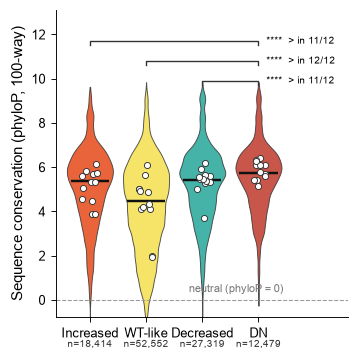

,n,median
group,,
High,18414,5.393
WT-like,52552,4.467
Low,27319,5.425
DN,12479,5.720


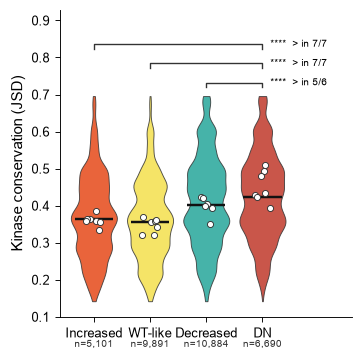

,n,median
group,,
High,5101,0.364
WT-like,9891,0.357
Low,10884,0.403
DN,6690,0.423


In [41]:
# ======================================================================
# Figure S3B — Evolutionary constraint violins — Configuration
# ======================================================================

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']
plt.rcParams['figure.facecolor'] = 'none'
plt.rcParams['axes.facecolor'] = 'none'
plt.rcParams['savefig.facecolor'] = 'none'

# Font sizes
FONT_SIZE_TITLE = 10
FONT_SIZE_LABEL = 9
FONT_SIZE_TICK = 8
FONT_SIZE_LEGEND = 8

# Line widths
LINE_WIDTH_AXES = 0.6
LINE_WIDTH_PLOT = 1.0


def plot_violin_panel(
    groups: Mapping[str, Sequence[float]] | None = None,
    *,
    series_groups: Mapping[str, Mapping[str, Sequence[float]]] | None = None,
    series_colors: Mapping[str, str] | None = None,
    series_dy: float = 0.20,
    series_width: float = 0.34,
    group_colors: Mapping[str, str] | None = None,
    median_bar: bool = False,
    bracket_vs: str | None = None,
    bracket_targets: Sequence[str] = (),
    bracket_gt_counts: Mapping[str, tuple[int, int]] | None = None,
    bracket_base: float | None = None,
    bracket_base_pad: float = 0.4,
    bracket_step: float = 0.9,
    bracket_tick: float = 0.2,
    bracket_dx: float = 0.14,
    bracket_fs: float = 6.5,
    bracket_stars_fn=stars_4tier_ns,
    ylim: tuple[float, float] | None = None,
    ylim_lo: float | None = None,
    ylim_lo_pct: float = 0.5,
    ylim_lo_pad: float = 0.5,
    ylim_top_pad: float = 0.5,
    xlim: tuple[float, float] | None = None,
    n_below: bool = False,
    ref_line: float | None = None,
    ref_color: str = "#999999",
    ref_ls: str = "--",
    ref_lw: float = 0.7,
    tight_layout: bool = False,
    ref_label: str = "",
    class_frac: pd.DataFrame | None = None,
    class_colors: Mapping[str, str] | None = None,
    class_order: Sequence[str] | None = None,
    point_overlay: pd.DataFrame | None = None,
    overlay_value_col: str | None = None,
    overlay_group_col: str | None = None,
    marker_values: Mapping[str, float] | None = None,
    marker_style: str = "dash",
    tiers: Sequence[tuple[str, Sequence[str]]] = (),
    tier_colors: Mapping[str, str] | None = None,
    tier_fs: float = 10.0,
    y_percent: bool = False,
    title_pad: float | None = None,
    violin_color: str = "#b9c2cf",
    violin_edge: str = "#4a5567",
    figsize: tuple[float, float] = (14.5, 9.4),
    height_ratios: Sequence[float] = (1.0, 4.5),
    widths: float = 0.78,
    show_violin_medians: bool = True,
    subplots_adjust: Mapping[str, float] | None = None,
    tick_labelsize: float | None = None,
    spine_lw: float | None = None,
    log_y: bool = False,
    hline: float | None = 1.0,
    ylabel: str = "Abundance score",
    show_n: bool = True,
    title: str = "",
    label_map: Mapping[str, str] | None = None,
    fs: Mapping[str, float] | None = None,
) -> tuple[Figure, np.ndarray]:
    """Violins per category, optionally with a class strip above and/or points.

    Port of ``scripts/plot_hsp90_score_violin.py`` — 14.5x9.4 in, class-fraction
    strip above the violins at a 1 : 4.5 height ratio so the violins remain the
    dominant element while the composition strip's columns stay locked to the
    violin x-positions.

    One function covers three panels by argument:

    * ``class_frac`` given -> the composition strip is drawn above (Fig 4D, S4A).
    * ``point_overlay`` given -> per-group medians are scattered as open
      circles over the violins, the check that a pooled signal is not a
      composition artifact (Fig S3B).
    * ``marker_values`` given -> a horizontal dash per category, used for the
      wild-type value on the dependence panel (Fig 4B).

    Args:
        groups: Ordered mapping of category -> values.
        class_frac: Rows indexed by the same categories, columns the classes.
        point_overlay: Long frame from which per-(group, category) medians are
            taken, using ``overlay_value_col`` and ``overlay_group_col``.
        marker_values: category -> value for the wild-type marker.
        marker_style: ``"dash"`` for a horizontal line spanning the slot, or
            ``"star"`` for the open star used by the fractional-change panel.
        tiers: ``(caption, [category, ...])`` groups, drawn with a bold coloured
            caption above the panel and a faint divider between groups — used
            when the categories are themselves grouped (the WT HSP90
            dependence tiers).
        tier_colors: caption -> colour, so a caption can be matched to the
            violin fills it describes.
        y_percent: Format the y-axis ticks as percentages.
        ref_color / ref_ls / ref_lw: Style of the ``ref_line``.
        tight_layout: Call ``fig.tight_layout()`` at the end. Only safe on the
            single-axes form — the strip form places its axes explicitly.
        title_pad: Padding for the title, in points.
        label_map: Optional category -> display-text override, applied only
            to the rendered tick labels. Internal category keys (used for
            grouping, ``group_colors``, ``bracket_vs``/``bracket_targets``,
            and ``bracket_gt_counts``) are untouched; any category not in
            this mapping falls back to its raw key (protein keys still route
            through ``protein_label`` first, taking priority over this map).
        fs: Font-size overrides; keys ``tick``, ``axis``, ``legend``, ``title``.
    """
    F = {"tick": 11, "axis": 13, "legend": 11, "title": 14}
    F.update(fs or {})
    if (groups is None) == (series_groups is None):
        raise ValueError("pass exactly one of `groups` or `series_groups`")

    # Normalise both call styles to {series: {category: values}}.
    nested = ({None: groups} if series_groups is None
              else {k: v for k, v in series_groups.items()})
    cats = list(dict.fromkeys(c for g in nested.values() for c in g))
    pos = np.arange(len(cats))
    scolors = dict(series_colors or VARIANT_TYPE_COLORS)
    group_colors = dict(group_colors) if group_colors else None
    series = list(nested)
    offs = (np.linspace(series_dy, -series_dy, len(series)) if len(series) > 1
            else np.zeros(1))
    w = series_width if len(series) > 1 else widths

    def _vals(s, c):
        return np.asarray([v for v in nested[s].get(c, []) if np.isfinite(v)],
                          dtype=float)

    # Per-category n for the tick labels: total across series.
    data = [np.concatenate([_vals(s, c) for s in series]) if series else
            np.array([]) for c in cats]

    if class_frac is not None:
        fig = plt.figure(figsize=figsize)
        gs = fig.add_gridspec(2, 1, height_ratios=list(height_ratios),
                              hspace=0.06)
        ax_strip, ax = fig.add_subplot(gs[0]), fig.add_subplot(gs[1])
    else:
        fig, ax = plt.subplots(figsize=figsize)
        ax_strip = None

    for si, s in enumerate(series):
        vv = [_vals(s, c) for c in cats]
        keep = [i for i, d in enumerate(vv) if d.size > 1]
        if not keep:
            continue
        parts = ax.violinplot([vv[i] for i in keep],
                              positions=pos[keep] + offs[si], widths=w,
                              showextrema=False,
                              showmedians=show_violin_medians)
        face = scolors.get(s, violin_color) if s is not None else violin_color
        for bi, b in zip(keep, parts["bodies"]):
            b.set_facecolor(group_colors.get(cats[bi], face) if group_colors
                            else face)
            b.set_edgecolor("#333333" if group_colors else
                            (violin_edge if s is None else "none"))
            b.set_alpha(0.85 if s is None else 0.8)
            b.set_linewidth(0.6 if group_colors else 0.5)
        if show_violin_medians:
            parts["cmedians"].set_color("#111111")
            parts["cmedians"].set_linewidth(1.1 if s is None else 0.9)
        if median_bar:
            # Wide flat median bar instead of the violin's thin default.
            if show_violin_medians:
                parts["cmedians"].set_alpha(0.0)
            for i in keep:
                ax.hlines(np.median(vv[i]), i - 0.34, i + 0.34,
                          color="#111111", linewidth=1.6, zorder=4)

    if marker_values:
        for i, c in enumerate(cats):
            v = marker_values.get(c)
            if v is None or not np.isfinite(v):
                continue
            if marker_style == "star":
                # Open star: reads as a distinct annotation against a filled
                # violin, where a dash would be mistaken for the median.
                ax.scatter(i, v, marker="*", s=120, facecolor="white",
                           edgecolor="black", linewidths=1.0, zorder=6)
            else:
                ax.plot([i - 0.30, i + 0.30], [v, v], color="#111111", lw=1.6,
                        zorder=6)

    if point_overlay is not None and overlay_value_col and overlay_group_col:
        rng = np.random.default_rng(0)
        for i, c in enumerate(cats):
            sub = point_overlay[point_overlay[overlay_group_col] == c]
            if not len(sub):
                continue
            ax.scatter(i + (rng.random(len(sub)) - 0.5) * 0.28,
                       sub[overlay_value_col].values, s=16, facecolor="white",
                       edgecolor="#333333", linewidth=0.6, zorder=5)

    if hline is not None:
        ax.axhline(hline, color="#666666", ls=":", lw=0.9)
    if log_y:
        ax.set_yscale("log")

    if ref_line is not None:
        ax.axhline(ref_line, color=ref_color, linewidth=ref_lw, linestyle=ref_ls,
                   zorder=1)
        if ref_label:
            ax.text(len(cats) - 0.55, ref_line + 0.25, ref_label, fontsize=7,
                    color="#777777", ha="right", va="bottom")

    ytop = None
    if bracket_vs is not None and bracket_targets:
        from scipy.stats import mannwhitneyu
        i_ref = cats.index(bracket_vs)
        vals = {c: data[cats.index(c)] for c in cats}
        base = (bracket_base if bracket_base is not None else
                max(np.percentile(v, 99.5) for v in vals.values() if v.size)
                + bracket_base_pad)
        step, tickh = bracket_step, bracket_tick
        for k, g in enumerate(bracket_targets):
            if g not in cats:
                continue
            i_g, y = cats.index(g), base + k * step
            _, pv = mannwhitneyu(vals[bracket_vs], vals[g],
                                 alternative="two-sided")
            note = bracket_stars_fn(pv)
            if bracket_gt_counts and g in bracket_gt_counts:
                n_gt, n_tot = bracket_gt_counts[g]
                note = f"{note}  > in {n_gt}/{n_tot}"
            ax.plot([i_g, i_g, i_ref, i_ref],
                    [y, y + tickh, y + tickh, y], color="#333333",
                    linewidth=0.9)
            ax.text(i_ref + bracket_dx, y + tickh, note, ha="left",
                    va="center", fontsize=bracket_fs)
        ytop = base + len(bracket_targets) * step + tickh

    if series_groups is not None:
        handles = [plt.Line2D([], [], color=scolors.get(s, violin_color), lw=5,
                              alpha=0.8, label=str(s)) for s in series]
        if marker_values:
            handles.append(plt.Line2D([], [], color="#111111", lw=1.6,
                                      label="wild type"))
        ax.legend(handles=handles, frameon=False, loc="upper right",
                  fontsize=F["legend"])

    # With brackets on, leave a full slot to the right so the annotations are
    # not clipped — the source figures use (-0.6, 4.6) for four groups.
    ax.set_xlim(*(xlim if xlim is not None else
                  ((-0.6, len(cats) + 0.6) if bracket_vs is not None
                   else (-0.6, len(cats) - 0.4))))
    ax.set_xticks(pos)

    def _disp(c):
        # Protein keys keep taking priority; anything else gets the caller's
        # display-text override if one is provided, otherwise the raw key.
        if str(c).lower() in PROTEIN_KEYS:
            return protein_label(c)
        return (label_map or {}).get(c, str(c))

    tick = [_disp(c) for c in cats]
    if show_n:
        tick = [f"{t}\n(n={d.size:,})" for t, d in zip(tick, data)]
    if n_below:
        ax.set_xticklabels([_disp(c) for c in cats], fontsize=F["tick"])
        for i, d in enumerate(data):
            ax.annotate(f"n={d.size:,}", xy=(i, 0),
                        xycoords=("data", "axes fraction"), xytext=(0, -15),
                        textcoords="offset points", ha="center", va="top",
                        fontsize=6.5, color="#333333", annotation_clip=False)
    else:
        ax.set_xticklabels(tick, rotation=45, ha="right", fontsize=F["tick"])
    if ylim is not None:
        ax.set_ylim(*ylim)
    elif ytop is not None:
        # Pooled percentile, not the minimum of the per-group percentiles.
        pooled = np.concatenate([d for d in data if d.size])
        lo = (ylim_lo if ylim_lo is not None
              else np.percentile(pooled, ylim_lo_pct) - ylim_lo_pad)
        ax.set_ylim(lo, ytop + ylim_top_pad)
    ax.set_ylabel(ylabel, fontsize=F["axis"])
    if tiers:
        # Dividers on the boundaries between tiers, and one bold caption per
        # tier in its own colour, anchored in axes fraction so it stays at the
        # visual top of the panel.
        edge = 0
        for _, members in list(tiers)[:-1]:
            edge += len(members)
            ax.axvline(edge - 0.5, color="0.85", lw=0.9, zorder=0)
        for caption, members in tiers:
            idxs = [cats.index(m) for m in members if m in cats]
            if not idxs:
                continue
            ax.text((idxs[0] + idxs[-1]) / 2, 1.02, caption, ha="center",
                    va="bottom", fontsize=tier_fs, fontweight="bold",
                    transform=ax.get_xaxis_transform(),
                    color=(tier_colors or {}).get(caption, "#111111"))

    if y_percent:
        ax.yaxis.set_major_formatter(
            plt.FuncFormatter(lambda v, _p: f"{v * 100:.0f}%"))

    for s in ("top", "right"):
        ax.spines[s].set_visible(False)

    if ax_strip is not None:
        colors = dict(class_colors or BUFFERING_COLORS)
        order = list(class_order or [c for c in BUFFERING_ORDER
                                     if c in class_frac.columns])
        base = np.zeros(len(cats))
        for cls in order:
            v = class_frac.reindex(cats)[cls].fillna(0.0).values
            ax_strip.bar(pos, v, bottom=base, width=widths,
                         color=colors.get(cls, "#999999"), edgecolor="white",
                         linewidth=0.3, label=cls)
            base = base + v
        ax_strip.set_xlim(-0.6, len(cats) - 0.4)
        ax_strip.set_ylim(0, 1)
        ax_strip.set_xticks([])
        ax_strip.set_yticks([0, 0.5, 1])
        ax_strip.set_yticklabels(["0", "", "1"], fontsize=F["tick"] - 2)
        ax_strip.set_ylabel("fraction", fontsize=F["axis"] - 3)
        for s in ("top", "right"):
            ax_strip.spines[s].set_visible(False)
        ax_strip.legend(frameon=False, ncol=len(order),
                        bbox_to_anchor=(0.0, 1.02), loc="lower left",
                        fontsize=F["legend"])
        if title:
            ax_strip.set_title(title, loc="left", pad=26, fontsize=F["title"])
    elif title:
        ax.set_title(title, loc="left", fontsize=F["title"],
                     **({"pad": title_pad} if title_pad else {}))
    if tick_labelsize is not None:
        ax.tick_params(axis="both", labelsize=tick_labelsize)
    if spine_lw is not None:
        for s in ("left", "bottom"):
            ax.spines[s].set_linewidth(spine_lw)
    if subplots_adjust:
        fig.subplots_adjust(**subplots_adjust)
    if tight_layout:
        fig.tight_layout()
    return fig, np.array([a for a in (ax_strip, ax) if a is not None],
                         dtype=object)


# --- Generate plot ---

cons_pool = dn_pool[dn_pool["Mutation Type"].isin(["missense", "deletion"])].copy()
cons_pool["group"] = activity_group(cons_pool).map(
    {"high": "High", "wt-like": "WT-like", "low": "Low", "DN": "DN"})

# Axis and bracket geometry taken literally from the two source scripts —
# they differ because phyloP is unbounded while JSD is bounded on [0, 1], so a
# bracket ladder sized for phyloP would crush the JSD violins.
PANELS = [
    dict(col="phylop_vert", ylab="Sequence conservation (phyloP, 100-way)",
         stem="ExtDataDN7b_phylop_by_activity_group", domain=None, proteins=None,
         ref=0.0, ref_lab="neutral (phyloP = 0)",
         geom=dict(bracket_base=None, bracket_base_pad=0.4,
                   bracket_step=0.9, bracket_tick=0.2,
                   ylim_lo_pct=0.5, ylim_lo_pad=0.5, ylim_top_pad=0.5)),
    # Restricted to kinase-domain positions of the 7 kinase-containing
    # DN-eligible proteins, as the source script does: the metric is defined
    # only within the kinase fold, so the GTPases, GEFs and the phosphatase
    # have no value and must not be pooled in as missing.
    # jsd_conservation, NOT a Shannon-entropy column. Both are per-column
    # scores on the same Modi-Dunbrack kinase alignment, but jsd_conservation is
    # Capra-Singh Jensen-Shannon divergence (window 3, BLOSUM62 background,
    # sequence weighting, gapped columns dropped) and the Shannon version had no
    # window, no background and no gap filter, and counted the alignment's
    # ANNOTATION pseudo-sequence as a sequence.
    # This panel was built on the Shannon column while its axis said JSD. JSD
    # is what the label claims, is the better-validated statistic (Capra &
    # Singh 2007, PMID 17519246, show it beats Shannon entropy at recovering
    # functional residues), and gives the cleaner per-protein result here:
    # the DN median exceeds Low in 6/6 proteins, against 5/6 on Shannon.
    dict(col="jsd_conservation", ylab="Kinase conservation (JSD)",
         stem="figs3b_kinase_conservation_by_activity_group", domain="kinase",
         proteins=["araf", "braf", "craf", "egfr", "erbb2", "met", "ret"],
         ref=None, ref_lab="",
         # Tuned for JSD's compressed range, so the bracket
         # ladder sits clear of the violins.
         geom=dict(bracket_base=0.72, bracket_step=0.052, bracket_tick=0.012,
                   ylim_lo=0.10, ylim_top_pad=0.04)),
]

# Display-only override: internal group keys stay "High"/"Low" everywhere
# (grouping, ACTIVITY_GROUP_COLOR, bracket_vs/bracket_targets, gt lookups),
# but the rendered tick labels read "Increased"/"Decreased".
GROUP_LABEL_MAP = {"High": "Increased", "Low": "Decreased"}

for P in PANELS:
    col, ylab, stem = P["col"], P["ylab"], P["stem"]
    ref, ref_lab = P["ref"], P["ref_lab"]
    d = cons_pool.dropna(subset=[col, "group"])
    if P["domain"]:
        d = d[d.domain == P["domain"]]
    if P["proteins"]:
        d = d[d.protein.isin(P["proteins"])]
    if d.empty:
        print(f"  {col}: no data, skipped")
        continue

    groups = {g: d.loc[d.group == g, col].values
              for g in ACTIVITY_GROUP_ORDER if (d.group == g).any()}

    # Per-protein medians, only where the cell has enough variants to be stable.
    med = (d.groupby(["protein", "group"])[col]
           .agg(["median", "size"]).reset_index())
    med = med[med["size"] >= MIN_N_PER_PROTEIN]

    # "> in n/N": proteins where the DN median beats the comparison group's.
    wide = med.pivot(index="protein", columns="group", values="median")
    gt = {}
    for g in ("Low", "WT-like", "High"):
        if g in wide.columns and "DN" in wide.columns:
            both = wide[["DN", g]].dropna()
            gt[g] = (int((both["DN"] > both[g]).sum()), len(both))

    fig, _ = plot_violin_panel(
        groups,
        group_colors=ACTIVITY_GROUP_COLOR, median_bar=True,
        point_overlay=med.rename(columns={"median": "value"}),
        overlay_value_col="value", overlay_group_col="group",
        bracket_vs="DN", bracket_targets=["Low", "WT-like", "High"],
        bracket_gt_counts=gt, n_below=True,
        ref_line=ref, ref_label=ref_lab,
        hline=None, show_n=False, figsize=(3.45, 3.4), ylabel=ylab,
        xlim=(-0.6, 4.6), fs={"tick": 9, "axis": 10},
        # Literal cosmetics from the source scripts.
        widths=0.82, show_violin_medians=False, tick_labelsize=8.5,
        spine_lw=0.6,
        label_map=GROUP_LABEL_MAP,
        # The violins look rippled, and that is left alone deliberately.
        # Both metrics are POSITION-level: every substitution at a residue
        # carries that residue's single value, so the cohort holds far fewer
        # distinct values than rows, and Scott's rule picks a bandwidth narrow
        # enough to resolve them as separate modes. Widening the
        # kernel hides the discreteness rather than representing it, and
        # the bandwidth that looks smoothest is also the one that flattens
        # the between-group shape differences, so we keep the default.
        subplots_adjust=dict(left=0.20, right=0.97, top=0.97, bottom=0.15),
        **P["geom"])
    save_figure(fig, FIG / stem, tight=False)
    plt.show()

    summ = d.groupby("group")[col].agg(n="size", median="median").round(3)
    display(summ.reindex([g for g in ACTIVITY_GROUP_ORDER
                          if g in summ.index]))
    

,n,median
group,,
High,18414,5.393
WT-like,52552,4.467
Low,27319,5.425
DN,12479,5.720


,n,median
group,,
High,5101,0.364
WT-like,9891,0.357
Low,10884,0.403
DN,6690,0.423


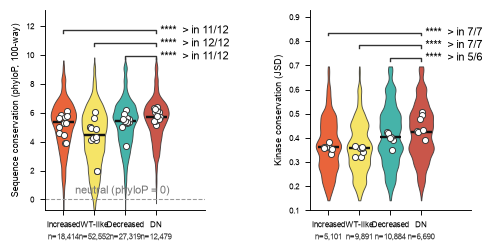

In [42]:
# ======================================================================
# Figure S3B — Evolutionary constraint violins — Configuration
# ======================================================================

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']
plt.rcParams['figure.facecolor'] = 'none'
plt.rcParams['axes.facecolor'] = 'none'
plt.rcParams['savefig.facecolor'] = 'none'
# Keep SVG text as real, editable <text> elements (e.g. in Illustrator)
# instead of being converted to outlined paths on export.
plt.rcParams['svg.fonttype'] = 'none'

# Font sizes
FONT_SIZE_TITLE = 6
FONT_SIZE_LABEL = 6
FONT_SIZE_TICK = 6
FONT_SIZE_LEGEND = 6
FONT_SIZE_N = 5  # "n=x" annotations only

# Line widths
LINE_WIDTH_AXES = 0.6
LINE_WIDTH_PLOT = 1.0


def plot_violin_panel(
    groups: Mapping[str, Sequence[float]] | None = None,
    *,
    series_groups: Mapping[str, Mapping[str, Sequence[float]]] | None = None,
    series_colors: Mapping[str, str] | None = None,
    series_dy: float = 0.20,
    series_width: float = 0.34,
    group_colors: Mapping[str, str] | None = None,
    median_bar: bool = False,
    bracket_vs: str | None = None,
    bracket_targets: Sequence[str] = (),
    bracket_gt_counts: Mapping[str, tuple[int, int]] | None = None,
    bracket_base: float | None = None,
    bracket_base_pad: float = 0.4,
    bracket_step: float = 0.9,
    bracket_tick: float = 0.2,
    bracket_dx: float = 0.14,
    bracket_fs: float = 7,
    bracket_stars_fn=stars_4tier_ns,
    ylim: tuple[float, float] | None = None,
    ylim_lo: float | None = None,
    ylim_lo_pct: float = 0.5,
    ylim_lo_pad: float = 0.5,
    ylim_top_pad: float = 0.5,
    xlim: tuple[float, float] | None = None,
    n_below: bool = False,
    ref_line: float | None = None,
    ref_color: str = "#999999",
    ref_ls: str = "--",
    ref_lw: float = 0.7,
    tight_layout: bool = False,
    ref_label: str = "",
    class_frac: pd.DataFrame | None = None,
    class_colors: Mapping[str, str] | None = None,
    class_order: Sequence[str] | None = None,
    point_overlay: pd.DataFrame | None = None,
    overlay_value_col: str | None = None,
    overlay_group_col: str | None = None,
    marker_values: Mapping[str, float] | None = None,
    marker_style: str = "dash",
    tiers: Sequence[tuple[str, Sequence[str]]] = (),
    tier_colors: Mapping[str, str] | None = None,
    tier_fs: float = 7.0,
    y_percent: bool = False,
    title_pad: float | None = None,
    violin_color: str = "#b9c2cf",
    violin_edge: str = "#4a5567",
    figsize: tuple[float, float] = (14.5, 9.4),
    height_ratios: Sequence[float] = (1.0, 4.5),
    widths: float = 0.78,
    show_violin_medians: bool = True,
    subplots_adjust: Mapping[str, float] | None = None,
    tick_labelsize: float | None = None,
    spine_lw: float | None = None,
    log_y: bool = False,
    hline: float | None = 1.0,
    ylabel: str = "Abundance score",
    show_n: bool = True,
    title: str = "",
    label_map: Mapping[str, str] | None = None,
    fs: Mapping[str, float] | None = None,
    ax: Axes | None = None,
) -> tuple[Figure, np.ndarray]:
    """Violins per category, optionally with a class strip above and/or points.

    Port of ``scripts/plot_hsp90_score_violin.py`` — 14.5x9.4 in, class-fraction
    strip above the violins at a 1 : 4.5 height ratio so the violins remain the
    dominant element while the composition strip's columns stay locked to the
    violin x-positions.

    One function covers three panels by argument:

    * ``class_frac`` given -> the composition strip is drawn above (Fig 4D, S4A).
    * ``point_overlay`` given -> per-group medians are scattered as open
      circles over the violins, the check that a pooled signal is not a
      composition artifact (Fig S3B).
    * ``marker_values`` given -> a horizontal dash per category, used for the
      wild-type value on the dependence panel (Fig 4B).

    Args:
        groups: Ordered mapping of category -> values.
        class_frac: Rows indexed by the same categories, columns the classes.
        point_overlay: Long frame from which per-(group, category) medians are
            taken, using ``overlay_value_col`` and ``overlay_group_col``.
        marker_values: category -> value for the wild-type marker.
        marker_style: ``"dash"`` for a horizontal line spanning the slot, or
            ``"star"`` for the open star used by the fractional-change panel.
        tiers: ``(caption, [category, ...])`` groups, drawn with a bold coloured
            caption above the panel and a faint divider between groups — used
            when the categories are themselves grouped (the WT HSP90
            dependence tiers).
        tier_colors: caption -> colour, so a caption can be matched to the
            violin fills it describes.
        y_percent: Format the y-axis ticks as percentages.
        ref_color / ref_ls / ref_lw: Style of the ``ref_line``.
        tight_layout: Call ``fig.tight_layout()`` at the end. Only safe on the
            single-axes form — the strip form places its axes explicitly.
        title_pad: Padding for the title, in points.
        label_map: Optional category -> display-text override, applied only
            to the rendered tick labels. Internal category keys (used for
            grouping, ``group_colors``, ``bracket_vs``/``bracket_targets``,
            and ``bracket_gt_counts``) are untouched; any category not in
            this mapping falls back to its raw key (protein keys still route
            through ``protein_label`` first, taking priority over this map).
        fs: Font-size overrides; keys ``tick``, ``axis``, ``legend``, ``title``.
        ax: Existing axes to draw the violins into, so several panels can
            share one figure (e.g. side-by-side subplots created by the
            caller). When given, ``figsize``, ``subplots_adjust``, and
            ``tight_layout`` are ignored — the caller owns the figure-level
            layout — and this cannot be combined with ``class_frac``, since
            the composition strip needs its own gridspec.
    """
    F = {"tick": 7, "axis": 7, "legend": 7, "title": 7}
    F.update(fs or {})
    if (groups is None) == (series_groups is None):
        raise ValueError("pass exactly one of `groups` or `series_groups`")

    # Normalise both call styles to {series: {category: values}}.
    nested = ({None: groups} if series_groups is None
              else {k: v for k, v in series_groups.items()})
    cats = list(dict.fromkeys(c for g in nested.values() for c in g))
    pos = np.arange(len(cats))
    scolors = dict(series_colors or VARIANT_TYPE_COLORS)
    group_colors = dict(group_colors) if group_colors else None
    series = list(nested)
    offs = (np.linspace(series_dy, -series_dy, len(series)) if len(series) > 1
            else np.zeros(1))
    w = series_width if len(series) > 1 else widths

    def _vals(s, c):
        return np.asarray([v for v in nested[s].get(c, []) if np.isfinite(v)],
                          dtype=float)

    # Per-category n for the tick labels: total across series.
    data = [np.concatenate([_vals(s, c) for s in series]) if series else
            np.array([]) for c in cats]

    ax_provided = ax is not None
    if ax_provided:
        if class_frac is not None:
            raise ValueError("`ax` cannot be combined with `class_frac` — "
                              "the composition strip needs its own gridspec")
        fig, ax_strip = ax.figure, None
    elif class_frac is not None:
        fig = plt.figure(figsize=figsize)
        gs = fig.add_gridspec(2, 1, height_ratios=list(height_ratios),
                              hspace=0.06)
        ax_strip, ax = fig.add_subplot(gs[0]), fig.add_subplot(gs[1])
    else:
        fig, ax = plt.subplots(figsize=figsize)
        ax_strip = None

    for si, s in enumerate(series):
        vv = [_vals(s, c) for c in cats]
        keep = [i for i, d in enumerate(vv) if d.size > 1]
        if not keep:
            continue
        parts = ax.violinplot([vv[i] for i in keep],
                              positions=pos[keep] + offs[si], widths=w,
                              showextrema=False,
                              showmedians=show_violin_medians)
        face = scolors.get(s, violin_color) if s is not None else violin_color
        for bi, b in zip(keep, parts["bodies"]):
            b.set_facecolor(group_colors.get(cats[bi], face) if group_colors
                            else face)
            b.set_edgecolor("#333333" if group_colors else
                            (violin_edge if s is None else "none"))
            b.set_alpha(0.85 if s is None else 0.8)
            b.set_linewidth(0.6 if group_colors else 0.5)
        if show_violin_medians:
            parts["cmedians"].set_color("#111111")
            parts["cmedians"].set_linewidth(1.1 if s is None else 0.9)
        if median_bar:
            # Wide flat median bar instead of the violin's thin default.
            if show_violin_medians:
                parts["cmedians"].set_alpha(0.0)
            for i in keep:
                ax.hlines(np.median(vv[i]), i - 0.34, i + 0.34,
                          color="#111111", linewidth=1.6, zorder=4)

    if marker_values:
        for i, c in enumerate(cats):
            v = marker_values.get(c)
            if v is None or not np.isfinite(v):
                continue
            if marker_style == "star":
                # Open star: reads as a distinct annotation against a filled
                # violin, where a dash would be mistaken for the median.
                ax.scatter(i, v, marker="*", s=120, facecolor="white",
                           edgecolor="black", linewidths=1.0, zorder=6)
            else:
                ax.plot([i - 0.30, i + 0.30], [v, v], color="#111111", lw=1.6,
                        zorder=6)

    if point_overlay is not None and overlay_value_col and overlay_group_col:
        rng = np.random.default_rng(0)
        for i, c in enumerate(cats):
            sub = point_overlay[point_overlay[overlay_group_col] == c]
            if not len(sub):
                continue
            ax.scatter(i + (rng.random(len(sub)) - 0.5) * 0.28,
                       sub[overlay_value_col].values, s=16, facecolor="white",
                       edgecolor="#333333", linewidth=0.6, zorder=5)

    if hline is not None:
        ax.axhline(hline, color="#666666", ls=":", lw=0.9)
    if log_y:
        ax.set_yscale("log")

    if ref_line is not None:
        ax.axhline(ref_line, color=ref_color, linewidth=ref_lw, linestyle=ref_ls,
                   zorder=1)
        if ref_label:
            ax.text(len(cats) - 0.55, ref_line + 0.25, ref_label, fontsize=7,
                    color="#777777", ha="right", va="bottom")

    ytop = None
    if bracket_vs is not None and bracket_targets:
        from scipy.stats import mannwhitneyu
        i_ref = cats.index(bracket_vs)
        vals = {c: data[cats.index(c)] for c in cats}
        base = (bracket_base if bracket_base is not None else
                max(np.percentile(v, 99.5) for v in vals.values() if v.size)
                + bracket_base_pad)
        step, tickh = bracket_step, bracket_tick
        for k, g in enumerate(bracket_targets):
            if g not in cats:
                continue
            i_g, y = cats.index(g), base + k * step
            _, pv = mannwhitneyu(vals[bracket_vs], vals[g],
                                 alternative="two-sided")
            note = bracket_stars_fn(pv)
            if bracket_gt_counts and g in bracket_gt_counts:
                n_gt, n_tot = bracket_gt_counts[g]
                note = f"{note}  > in {n_gt}/{n_tot}"
            ax.plot([i_g, i_g, i_ref, i_ref],
                    [y, y + tickh, y + tickh, y], color="#333333",
                    linewidth=0.9)
            ax.text(i_ref + bracket_dx, y + tickh, note, ha="left",
                    va="center", fontsize=bracket_fs)
        ytop = base + len(bracket_targets) * step + tickh

    if series_groups is not None:
        handles = [plt.Line2D([], [], color=scolors.get(s, violin_color), lw=5,
                              alpha=0.8, label=str(s)) for s in series]
        if marker_values:
            handles.append(plt.Line2D([], [], color="#111111", lw=1.6,
                                      label="wild type"))
        ax.legend(handles=handles, frameon=False, loc="upper right",
                  fontsize=F["legend"])

    # With brackets on, leave a full slot to the right so the annotations are
    # not clipped — the source figures use (-0.6, 4.6) for four groups.
    ax.set_xlim(*(xlim if xlim is not None else
                  ((-0.6, len(cats) + 0.6) if bracket_vs is not None
                   else (-0.6, len(cats) - 0.4))))
    ax.set_xticks(pos)

    def _disp(c):
        # Protein keys keep taking priority; anything else gets the caller's
        # display-text override if one is provided, otherwise the raw key.
        if str(c).lower() in PROTEIN_KEYS:
            return protein_label(c)
        return (label_map or {}).get(c, str(c))

    tick = [_disp(c) for c in cats]
    if show_n:
        tick = [f"{t}\n(n={d.size:,})" for t, d in zip(tick, data)]
    if n_below:
        ax.set_xticklabels([_disp(c) for c in cats], fontsize=F["tick"])
        for i, d in enumerate(data):
            ax.annotate(f"n={d.size:,}", xy=(i, 0),
                        xycoords=("data", "axes fraction"), xytext=(0, -15),
                        textcoords="offset points", ha="center", va="top",
                        fontsize=FONT_SIZE_N, color="#333333",
                        annotation_clip=False)
    else:
        ax.set_xticklabels(tick, rotation=45, ha="right", fontsize=F["tick"])
    if ylim is not None:
        ax.set_ylim(*ylim)
    elif ytop is not None:
        # Pooled percentile, not the minimum of the per-group percentiles.
        pooled = np.concatenate([d for d in data if d.size])
        lo = (ylim_lo if ylim_lo is not None
              else np.percentile(pooled, ylim_lo_pct) - ylim_lo_pad)
        ax.set_ylim(lo, ytop + ylim_top_pad)
    ax.set_ylabel(ylabel, fontsize=F["axis"])
    if tiers:
        # Dividers on the boundaries between tiers, and one bold caption per
        # tier in its own colour, anchored in axes fraction so it stays at the
        # visual top of the panel.
        edge = 0
        for _, members in list(tiers)[:-1]:
            edge += len(members)
            ax.axvline(edge - 0.5, color="0.85", lw=0.9, zorder=0)
        for caption, members in tiers:
            idxs = [cats.index(m) for m in members if m in cats]
            if not idxs:
                continue
            ax.text((idxs[0] + idxs[-1]) / 2, 1.02, caption, ha="center",
                    va="bottom", fontsize=tier_fs, fontweight="bold",
                    transform=ax.get_xaxis_transform(),
                    color=(tier_colors or {}).get(caption, "#111111"))

    if y_percent:
        ax.yaxis.set_major_formatter(
            plt.FuncFormatter(lambda v, _p: f"{v * 100:.0f}%"))

    for s in ("top", "right"):
        ax.spines[s].set_visible(False)

    if ax_strip is not None:
        colors = dict(class_colors or BUFFERING_COLORS)
        order = list(class_order or [c for c in BUFFERING_ORDER
                                     if c in class_frac.columns])
        base = np.zeros(len(cats))
        for cls in order:
            v = class_frac.reindex(cats)[cls].fillna(0.0).values
            ax_strip.bar(pos, v, bottom=base, width=widths,
                         color=colors.get(cls, "#999999"), edgecolor="white",
                         linewidth=0.3, label=cls)
            base = base + v
        ax_strip.set_xlim(-0.6, len(cats) - 0.4)
        ax_strip.set_ylim(0, 1)
        ax_strip.set_xticks([])
        ax_strip.set_yticks([0, 0.5, 1])
        ax_strip.set_yticklabels(["0", "", "1"], fontsize=F["tick"])
        ax_strip.set_ylabel("fraction", fontsize=F["axis"])
        for s in ("top", "right"):
            ax_strip.spines[s].set_visible(False)
        ax_strip.legend(frameon=False, ncol=len(order),
                        bbox_to_anchor=(0.0, 1.02), loc="lower left",
                        fontsize=F["legend"])
        if title:
            ax_strip.set_title(title, loc="left", pad=26, fontsize=F["title"])
    elif title:
        ax.set_title(title, loc="left", fontsize=F["title"],
                     **({"pad": title_pad} if title_pad else {}))
    if tick_labelsize is not None:
        ax.tick_params(axis="both", labelsize=tick_labelsize)
    if spine_lw is not None:
        for s in ("left", "bottom"):
            ax.spines[s].set_linewidth(spine_lw)
    if subplots_adjust and not ax_provided:
        fig.subplots_adjust(**subplots_adjust)
    if tight_layout and not ax_provided:
        fig.tight_layout()
    return fig, np.array([a for a in (ax_strip, ax) if a is not None],
                         dtype=object)


# --- Generate plot ---

cons_pool = dn_pool[dn_pool["Mutation Type"].isin(["missense", "deletion"])].copy()
cons_pool["group"] = activity_group(cons_pool).map(
    {"high": "High", "wt-like": "WT-like", "low": "Low", "DN": "DN"})

# Axis and bracket geometry taken literally from the two source scripts —
# they differ because phyloP is unbounded while JSD is bounded on [0, 1], so a
# bracket ladder sized for phyloP would crush the JSD violins.
PANELS = [
    dict(col="phylop_vert", ylab="Sequence conservation (phyloP, 100-way)",
         stem="ExtDataDN7b_phylop_by_activity_group", domain=None, proteins=None,
         ref=0.0, ref_lab="neutral (phyloP = 0)",
         geom=dict(bracket_base=None, bracket_base_pad=0.4,
                   bracket_step=0.9, bracket_tick=0.2,
                   ylim_lo_pct=0.5, ylim_lo_pad=0.5, ylim_top_pad=0.5)),
    # Restricted to kinase-domain positions of the 7 kinase-containing
    # DN-eligible proteins, as the source script does: the metric is defined
    # only within the kinase fold, so the GTPases, GEFs and the phosphatase
    # have no value and must not be pooled in as missing.
    # jsd_conservation, NOT a Shannon-entropy column. Both are per-column
    # scores on the same Modi-Dunbrack kinase alignment, but jsd_conservation is
    # Capra-Singh Jensen-Shannon divergence (window 3, BLOSUM62 background,
    # sequence weighting, gapped columns dropped) and the Shannon version had no
    # window, no background and no gap filter, and counted the alignment's
    # ANNOTATION pseudo-sequence as a sequence.
    # This panel was built on the Shannon column while its axis said JSD. JSD
    # is what the label claims, is the better-validated statistic (Capra &
    # Singh 2007, PMID 17519246, show it beats Shannon entropy at recovering
    # functional residues), and gives the cleaner per-protein result here:
    # the DN median exceeds Low in 6/6 proteins, against 5/6 on Shannon.
    dict(col="jsd_conservation", ylab="Kinase conservation (JSD)",
         stem="figs3b_kinase_conservation_by_activity_group", domain="kinase",
         proteins=["araf", "braf", "craf", "egfr", "erbb2", "met", "ret"],
         ref=None, ref_lab="",
         # Tuned for JSD's compressed range, so the bracket
         # ladder sits clear of the violins.
         geom=dict(bracket_base=0.72, bracket_step=0.052, bracket_tick=0.012,
                   ylim_lo=0.10, ylim_top_pad=0.04)),
]

# Display-only override: internal group keys stay "High"/"Low" everywhere
# (grouping, ACTIVITY_GROUP_COLOR, bracket_vs/bracket_targets, gt lookups),
# but the rendered tick labels read "Increased"/"Decreased".
GROUP_LABEL_MAP = {"High": "Increased", "Low": "Decreased"}

# Both panels now live in one figure, side by side, at the combined
# figure's final size — 4 in wide by 2.1 in tall — rather than each panel
# getting its own figure at its own size.
fig, axes = plt.subplots(1, len(PANELS), figsize=(4.5, 2.8))

for P, panel_ax in zip(PANELS, axes):
    col, ylab, stem = P["col"], P["ylab"], P["stem"]
    ref, ref_lab = P["ref"], P["ref_lab"]
    d = cons_pool.dropna(subset=[col, "group"])
    if P["domain"]:
        d = d[d.domain == P["domain"]]
    if P["proteins"]:
        d = d[d.protein.isin(P["proteins"])]
    if d.empty:
        print(f"  {col}: no data, skipped")
        continue

    groups = {g: d.loc[d.group == g, col].values
              for g in ACTIVITY_GROUP_ORDER if (d.group == g).any()}

    # Per-protein medians, only where the cell has enough variants to be stable.
    med = (d.groupby(["protein", "group"])[col]
           .agg(["median", "size"]).reset_index())
    med = med[med["size"] >= MIN_N_PER_PROTEIN]

    # "> in n/N": proteins where the DN median beats the comparison group's.
    wide = med.pivot(index="protein", columns="group", values="median")
    gt = {}
    for g in ("Low", "WT-like", "High"):
        if g in wide.columns and "DN" in wide.columns:
            both = wide[["DN", g]].dropna()
            gt[g] = (int((both["DN"] > both[g]).sum()), len(both))

    plot_violin_panel(
        groups,
        ax=panel_ax,
        group_colors=ACTIVITY_GROUP_COLOR, median_bar=True,
        point_overlay=med.rename(columns={"median": "value"}),
        overlay_value_col="value", overlay_group_col="group",
        bracket_vs="DN", bracket_targets=["Low", "WT-like", "High"],
        bracket_gt_counts=gt, n_below=True,
        ref_line=ref, ref_label=ref_lab,
        hline=None, show_n=False, ylabel=ylab,
        xlim=(-0.6, 4.6), fs={"tick": 6, "axis": 6},
        # Literal cosmetics from the source scripts.
        widths=0.82, show_violin_medians=False, tick_labelsize=5.5,
        spine_lw=0.6,
        label_map=GROUP_LABEL_MAP,
        # The violins look rippled, and that is left alone deliberately.
        # Both metrics are POSITION-level: every substitution at a residue
        # carries that residue's single value, so the cohort holds far fewer
        # distinct values than rows, and Scott's rule picks a bandwidth narrow
        # enough to resolve them as separate modes. Widening the
        # kernel hides the discreteness rather than representing it, and
        # the bandwidth that looks smoothest is also the one that flattens
        # the between-group shape differences, so we keep the default.
        **P["geom"])

    summ = d.groupby("group")[col].agg(n="size", median="median").round(3)
    display(summ.reindex([g for g in ACTIVITY_GROUP_ORDER
                          if g in summ.index]))

# One shared layout pass and one save for the combined 4in x 2.1in figure,
# now that both panels have been drawn into it.
fig.subplots_adjust(left=0.12, right=0.98, top=0.95, bottom=0.30, wspace=0.65)
save_figure(fig, FIG / "ExtData8b_conservation_panels_combined", tight=False)
plt.show()

## Figure 3F — Population/cancer depletion (pooled forest)

,n
group,
wt-like,22121
low,10256
high,7175
DN,4563
Nonsense (NMD-trigger),2487
Nonsense (NMD-escape),226


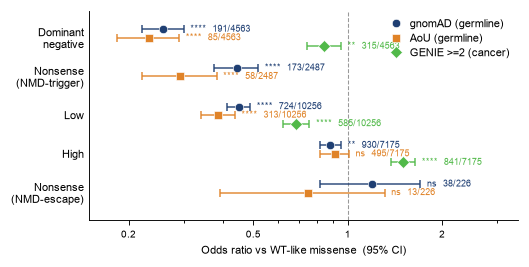

database,AoU,GENIE,gnomAD
label_key,,,
DN,0.233,0.840,0.258
Nonsense (NMD-escape),0.748,NaN,1.195
Nonsense (NMD-trigger),0.293,NaN,0.442
high,0.908,1.504,0.880
low,0.386,0.685,0.449



annotation = significance, then variants observed / variants tested


In [43]:
# ======================================================================
# Figure 3I — Population/cancer depletion — Configuration
# ======================================================================

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']
plt.rcParams['figure.facecolor'] = 'none'
plt.rcParams['axes.facecolor'] = 'none'
plt.rcParams['savefig.facecolor'] = 'none'
plt.rcParams['svg.fonttype'] = 'none'

# Font sizes
FONT_SIZE_TITLE = 7
FONT_SIZE_LABEL = 7
FONT_SIZE_TICK = 7
FONT_SIZE_LEGEND = 7

# Line widths
LINE_WIDTH_AXES = 0.6
LINE_WIDTH_PLOT = 1.0


def plot_class_depletion_pooled(
    df: pd.DataFrame,
    *,
    class_order: Sequence[tuple[str, str]],
    db_style: Mapping[str, Mapping[str, str]] | None = None,
    db_offset: Mapping[str, float] | None = None,
    figsize: tuple[float, float] = (5, 2.5),
    xlim: tuple[float, float] = (0.15, 3.5),
    xticks: Sequence[float] = (0.2, 0.5, 1.0, 2.0),
    xlabel: str = "Odds ratio vs WT-like missense  (95% CI)",
    genie_legend_label: str | None = None,
    stars_fn=stars_4tier,
    sig_col: str = "q",
) -> tuple[Figure, Axes]:
    """Pooled class-depletion forest, three databases per class.

    Verbatim port of ``render`` in ``scripts/plot_class_depletion_global.py`` —
    5.5 x 2.6 in, per-database colour/marker/offset, 5.5 pt markers with white
    edges, 1.0 pt whiskers and 2.5 pt caps, the ``{stars}  {n_obs}/{n_tot}``
    annotation at 1.05x the CI upper bound in the series colour, a dashed grey
    OR=1 reference, log x fixed to 0.15-3.5, and the legend inside the
    upper-right corner (empty because the data only reaches OR ~1.6).

    There is deliberately **no WT-like row**: WT-like is the reference the odds
    ratios are computed against, so its OR is 1 by construction and plotting it
    would imply a measurement.

    Classes with no coverage in a database simply render no marker for it — the
    nonsense rows have no GENIE data because stop-gains are not recurrent
    cancer drivers.

    Significance stars are computed from ``sig_col`` (default ``"q"``, the
    BH-FDR-corrected value), not the raw p-value, so the annotation reflects
    multiple-testing correction across the family of tests plotted.

    Args:
        df: One row per (class, database) with ``class``, ``database``, ``or``,
            ``ci_low``, ``ci_high``, ``p``, ``q``, ``n_obs``, ``n_tot``. All
            computed in the notebook; ``q`` is the BH-corrected q-value used
            for the plotted stars.
        class_order: ``(class_key, display_label)`` top to bottom; the labels
            carry their own line breaks.
        genie_legend_label: Override for the GENIE legend entry, e.g.
            ``"GENIE >=2 (cancer)"`` to flag the tumour-count filter.
        sig_col: Column of ``df`` that ``stars_fn`` is applied to for the
            plotted annotation. Defaults to ``"q"`` (BH-corrected) rather than
            ``"p"`` (raw) so the stars reflect the FDR correction already
            computed in the notebook.
    """
    style = {k: dict(v) for k, v in (db_style or DEPLETION_DB_STYLE).items()}
    offset = dict(db_offset or DEPLETION_DB_OFFSET)
    if genie_legend_label and "GENIE" in style:
        style["GENIE"]["label"] = genie_legend_label

    class_keys = [c[0] for c in class_order]
    class_labels = [c[1] for c in class_order]
    df = df[df["class"].isin(class_keys)].copy()

    fig, ax = plt.subplots(figsize=figsize)
    n_classes = len(class_keys)
    y_centres = np.arange(n_classes - 1, -1, -1, dtype=float)

    for db, st in style.items():
        for i, cls in enumerate(class_keys):
            row = df[(df["class"] == cls) & (df["database"] == db)]
            if row.empty:
                continue
            r = row.iloc[0]
            y = y_centres[i] + offset.get(db, 0.0)
            or_val = float(r["or"])
            ci_lo, ci_hi = float(r["ci_low"]), float(r["ci_high"])
            if not np.isfinite(or_val):
                continue
            if not (np.isfinite(ci_lo) and np.isfinite(ci_hi)):
                ci_lo = ci_hi = or_val
            ax.errorbar(or_val, y,
                        xerr=[[max(or_val - ci_lo, 0)], [max(ci_hi - or_val, 0)]],
                        fmt="none", ecolor=st["color"], elinewidth=1.0,
                        capsize=2.5, capthick=1.0, alpha=0.9, zorder=2)
            ax.plot(or_val, y, marker=st["marker"], markersize=5.5,
                    color=st["color"], markeredgecolor="white",
                    markeredgewidth=0.4, zorder=3)
            ax.text(ci_hi * 1.05, y,
                    f"{stars_fn(float(r[sig_col]))}  {int(r['n_obs'])}/{int(r['n_tot'])}",
                    ha="left", va="center", fontsize=6.0, color=st["color"],
                    clip_on=False)

    ax.axvline(1.0, color="#999999", linewidth=0.7, linestyle="--", zorder=1)
    ax.set_xscale("log")
    ax.set_xlim(*xlim)
    ax.set_xticks(list(xticks))
    ax.set_xticklabels([f"{t:g}" if t != 1.0 else "1.0" for t in xticks],
                       fontsize=6.5)
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:g}"))
    ax.xaxis.set_minor_formatter(mticker.NullFormatter())
    ax.set_xlabel(xlabel, fontsize=7)
    
    ax.set_yticks(y_centres)
    ax.set_yticklabels(class_labels, fontsize=7)
    ax.set_ylim(-0.7, n_classes - 0.3)
    ax.tick_params(axis="y", length=0)
    ax.tick_params(axis="x", labelsize=6.5)
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)
    ax.spines["left"].set_linewidth(0.6)
    ax.spines["bottom"].set_linewidth(0.6)

    handles = [plt.Line2D([0], [0], marker=style[db]["marker"],
                          color=style[db]["color"], linestyle="",
                          markersize=5.5, markeredgecolor="white",
                          markeredgewidth=0.4, label=style[db]["label"])
               for db in ("gnomAD", "AoU", "GENIE") if db in style]
    ax.legend(handles=handles, loc="upper right", fontsize=7, frameon=False,
              handletextpad=0.3, labelspacing=0.4, borderaxespad=0.4)
    fig.subplots_adjust(left=0.20, right=0.98, top=0.96, bottom=0.20)
    return fig, ax


# --- Generate plot ---

miss = Replicate_scores[Replicate_scores.protein.isin(DN_ELIGIBLE)
           & (Replicate_scores["Mutation Type"] == "missense")].copy()
miss["group"] = activity_group(miss)
miss = miss[(miss.min_nt_changes == 1) & (miss.gnomad_mappable == True)]
miss["obs_gnomAD"] = miss.in_gnomad == True
miss["obs_AoU"] = miss.in_aou == True
miss["obs_GENIE"] = pd.to_numeric(miss.genie_count, errors="coerce").ge(2)

# --- nonsense classes, from the genomically-enumerated stop set -----------
stops = pd.read_csv(POPULATION_HGVSP, sep="\t", low_memory=False)
stops = stops[(stops.variant_class == "stop_enumerated")
              & stops.protein.isin(DN_ELIGIBLE)].copy()
stops["group"] = np.where(
    stops.nmd_zone.astype(str).str.contains("trigger|triggering", case=False,
                                            na=False),
    "Nonsense (NMD-trigger)", "Nonsense (NMD-escape)")
stops["obs_gnomAD"] = stops.in_gnomad == True
stops["obs_AoU"] = stops.in_aou == True
stops["obs_GENIE"] = False   # enumerated stops carry no GENIE key

KEEP = ["protein", "group", "obs_gnomAD", "obs_AoU", "obs_GENIE"]
snv = pd.concat([miss[KEEP], stops[KEEP]], ignore_index=True)
display(snv.group.value_counts().rename("n").to_frame())

# Classes tested. WT-like is the reference arm of every test, so it is used
# but never plotted as a row.
CLASSES = ["DN", "Nonsense (NMD-trigger)", "low", "high",
           "Nonsense (NMD-escape)"]
GENIE_MIN_COUNT = 2

rows = []
for db in ("gnomAD", "AoU", "GENIE"):
    col = f"obs_{db}"
    for cls in CLASSES:
        # Truncating variants are not expected to drive cancer recurrence and
        # the enumerated stop set has no GENIE key, so GENIE tests missense only.
        if db == "GENIE" and cls.startswith("Nonsense"):
            continue
        g = snv[snv.group == cls]
        ref = snv[snv.group == "wt-like"]
        if len(g) < 10:
            continue
        o, tt = int(g[col].sum()), len(g)
        r_obs, r_tot = int(ref[col].sum()), len(ref)
        res = fisher_or(o, tt - o, r_obs, r_tot - r_obs)

        res.update(database=db, label_key=cls, n=tt, observed=o)
        rows.append(res)

dep = pd.DataFrame(rows).rename(columns={"or_": "or"})
dep["q"] = bh(dep.p.values)
dep["stars"] = dep.q.map(stars)
# "*** 46/2644": significance, then variants observed in the database out of
# variants tested — the counts the odds ratio is computed from.
dep["annot"] = dep.apply(lambda r: f"{r.stars}  {r.observed}/{r.n}", axis=1)
dep.to_csv(FIG / "fig3i_class_depletion_pooled.tsv", sep="\t", index=False)

# Exactly the original figure's five rows. WT-like is the reference the odds
# ratios are computed against, so it has no row: its OR is 1 by construction.
CLASS_ORDER = [
    ("DN",                     "Dominant\nnegative"),
    ("Nonsense (NMD-trigger)", "Nonsense\n(NMD-trigger)"),
    ("Low",                    "Low"),
    ("High",                   "High"),
    ("Nonsense (NMD-escape)",  "Nonsense\n(NMD-escape)"),
]
KEY = {"DN": "DN", "low": "Low", "high": "High",
       "Nonsense (NMD-trigger)": "Nonsense (NMD-trigger)",
       "Nonsense (NMD-escape)": "Nonsense (NMD-escape)"}
pooled = dep.assign(**{"class": dep.label_key.map(KEY)}).rename(
    columns={"observed": "n_obs", "n": "n_tot"})

fig, _ = plot_class_depletion_pooled(
    pooled, class_order=CLASS_ORDER,
    genie_legend_label=f"GENIE >={GENIE_MIN_COUNT} (cancer)")
save_figure(fig, FIG / "4f_depletion_pooled", tight=False)
plt.show()
display(dep.pivot(index="label_key", columns="database", values="or").round(3))
print("\nannotation = significance, then variants observed / variants tested")

# Figure S7F - Per protein depletion heatmap

/tmp/27140413.1.shendure-login.q/ipykernel_1533128/771055717.py:74: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.savefig(p, **kw)
/net/gs/vol3/software/modules-sw/python/3.12.1/Linux/Ubuntu22.04/x86_64/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


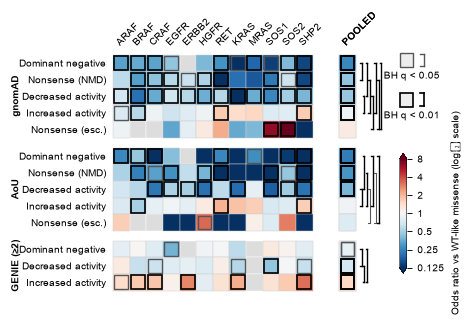

row blocks: gnomAD (5), AoU (5), GENIE (3)
brackets drawn: 18 of 23 pairs


scope,POOLED,araf,braf,craf,egfr,erbb2,kras,met,mras,ret,shp2,sos1,sos2
cls,,,,,,,,,,,,,
DN,0.26,0.32,0.34,0.33,0.44,NaN,0.12,0.39,0.19,0.29,0.15,0.14,0.40
High,0.88,0.73,0.56,0.90,0.65,0.77,1.45,0.90,1.55,1.73,1.69,0.76,0.77
Low,0.45,0.68,0.21,0.35,0.67,0.56,0.11,0.36,0.36,0.55,0.38,0.26,0.49
Nonsense (NMD-escape),1.19,0.89,NaN,NaN,0.34,0.82,0.35,1.22,0.39,2.15,0.00,6.33,21.45
Nonsense (NMD-trigger),0.44,0.58,0.32,0.43,0.55,0.63,0.21,0.53,0.17,0.07,0.15,0.23,0.65


In [44]:
# ======================================================================
# Figure S3F — Per-protein depletion heatmap — Configuration
# ======================================================================

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']
plt.rcParams['figure.facecolor'] = 'none'
plt.rcParams['axes.facecolor'] = 'none'
plt.rcParams['savefig.facecolor'] = 'none'

# Font sizes
FONT_SIZE_TITLE = 6.5
FONT_SIZE_LABEL = 6.5
FONT_SIZE_TICK = 6.5
FONT_SIZE_LEGEND = 6.5

# Line widths
LINE_WIDTH_AXES = 0.4
LINE_WIDTH_PLOT = 0.7


def plot_class_depletion_heatmap(
    lut: Mapping[tuple[str, str, str], tuple[float, float, int]],
    *,
    groups: Sequence[tuple[str, Sequence[str]]],
    class_labels: Mapping[str, str],
    col_order: Sequence[str],
    pairwise: pd.DataFrame | None = None,
    pooled_key: str = "Pooled",
    genie_min_count: int = 1,
    suptitle: str | None = None,
    cbar_label: str = "Odds ratio vs WT-like missense (log₂ scale)",
    figsize: tuple[float, float] = (4.0, 3.5),
    group_gap: float = 0.6,
    col_gap: float = 0.6,
    log2_lim: tuple[float, float] = (-3.0, 3.0),
    nodata_color: str = "#dddddd",   # NODATA_COLOR in the source script
    sig_q: float = 0.05,
    sig_q_strong: float = 0.01,
    sig_edge_weak: str = "#555555",
    sig_edge_strong: str = "black",
    sig_inset: float = 0.085,
    cbar_dy: float = 0.0,
    cbar_h_frac: float = 0.55,
) -> tuple[Figure, Axes]:
    """Per-scope x (database x class) depletion heatmap.

    Verbatim port of ``build_figure`` and ``draw_pooled_brackets`` from
    ``scripts/plot_class_depletion_heatmap.py`` — the drawing is unchanged so
    the panel is identical to the published figure. Only the inputs differ:
    the class/database definitions, the column order and the between-class
    statistics are computed in the notebook and passed in, so no analysis
    happens here.

    Placement is deliberately staged and order-dependent. The axes is
    aspect-equal, so its realised rectangle is only known after
    ``fig.canvas.draw()``; the colourbar and significance key are then placed
    against that realised right edge, which is why they sit snug regardless of
    how far the bracket ladder extends the x-range.

    Args:
        lut: ``(scope, database, class) -> (odds_ratio, q, n_total)``. Missing
            keys, ``n_total == 0`` and non-finite odds ratios all render as
            no-data grey.
        groups: ``(database, [class, ...])`` top to bottom. Blocks may differ
            in length — GENIE has no nonsense classes because stop-gains have
            no cancer observations.
        class_labels: class key -> row label.
        col_order: scope columns left to right; ``pooled_key`` is appended
            after a gap and its tick label is bolded.
        pairwise: between-class tests with ``database``, ``class_a``,
            ``class_b``, ``q``. Significant pairs get a bracket in packed lanes
            right of the pooled column; ns pairs are omitted. None skips them.
        genie_min_count: tumour-count threshold, for the GENIE super-label.
        cbar_dy: Raise the colourbar (and so its rotated label) by this
            fraction of the figure height. The bar is bottom-aligned with the
            heatmap, which puts a long label hard against the bottom edge where
            a tight bbox can clip it.
        cbar_h_frac: Colourbar height as a fraction of the heatmap height.

    Returns:
        ``(fig, ax)``.
    """
    from matplotlib.cm import ScalarMappable
    from matplotlib.lines import Line2D
    from matplotlib.patches import Rectangle
    import matplotlib.colors as mcolors

    LOG2_MIN, LOG2_MAX = log2_lim
    CMAP = plt.get_cmap("RdBu_r")
    NORM = mcolors.TwoSlopeNorm(vcenter=0.0, vmin=LOG2_MIN, vmax=LOG2_MAX)
    CBAR_EXP = list(range(int(LOG2_MIN), int(LOG2_MAX) + 1))
    CBAR_LABELS = [f"{2.0 ** e:g}" for e in CBAR_EXP]

    proteins = list(col_order)
    col_x: dict[str, float] = {}
    x = 0.0
    for p in proteins:
        col_x[p] = x
        x += 1.0
    x += col_gap
    col_x[pooled_key] = x
    all_cols = proteins + [pooled_key]

    row_y: list[tuple[str, str, float]] = []
    group_spans: list[tuple[str, float, float]] = []
    y = 0.0
    for gi, (db, classes) in enumerate(groups):
        if gi > 0:
            y += group_gap
        y0 = y
        for cls in classes:
            row_y.append((db, cls, y))
            y += 1.0
        group_spans.append((db, y0, y - 1.0))
    y_bottom = y - 1.0

    fig, ax = plt.subplots(figsize=figsize)

    # Two passes so significant borders are never clipped by a later neighbour.
    sig_weak: list[tuple[float, float]] = []
    sig_strong: list[tuple[float, float]] = []
    for (db, cls, yy) in row_y:
        for col in all_cols:
            xx = col_x[col]
            rec = lut.get((col, db, cls))
            if rec is None or rec[2] == 0 or not np.isfinite(rec[0]):
                ax.add_patch(Rectangle((xx - 0.5, yy - 0.5), 1, 1,
                                       facecolor=nodata_color,
                                       edgecolor="white", lw=0.3, zorder=2))
                continue
            or_, q, _ = rec
            val = np.clip(np.log2(or_) if or_ > 0 else LOG2_MIN,
                          LOG2_MIN, LOG2_MAX)
            ax.add_patch(Rectangle((xx - 0.5, yy - 0.5), 1, 1,
                                   facecolor=CMAP(NORM(val)),
                                   edgecolor="#cfcfcf", lw=0.3, zorder=2))
            if np.isfinite(q):
                if q < sig_q_strong:
                    sig_strong.append((xx, yy))
                elif q < sig_q:
                    sig_weak.append((xx, yy))
    side = 1 - 2 * sig_inset
    for (xx, yy) in sig_weak:
        ax.add_patch(Rectangle((xx - 0.5 + sig_inset, yy - 0.5 + sig_inset),
                               side, side, facecolor="none",
                               edgecolor=sig_edge_weak, lw=0.9, zorder=5))
    for (xx, yy) in sig_strong:
        ax.add_patch(Rectangle((xx - 0.5 + sig_inset, yy - 0.5 + sig_inset),
                               side, side, facecolor="none",
                               edgecolor=sig_edge_strong, lw=1.1, zorder=6))

    # ---- bracket ladder right of the pooled column ----------------------
    bracket_x_max = col_x[pooled_key] + 0.85
    if pairwise is not None and len(pairwise):
        y_of = {(db, cls): yy for (db, cls, yy) in row_y}
        x0, lane_w, nub = col_x[pooled_key] + 0.85, 0.17, 0.10
        for db, _classes in groups:
            sub = pairwise[pairwise["database"] == db]
            if sub.empty:
                continue
            pairs = []
            for _, r in sub.iterrows():
                q = r["q"]
                if not np.isfinite(q) or q >= sig_q:
                    continue
                key_a, key_b = (db, r["class_a"]), (db, r["class_b"])
                if key_a not in y_of or key_b not in y_of:
                    continue
                ya, yb = y_of[key_a], y_of[key_b]
                pairs.append((abs(ya - yb), min(ya, yb), max(ya, yb),
                              q < sig_q_strong))
            pairs.sort(key=lambda t: (t[0], t[1]))
            for lane, (_span, ytop, ybot, strong) in enumerate(pairs):
                xx = x0 + lane * lane_w
                bracket_x_max = max(bracket_x_max, xx)
                col = sig_edge_strong if strong else sig_edge_weak
                lw = 0.9 if strong else 0.7
                ax.plot([xx, xx], [ytop, ybot], color=col, lw=lw, zorder=7,
                        clip_on=False)
                for yend in (ytop, ybot):
                    ax.plot([xx - nub, xx], [yend, yend], color=col, lw=lw,
                            zorder=7, clip_on=False)

    ax.set_xlim(-0.6, bracket_x_max + 0.7)
    ax.set_ylim(y_bottom + 0.6, -0.6)
    ax.set_aspect("equal")

    ax.set_xticks([col_x[c] for c in all_cols])
    ax.xaxis.tick_top()
    ax.set_xticklabels([protein_label(c) if str(c).lower() in PROTEIN_KEYS
                        else str(c).upper() for c in all_cols],
                       fontsize=6.5, rotation=45, ha="left",
                       rotation_mode="anchor")
    ax.get_xticklabels()[-1].set_fontweight("bold")
    ax.tick_params(axis="x", length=0)

    ax.set_yticks([yy for (_, _, yy) in row_y])
    ax.set_yticklabels([class_labels.get(c, c) for (_, c, _) in row_y],
                       fontsize=6.5)
    ax.tick_params(axis="y", length=0)
    for (db, y0, y1) in group_spans:
        db_label = f"GENIE (≥{genie_min_count})" if db == "GENIE" else db
        ax.annotate(db_label, xy=(-0.34, (y0 + y1) / 2),
                    xycoords=("axes fraction", "data"), rotation=90,
                    ha="center", va="center", fontsize=6.5, fontweight="bold",
                    annotation_clip=False)

    for s in ("top", "right", "left", "bottom"):
        ax.spines[s].set_visible(False)

    fig.subplots_adjust(left=0.32, right=0.96, top=0.80, bottom=0.06)
    ax.set_anchor("W")
    if suptitle:
        fig.suptitle(suptitle, fontsize=6.5, fontweight="bold", y=0.99)

    fig.canvas.draw()   # realise the aspect-shrunk axes before placing legends
    pos = ax.get_position()
    legend_x = pos.x1 + 0.015

    sm = ScalarMappable(norm=NORM, cmap=CMAP)
    sm.set_array([])
    cax = fig.add_axes([legend_x, pos.y0 + cbar_dy, 0.016,
                        pos.height * cbar_h_frac])
    cbar = fig.colorbar(sm, cax=cax, ticks=CBAR_EXP, extend="both")
    cbar.ax.set_yticklabels(CBAR_LABELS, fontsize=6.5)
    cbar.set_label(cbar_label, fontsize=6.5)
    cbar.outline.set_linewidth(0.35)

    # Significance key: a box at the same drawn size as the cells' inset
    # outline, plus a matching bracket glyph, so one key serves both.
    ax_bb = ax.get_window_extent()
    xr, yr = ax.get_xlim(), ax.get_ylim()
    cell_px = min(ax_bb.width / abs(xr[1] - xr[0]),
                  ax_bb.height / abs(yr[1] - yr[0]))
    fw_px, fh_px = fig.get_size_inches() * fig.dpi
    cell_fw, cell_fh = cell_px / fw_px, cell_px / fh_px
    side_fw, side_fh = cell_fw * (1 - 2 * sig_inset), cell_fh * (1 - 2 * sig_inset)

    key_left, y_top, pitch = legend_x, pos.y1, cell_fh + 0.060
    for i, (edge, lw, label) in enumerate(
            [(sig_edge_weak, 0.9, f"BH q < {sig_q:g}"),
             (sig_edge_strong, 1.1, f"BH q < {sig_q_strong:g}")]):
        top = y_top - i * pitch
        fig.add_artist(Rectangle(
            (key_left, top - side_fh), side_fw, side_fh, facecolor="#ededed",
            edgecolor=edge, linewidth=lw, transform=fig.transFigure,
            clip_on=False))
        yc, half = top - side_fh / 2, side_fh * 0.45
        sx, nub = key_left + side_fw + 0.024, 0.009
        for (x0, y0), (x1, y1) in (((sx, yc - half), (sx, yc + half)),
                                   ((sx - nub, yc - half), (sx, yc - half)),
                                   ((sx - nub, yc + half), (sx, yc + half))):
            fig.add_artist(Line2D([x0, x1], [y0, y1], color=edge, lw=lw,
                                  transform=fig.transFigure, clip_on=False))
        fig.text((key_left + sx) / 2, top - side_fh - 0.012, label,
                 ha="center", va="top", fontsize=6.5)
    return fig, ax


# --- Generate plot ---

GROUPS = [
    ("gnomAD", ["DN", "Nonsense (NMD-trigger)", "Low", "High",
                "Nonsense (NMD-escape)"]),
    ("AoU",    ["DN", "Nonsense (NMD-trigger)", "Low", "High",
                "Nonsense (NMD-escape)"]),
    ("GENIE",  ["DN", "Low", "High"]),
]
CLASS_SHORT = {
    "DN": "Dominant negative",
    "Nonsense (NMD-trigger)": "Nonsense (NMD)",
    "Low": "Decreased activity",
    "High": "Increased activity",
    "Nonsense (NMD-escape)": "Nonsense (esc.)",
}
# snv carries the activity classes lower-case and the nonsense classes spelled
# out; map to the row keys used above.
TO_ROW_KEY = {"DN": "DN", "low": "Low", "high": "High",
              "Nonsense (NMD-trigger)": "Nonsense (NMD-trigger)",
              "Nonsense (NMD-escape)": "Nonsense (NMD-escape)"}
snv["row_key"] = snv.group.map(TO_ROW_KEY)

rows = []
for db, classes in GROUPS:
    col = f"obs_{db}"
    scopes = [(p, g) for p, g in snv.groupby("protein")] + [("POOLED", snv)]
    for scope, gp in scopes:
        ref = gp[gp.group == "wt-like"]
        if len(ref) < 10:
            continue
        r_obs, r_tot = int(ref[col].sum()), len(ref)
        for cls in classes:
            g = gp[gp.row_key == cls]
            if len(g) < 10:
                continue
            o, tt = int(g[col].sum()), len(g)
            res = fisher_or(o, tt - o, r_obs, r_tot - r_obs)
            res.update(database=db, scope=scope, cls=cls, n=tt,
                       frac_obs=o / tt)
            rows.append(res)
hm = pd.DataFrame(rows).rename(columns={"or_": "or"})
# BH within each database block — the comparisons in a block are one family.
hm["q"] = np.nan
for db, idx in hm.groupby("database").groups.items():
    hm.loc[idx, "q"] = bh(hm.loc[idx, "p"].values)
hm.to_csv(FIG / "figs3f_depletion_per_protein.tsv", sep="\t", index=False)

# All-pairwise between-class tests on the POOLED rates, which drive the bracket
# ladder to the right of the POOLED column. The question is not only "is this
# class depleted" but "is it depleted *more* than the next class" — whether DN
# is more depleted than NMD-triggering nonsense is the comparison that makes
# the DN signal mean something beyond loss of function. Ignores protein: these
# are the pooled rates. BH within each database block, as with the cells.
pw_rows = []
for db, classes in GROUPS:
    sub = hm[(hm.database == db) & (hm.scope == "POOLED")].set_index("cls")
    present = [c for c in classes if c in sub.index and int(sub.loc[c, "n"]) > 0]
    block = []
    for i in range(len(present)):
        for j in range(i + 1, len(present)):
            a, b = present[i], present[j]
            ta, tb = int(sub.loc[a, "n"]), int(sub.loc[b, "n"])
            oa = int(round(sub.loc[a, "frac_obs"] * ta))
            ob = int(round(sub.loc[b, "frac_obs"] * tb))
            pv = stats.fisher_exact([[oa, ta - oa], [ob, tb - ob]],
                                    alternative="two-sided").pvalue
            # Haldane correction on the point estimate only; the p is exact.
            num, den = (oa + 0.5) * (tb - ob + 0.5), (ta - oa + 0.5) * (ob + 0.5)
            block.append(dict(database=db, class_a=a, class_b=b,
                              or_a_vs_b=num / den, p=pv))
    if block:
        qs = bh([r["p"] for r in block])
        for r, q in zip(block, qs):
            r["q"] = q
        pw_rows.extend(block)
pairwise = pd.DataFrame(pw_rows)
pairwise.to_csv(FIG / "figs3f_pooled_pairwise.tsv", sep="\t", index=False)

# (scope, database, class) -> (odds ratio, q, n). The renderer treats a missing
# key, n == 0 or a non-finite OR as no-data grey.
# itertuples would rename the "or" column (a keyword), so iterate rows.
lut = {(r.scope if r.scope != "POOLED" else "Pooled", r.database, r.cls):
       (float(r["or"]), float(r["q"]), int(r["n"]))
       for _, r in hm.iterrows()}
MIN_COUNT = 2
# No title: the panel is captioned in the figure, and dropping it frees the
# strip the significance key sits in. The colourbar is nudged up so its rotated
# label clears the bottom edge instead of being clipped by the tight bbox.
fig, _ = plot_class_depletion_heatmap(
    lut, groups=GROUPS, class_labels=CLASS_SHORT,
    col_order=[p for p in DN_ORDER if p in set(hm.scope)] + ["Pooled"],
    pairwise=pairwise, genie_min_count=MIN_COUNT, figsize=(4.0, 3.5),
    cbar_dy=0.05, cbar_h_frac=0.50)
save_figure(fig, FIG / "ExtDataDN7f_depletion_heatmap")
plt.show()
print("row blocks: " + ", ".join(f"{db} ({len(cs)})" for db, cs in GROUPS))
print(f"brackets drawn: {int((pairwise.q < 0.05).sum())} of {len(pairwise)} pairs")
display(hm.pivot_table(index="cls", columns="scope", values="or",
                       aggfunc="first").round(2))